In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import sys, os
import warnings
warnings.filterwarnings('ignore')

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

# Robust src path - works whether run manually or via papermill
_src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if _src_path not in sys.path:
    sys.path.insert(0, _src_path)
from config import *

with open(f'{OUT_PATH}03_segment_pivots.pkl', 'rb') as f:
    segment_pivots = pickle.load(f)

print(f"Loaded {len(segment_pivots)} segment pivots")
print(f"Segment keys: {sorted(segment_pivots.keys())}")

Loaded 14 segment pivots
Segment keys: ['BP_1_Single', 'BS_1_Single', 'DF_1_DF', 'DF_1_DFT', 'HL_1_CABIN', 'HL_1_LARGE', 'HL_1_MEDIUM', 'HL_1_SO2', 'HL_1_SO3', 'SL_1_CABIN', 'SL_1_LARGE', 'SL_1_MEDIUM', 'SL_1_SO2', 'SL_1_SO3']


In [2]:
# Work on HL/CABIN first - we know ground truth is 6 New Buckets
pilot_key   = next((k for k in sorted(segment_pivots) if '_CABIN' in k), sorted(segment_pivots)[0])
pilot_info  = segment_pivots[pilot_key]
pivot       = pilot_info['pivot']

print(f"Segment: {pilot_info['div']} / {pilot_info['size']} / Portal {pilot_info['portal']}")
print(f"Pivot shape: {pivot.shape}  (buckets x months)")

# ── Step 1: detect and remove sparse buckets ──────────────────────
months_active = (pivot > 0).sum(axis=1)

valid  = pivot[months_active >= MIN_BUCKET_MONTHS].copy()
sparse = pivot[months_active <  MIN_BUCKET_MONTHS].copy()

print(f"\nBucket classification:")
print(f"  Active  (>= {MIN_BUCKET_MONTHS} months non-zero): {len(valid):>3} buckets")
print(f"  Sparse  (<  {MIN_BUCKET_MONTHS} months non-zero): {len(sparse):>3} buckets")

if len(sparse) > 0:
    print(f"\n  Sparse buckets (will assign after clustering):")
    for b in sparse.index:
        print(f"    ₹{b}-{b+100}  active in {int(months_active[b])} months")

Segment: HL / CABIN / Portal 1
Pivot shape: (57, 24)  (buckets x months)

Bucket classification:
  Active  (>= 3 months non-zero):  49 buckets
  Sparse  (<  3 months non-zero):   8 buckets

  Sparse buckets (will assign after clustering):
    ₹300-400  active in 1 months
    ₹400-500  active in 1 months
    ₹5200-5300  active in 1 months
    ₹5400-5500  active in 1 months
    ₹5700-5800  active in 1 months
    ₹6300-6400  active in 1 months
    ₹6800-6900  active in 2 months
    ₹8300-8400  active in 1 months


In [3]:
# ── Step 2: build correlation distance matrix ─────────────────────

# Pearson correlation between every pair of active bucket trend lines
corr_matrix = valid.T.corr(method='pearson')

# Fill NaN - happens when a series has zero variance (flat line)
# We treat those as neutral: neither correlated nor anti-correlated
corr_matrix = corr_matrix.fillna(0)

# Distance = 1 - correlation, clipped to zero (floating point safety)
dist_matrix = (1 - corr_matrix).clip(lower=0)

# Force diagonal to exactly zero
dist_values = dist_matrix.values.copy()
np.fill_diagonal(dist_values, 0)

# Convert to condensed form for scipy
condensed = squareform(dist_values, checks=False)

print(f"Distance matrix shape: {dist_matrix.shape}")
print(f"\nDistance interpretation:")
print(f"  0.0 = identical trend (should merge)")
print(f"  1.0 = no correlation (unrelated)")
print(f"  2.0 = opposite trend (never merge)")
print(f"\nDistance stats across all bucket pairs:")
print(f"  Min : {dist_values[dist_values > 0].min():.4f}")
print(f"  Max : {dist_values.max():.4f}")
print(f"  Mean: {dist_values[dist_values > 0].mean():.4f}")
print(f"\nCurrent DISTANCE_THRESHOLD: {DISTANCE_THRESHOLD}")
print(f"  → buckets closer than {DISTANCE_THRESHOLD} will merge together")

Distance matrix shape: (49, 49)

Distance interpretation:
  0.0 = identical trend (should merge)
  1.0 = no correlation (unrelated)
  2.0 = opposite trend (never merge)

Distance stats across all bucket pairs:
  Min : 0.0151
  Max : 1.4657
  Mean: 0.9712

Current DISTANCE_THRESHOLD: 0.4
  → buckets closer than 0.4 will merge together


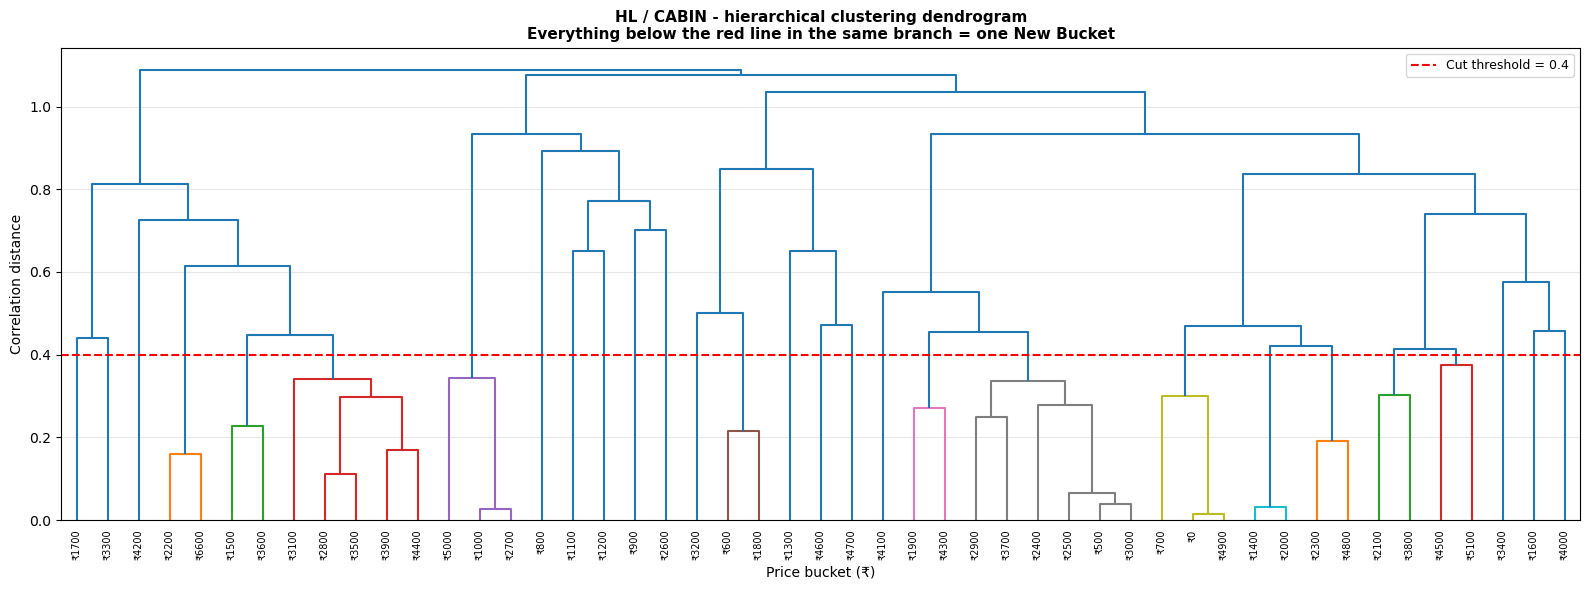

Threshold 0.4 produces: 28 clusters
Ground truth target: 6 New Buckets


In [4]:
# ── Step 3: hierarchical clustering ──────────────────────────────
Z = linkage(condensed, method='average')

# ── Step 4: plot dendrogram ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

dendrogram(
    Z,
    labels=[f'₹{int(b)}' for b in valid.index],
    ax=ax,
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=DISTANCE_THRESHOLD
)

ax.axhline(
    y=DISTANCE_THRESHOLD,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Cut threshold = {DISTANCE_THRESHOLD}'
)

ax.set_title('HL / CABIN - hierarchical clustering dendrogram\n'
             'Everything below the red line in the same branch = one New Bucket',
             fontweight='bold', fontsize=11)
ax.set_xlabel('Price bucket (₹)', fontsize=10)
ax.set_ylabel('Correlation distance', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_PATH}04_dendrogram_HL_1_CABIN.png', dpi=150, bbox_inches='tight')
plt.show()

# Count how many clusters this threshold produces
raw_labels = fcluster(Z, t=DISTANCE_THRESHOLD, criterion='distance')
print(f"Threshold {DISTANCE_THRESHOLD} produces: {len(set(raw_labels))} clusters")
print(f"Ground truth target: 6 New Buckets")

TOP 10 MERGE DISTANCES (largest gaps = natural cluster boundaries)
  k clusters    merge distance     gap to next
------------------------------------------------
           2            1.0879         -0.0125
           3            1.0754         -0.0396
           4            1.0358         -0.1016
           5            0.9342         -0.0007
           6            0.9335         -0.0416
           7            0.8919         -0.0436
           8            0.8483         -0.0109
           9            0.8374         -0.0236
          10            0.8137         -0.0424
          11            0.7713         -0.0323
          12            0.7390         -0.0138
          13            0.7252         -0.0229

Optimal k from elbow method : 15
Ground truth target         : 6


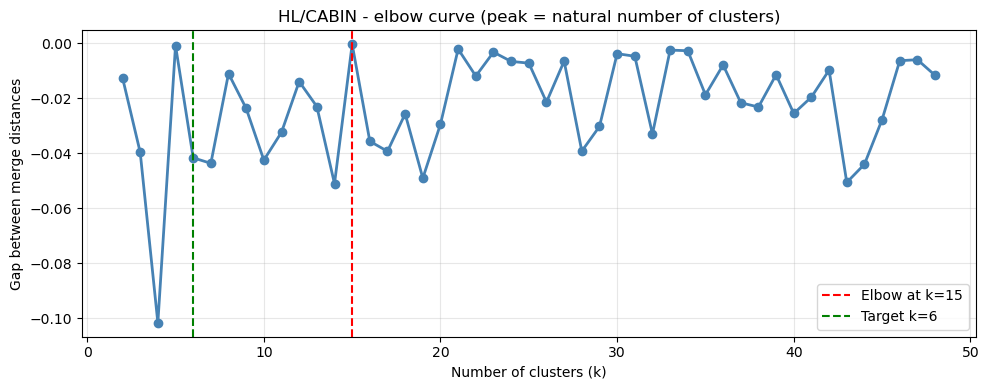

In [5]:
# ── Step 5: find optimal k via largest gap on dendrogram ──────────
# Z[:,2] contains the merge distances in order from smallest to largest
merge_distances = Z[:, 2]

# Reverse so index 0 = last merge (k=2), index n = first merge (k=n+1)
rev_distances = merge_distances[::-1]

# Gap between consecutive merges
# A large gap means: "going from k to k-1 required merging two very different groups"
# That is the elbow - stop just before that big jump
gaps = np.diff(rev_distances)

# Best k is where the gap is largest
best_k = int(np.argmax(gaps)) + 2  # +2 because argmax gives 0-indexed gap

print("TOP 10 MERGE DISTANCES (largest gaps = natural cluster boundaries)")
print(f"{'k clusters':>12}  {'merge distance':>16}  {'gap to next':>14}")
print("-" * 48)
for i in range(min(12, len(rev_distances))):
    k = i + 2
    gap = gaps[i] if i < len(gaps) else 0
    marker = "  ← ELBOW" if k == best_k else ""
    print(f"{k:>12}  {rev_distances[i]:>16.4f}  {gap:>14.4f}{marker}")

print(f"\nOptimal k from elbow method : {best_k}")
print(f"Ground truth target         : 6")

# Plot the gap curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(2, len(gaps) + 2), gaps, 'o-', color='steelblue', linewidth=2)
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Elbow at k={best_k}')
ax.axvline(x=6, color='green', linestyle='--', label='Target k=6')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Gap between merge distances')
ax.set_title('HL/CABIN - elbow curve (peak = natural number of clusters)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}04_elbow_HL_1_CABIN.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── Correct k selection: find the largest k where every cluster
#    has at least MIN_CLUSTER_VOL_PCT of segment total volume ──────

total_vol = valid.sum(axis=1).sum()

print(f"Total segment volume : {total_vol:,.0f} units")
print(f"Minimum cluster vol  : {MIN_CLUSTER_VOL_PCT*100:.0f}% = "
      f"{total_vol * MIN_CLUSTER_VOL_PCT:,.0f} units\n")

print(f"{'k':>4}  {'min cluster %':>14}  {'verdict':>20}")
print("-" * 45)

best_k = 2
results_by_k = {}

for k in range(2, min(MAX_K + 1, len(valid))):
    labels = fcluster(Z, k, criterion='maxclust')
    
    cluster_vols = {}
    for bucket, label in zip(valid.index, labels):
        cluster_vols[label] = cluster_vols.get(label, 0) + valid.loc[bucket].sum()
    
    min_pct = min(cluster_vols.values()) / total_vol
    results_by_k[k] = {'labels': labels, 'min_pct': min_pct}
    
    ok = min_pct >= MIN_CLUSTER_VOL_PCT
    if ok:
        best_k = k
    
    marker = "  ← best so far" if ok and k == best_k else (
             "  ← too granular" if not ok else "")
    print(f"{k:>4}  {min_pct*100:>13.1f}%  {'OK' if ok else 'FAIL - cluster too small':>20}{marker}")

print(f"\nSelected k = {best_k}")
print(f"Ground truth target = 6")

Total segment volume : 2,397 units
Minimum cluster vol  : 3% = 72 units

   k   min cluster %               verdict
---------------------------------------------
   2           20.8%                    OK  ← best so far
   3           20.8%                    OK  ← best so far
   4           20.8%                    OK  ← best so far
   5            0.8%  FAIL - cluster too small  ← too granular
   6            0.8%  FAIL - cluster too small  ← too granular
   7            0.0%  FAIL - cluster too small  ← too granular
   8            0.0%  FAIL - cluster too small  ← too granular

Selected k = 4
Ground truth target = 6


In [7]:
# Load actual quantities from notebook 02 output
bucket_ts = pd.read_csv(f'{OUT_PATH}02_fine_bucket_ts.csv')
bucket_ts['sale_date'] = pd.to_datetime(bucket_ts['sale_date'])

# ── helpers ──────────────────────────────────────────────────────────────

def mean_series(pivot, group):
    ...

# Get real total volume per bucket for HL/CABIN
hl_cabin_vol = (
    bucket_ts[(bucket_ts['Division']=='HL') &
              (bucket_ts['Portal']==1) &
              (bucket_ts['Size']=='CABIN')]
    .groupby('bucket_min')['qty']
    .sum()
)

total_vol_real = hl_cabin_vol.sum()
print(f"Real total volume  : {total_vol_real:,.0f} units")
print(f"Min cluster vol 3% : {total_vol_real * MIN_CLUSTER_VOL_PCT:,.0f} units\n")

print(f"{'k':>4}  {'min cluster %':>14}  {'verdict':>20}")
print("-" * 45)

best_k = 2
results_by_k = {}

for k in range(2, min(MAX_K + 1, len(valid))):
    labels = fcluster(Z, k, criterion='maxclust')
    
    # Use REAL qty per bucket
    cluster_vols = {}
    for bucket, label in zip(valid.index, labels):
        real_vol = hl_cabin_vol.get(bucket, 0)
        cluster_vols[label] = cluster_vols.get(label, 0) + real_vol
    
    min_pct = min(cluster_vols.values()) / total_vol_real
    results_by_k[k] = {'labels': labels, 'min_pct': min_pct}
    
    ok = min_pct >= MIN_CLUSTER_VOL_PCT
    if ok:
        best_k = k

    marker = "  ← best so far" if ok and k == best_k else (
             "  ← too granular" if not ok else "")
    print(f"{k:>4}  {min_pct*100:>13.1f}%  "
          f"{'OK' if ok else 'FAIL - cluster too small':>20}{marker}")

print(f"\nSelected k = {best_k}")
print(f"Ground truth target = 6")

Real total volume  : 655,610 units
Min cluster vol 3% : 19,668 units

   k   min cluster %               verdict
---------------------------------------------
   2            9.8%                    OK  ← best so far
   3            9.8%                    OK  ← best so far
   4            9.8%                    OK  ← best so far
   5            0.7%  FAIL - cluster too small  ← too granular
   6            0.7%  FAIL - cluster too small  ← too granular
   7            0.0%  FAIL - cluster too small  ← too granular
   8            0.0%  FAIL - cluster too small  ← too granular

Selected k = 4
Ground truth target = 6


In [8]:
def greedy_adjacent_cluster(pivot, vol_by_bucket, total_vol, min_vol_pct, max_k):
    """
    Mimics the analyst exactly:
    - Start with every bucket as its own group
    - At each step, find the most similar ADJACENT pair
    - Merge them
    - Stop when the next merge would create a group below min_vol_pct
    - Never merge non-adjacent buckets
    """
    buckets = sorted(pivot.index.tolist())
    
    # Start: each bucket is its own cluster {cluster_id: [list of bucket_mins]}
    clusters = {i: [b] for i, b in enumerate(buckets)}
    
    def cluster_series(bucket_list):
        """Mean % share series for a group of buckets"""
        return pivot.loc[bucket_list].mean(axis=0)
    
    def pearson_sim(list1, list2):
        """Similarity between two groups"""
        s1 = cluster_series(list1)
        s2 = cluster_series(list2)
        if s1.std() == 0 or s2.std() == 0:
            return 0.5
        return float(np.corrcoef(s1, s2)[0, 1])
    
    def cluster_vol_pct(bucket_list):
        return sum(vol_by_bucket.get(b, 0) for b in bucket_list) / total_vol
    
    while len(clusters) > 2:
        cluster_ids = sorted(clusters.keys())
        
        # Find best adjacent pair to merge
        best_sim  = -1
        best_pair = None
        
        for i in range(len(cluster_ids) - 1):
            c1 = cluster_ids[i]
            c2 = cluster_ids[i + 1]
            sim = pearson_sim(clusters[c1], clusters[c2])
            if sim > best_sim:
                best_sim  = sim
                best_pair = (c1, c2)
        
        if best_pair is None:
            break
        
        c1, c2 = best_pair
        merged_buckets = clusters[c1] + clusters[c2]
        merged_vol_pct = cluster_vol_pct(merged_buckets)
        
        # Check: would this merge drop us below min volume?
        # If yes AND we already have <= max_k clusters, stop
        if merged_vol_pct < min_vol_pct and len(clusters) <= max_k:
            break
        
        # Merge c2 into c1, remove c2
        clusters[c1] = merged_buckets
        del clusters[c2]
    
    # Build result: bucket_min → cluster number (1 = cheapest)
    result = {}
    for new_id, (_, bucket_list) in enumerate(sorted(clusters.items()), start=1):
        for b in bucket_list:
            result[b] = new_id
    
    return result

# ── Run on HL/CABIN pilot ─────────────────────────────────────────
cluster_map = greedy_adjacent_cluster(
    pivot      = valid,
    vol_by_bucket = hl_cabin_vol,
    total_vol  = total_vol_real,
    min_vol_pct= MIN_CLUSTER_VOL_PCT,
    max_k      = MAX_K
)

n_clusters = len(set(cluster_map.values()))
print(f"Greedy adjacent merge → {n_clusters} New Buckets")
print(f"Ground truth target   → 6\n")

print(f"{'New Bucket':>12}  {'Price range':>20}  {'Vol %':>8}  {'Buckets':>8}")
print("-" * 58)
for nb in sorted(set(cluster_map.values())):
    members  = sorted([b for b, c in cluster_map.items() if c == nb])
    vol_pct  = sum(hl_cabin_vol.get(b, 0) for b in members) / total_vol_real * 100
    rng      = f"₹{members[0]}-₹{members[-1]+100}"
    print(f"{nb:>12}  {rng:>20}  {vol_pct:>7.1f}%  {len(members):>8}")

Greedy adjacent merge → 6 New Buckets
Ground truth target   → 6

  New Bucket           Price range     Vol %   Buckets
----------------------------------------------------------
           1              ₹0-₹1300     45.3%         9
           2           ₹1300-₹1400     28.4%         1
           3           ₹1400-₹5000     26.0%        36
           4           ₹5000-₹5100      0.1%         1
           5           ₹5100-₹5200      0.1%         1
           6           ₹6600-₹6700      0.0%         1


In [9]:
def post_merge_cleanup(cluster_map, vol_by_bucket, total_vol, min_vol_pct):
    """
    After the main merge, sweep up any cluster still below min_vol_pct.
    Merge it into whichever adjacent cluster is cheaper to absorb
    (i.e. the one it shares a price boundary with).
    Repeat until all clusters are above threshold.
    """
    while True:
        # Rebuild cluster → bucket list mapping
        clusters = {}
        for b, c in cluster_map.items():
            clusters.setdefault(c, []).append(b)
        
        # Sort cluster IDs by their minimum price
        sorted_ids = sorted(clusters.keys(),
                            key=lambda c: min(clusters[c]))
        
        # Find first cluster below threshold
        small_id = None
        for cid in sorted_ids:
            vol_pct = sum(vol_by_bucket.get(b, 0)
                         for b in clusters[cid]) / total_vol
            if vol_pct < min_vol_pct:
                small_id = cid
                break
        
        if small_id is None:
            break  # all clusters above threshold - done
        
        # Find its position in price-sorted order
        pos = sorted_ids.index(small_id)
        
        # Merge into cheaper neighbour (prefer lower price, i.e. previous)
        if pos > 0:
            neighbour_id = sorted_ids[pos - 1]
        else:
            neighbour_id = sorted_ids[pos + 1]
        
        # Merge small into neighbour
        for b in clusters[small_id]:
            cluster_map[b] = neighbour_id
    
    # Re-number 1..N by ascending price
    clusters = {}
    for b, c in cluster_map.items():
        clusters.setdefault(c, []).append(b)
    
    sorted_ids = sorted(clusters.keys(), key=lambda c: min(clusters[c]))
    remap = {old: new + 1 for new, old in enumerate(sorted_ids)}
    return {b: remap[c] for b, c in cluster_map.items()}


# ── Apply cleanup to HL/CABIN result ─────────────────────────────
clean_map = post_merge_cleanup(
    cluster_map   = dict(cluster_map),   # copy
    vol_by_bucket = hl_cabin_vol,
    total_vol     = total_vol_real,
    min_vol_pct   = MIN_CLUSTER_VOL_PCT
)

# Also assign sparse buckets to nearest active neighbour
active_buckets = sorted(clean_map.keys())
for sparse_b in sorted(sparse.index):
    nearest = min(active_buckets, key=lambda b: abs(b - sparse_b))
    clean_map[sparse_b] = clean_map[nearest]

# Re-number final output
clusters_final = {}
for b, c in clean_map.items():
    clusters_final.setdefault(c, []).append(b)
sorted_ids = sorted(clusters_final.keys(),
                    key=lambda c: min(clusters_final[c]))
remap = {old: new + 1 for new, old in enumerate(sorted_ids)}
clean_map = {b: remap[c] for b, c in clean_map.items()}

# ── Print final result ────────────────────────────────────────────
n_final = len(set(clean_map.values()))
print(f"After cleanup → {n_final} New Buckets")
print(f"Ground truth  → 6\n")

# Rebuild with real volumes (including sparse)
all_vol = (
    bucket_ts[(bucket_ts['Division']=='HL') &
              (bucket_ts['Portal']==1) &
              (bucket_ts['Size']=='CABIN')]
    .groupby('bucket_min')['qty'].sum()
)
full_total = all_vol.sum()

print(f"{'NB':>4}  {'Price range':>22}  {'Vol %':>7}  {'Fine buckets':>13}")
print("-" * 55)
for nb in sorted(set(clean_map.values())):
    members = sorted([b for b, c in clean_map.items() if c == nb])
    vol_pct = sum(all_vol.get(b, 0) for b in members) / full_total * 100
    rng     = f"₹{members[0]}-₹{members[-1]+100}"
    print(f"{nb:>4}  {rng:>22}  {vol_pct:>6.1f}%  {len(members):>13}")


After cleanup → 3 New Buckets
Ground truth  → 6

  NB             Price range    Vol %   Fine buckets
-------------------------------------------------------
   1                ₹0-₹1300    45.4%             11
   2             ₹1300-₹1400    28.4%              1
   3             ₹1400-₹8400    26.2%             45


In [10]:
def cluster_segment(pivot, vol_by_bucket, total_vol, 
                    min_vol_pct, max_k, Z, valid_index):
    """
    1. Try k from max_k down to 2 using the dendrogram
    2. For each k: enforce contiguity, check all clusters above min_vol
    3. Return the highest k that passes both checks
    """
    buckets_sorted = sorted(valid_index)
    
    for k in range(max_k, 1, -1):
        raw_labels = fcluster(Z, k, criterion='maxclust')
        label_map  = {b: int(l) for b, l in zip(valid_index, raw_labels)}
        
        # ── Enforce contiguity ────────────────────────────────────
        # Walk buckets in price order, assign same cluster only if
        # it was already seen and contiguous
        contiguous_map = {}
        current_cluster = None
        current_label   = None
        new_cid = 1
        
        for b in buckets_sorted:
            lbl = label_map[b]
            if lbl != current_label:
                # New cluster encountered - start a new group
                current_label   = lbl
                current_cluster = new_cid
                new_cid += 1
            contiguous_map[b] = current_cluster
        
        # ── Check all clusters above volume threshold ─────────────
        clusters = {}
        for b, c in contiguous_map.items():
            clusters.setdefault(c, []).append(b)
        
        all_ok = all(
            sum(vol_by_bucket.get(b, 0) for b in members) / total_vol 
            >= min_vol_pct
            for members in clusters.values()
        )
        
        if all_ok:
            # Re-number 1..N by ascending price
            sorted_cids = sorted(clusters.keys(),
                                 key=lambda c: min(clusters[c]))
            remap = {old: i+1 for i, old in enumerate(sorted_cids)}
            return {b: remap[c] for b, c in contiguous_map.items()}
    
    # Fallback: everything in one bucket
    return {b: 1 for b in buckets_sorted}


# ── Run on HL/CABIN ───────────────────────────────────────────────
result_map = cluster_segment(
    pivot         = valid,
    vol_by_bucket = hl_cabin_vol,
    total_vol     = total_vol_real,
    min_vol_pct   = MIN_CLUSTER_VOL_PCT,
    max_k         = MAX_K,
    Z             = Z,
    valid_index   = valid.index
)

# Assign sparse buckets to nearest active neighbour
active_sorted = sorted(result_map.keys())
for sparse_b in sorted(sparse.index):
    nearest = min(active_sorted, key=lambda b: abs(b - sparse_b))
    result_map[sparse_b] = result_map[nearest]

# Final re-number including sparse
clusters_final = {}
for b, c in result_map.items():
    clusters_final.setdefault(c, []).append(b)
sorted_cids = sorted(clusters_final.keys(),
                     key=lambda c: min(clusters_final[c]))
remap = {old: i+1 for i, old in enumerate(sorted_cids)}
result_map = {b: remap[c] for b, c in result_map.items()}

# ── Print result ──────────────────────────────────────────────────
n_final = len(set(result_map.values()))
print(f"Final New Buckets : {n_final}")
print(f"Ground truth      : 6\n")

print(f"{'NB':>4}  {'Price range':>22}  {'Vol %':>7}  {'Fine buckets':>13}")
print("-" * 56)
for nb in sorted(set(result_map.values())):
    members = sorted([b for b, c in result_map.items() if c == nb])
    vol_pct = sum(all_vol.get(b, 0) for b in members) / full_total * 100
    rng     = f"₹{members[0]}-₹{members[-1]+100}"
    print(f"{nb:>4}  {rng:>22}  {vol_pct:>6.1f}%  {len(members):>13}")

Final New Buckets : 1
Ground truth      : 6

  NB             Price range    Vol %   Fine buckets
--------------------------------------------------------
   1                ₹0-₹8400   100.0%             57


In [11]:
def find_best_k(Z, valid_index, vol_by_bucket, total_vol, 
                min_vol_pct, max_k):
    """
    Try k from max_k down to 2.
    For each k:
      - Cut dendrogram at exactly k clusters
      - Re-label clusters 1..k by ascending median price
      - Check every cluster has >= min_vol_pct
    Return first k that passes.
    """
    for k in range(max_k, 1, -1):
        raw_labels = fcluster(Z, k, criterion='maxclust')
        
        # Map bucket → label
        label_map = {b: int(l) for b, l in zip(valid_index, raw_labels)}
        
        # Re-label by ascending median price of each cluster
        clusters = {}
        for b, c in label_map.items():
            clusters.setdefault(c, []).append(b)
        
        median_price = {c: np.median(members) 
                        for c, members in clusters.items()}
        price_sorted = sorted(median_price.keys(), 
                              key=lambda c: median_price[c])
        remap = {old: new+1 for new, old in enumerate(price_sorted)}
        final_map = {b: remap[c] for b, c in label_map.items()}
        
        # Check volume threshold
        clusters_relabeled = {}
        for b, c in final_map.items():
            clusters_relabeled.setdefault(c, []).append(b)
        
        vols = {c: sum(vol_by_bucket.get(b, 0) for b in members)
                for c, members in clusters_relabeled.items()}
        min_pct = min(vols.values()) / total_vol
        
        if min_pct >= min_vol_pct:
            return final_map, k
    
    # Fallback
    return {b: 1 for b in valid_index}, 1


# ── Run on HL/CABIN ───────────────────────────────────────────────
result_map, chosen_k = find_best_k(
    Z             = Z,
    valid_index   = valid.index,
    vol_by_bucket = hl_cabin_vol,
    total_vol     = total_vol_real,
    min_vol_pct   = MIN_CLUSTER_VOL_PCT,
    max_k         = MAX_K
)

# Assign sparse buckets to nearest active neighbour by price
active_sorted = sorted(result_map.keys())
for sparse_b in sorted(sparse.index):
    nearest = min(active_sorted, key=lambda b: abs(b - sparse_b))
    result_map[sparse_b] = result_map[nearest]

# Re-number including sparse by ascending price
clusters_final = {}
for b, c in result_map.items():
    clusters_final.setdefault(c, []).append(b)
sorted_cids = sorted(clusters_final.keys(),
                     key=lambda c: min(clusters_final[c]))
remap = {old: i+1 for i, old in enumerate(sorted_cids)}
result_map = {b: remap[c] for b, c in result_map.items()}

# ── Print result ──────────────────────────────────────────────────
n_final = len(set(result_map.values()))
print(f"Chosen k        : {chosen_k}")
print(f"Final New Buckets: {n_final}")
print(f"Ground truth    : 6\n")

print(f"{'NB':>4}  {'Price range':>22}  {'Vol %':>7}  {'Fine buckets':>13}")
print("-" * 56)
for nb in sorted(set(result_map.values())):
    members = sorted([b for b, c in result_map.items() if c == nb])
    vol_pct = sum(all_vol.get(b, 0) for b in members) / full_total * 100
    rng     = f"₹{members[0]}-₹{members[-1]+100}"
    print(f"{nb:>4}  {rng:>22}  {vol_pct:>6.1f}%  {len(members):>13}")

Chosen k        : 4
Final New Buckets: 4
Ground truth    : 6

  NB             Price range    Vol %   Fine buckets
--------------------------------------------------------
   1                ₹0-₹5800    15.1%             28
   2              ₹600-₹4800    29.7%              6
   3              ₹800-₹5100    45.4%              8
   4             ₹1500-₹8400     9.8%             15


In [12]:
def adjacent_merge_all_states(pivot, vol_by_bucket, total_vol):
    """
    Run greedy adjacent merge from N clusters down to 2.
    Record the cluster state at every step.
    Returns: list of (k, cluster_map, min_vol_pct) for every k tried.
    """
    buckets = sorted(pivot.index.tolist())
    
    # Start: each bucket is its own cluster
    # Represent as ordered list of groups
    groups = [[b] for b in buckets]
    
    def mean_series(bucket_list):
        if len(bucket_list) == 1:
            return pivot.loc[bucket_list[0]]
        return pivot.loc[bucket_list].mean(axis=0)
    
    def correlation(g1, g2):
        s1, s2 = mean_series(g1), mean_series(g2)
        if s1.std() == 0 or s2.std() == 0:
            return 0.0
        return float(np.corrcoef(s1.values, s2.values)[0, 1])
    
    def group_vol_pct(g):
        return sum(vol_by_bucket.get(b, 0) for b in g) / total_vol
    
    def build_map(groups):
        return {b: i+1 for i, g in enumerate(groups) for b in g}
    
    def min_vol(groups):
        return min(group_vol_pct(g) for g in groups)
    
    states = []
    
    while len(groups) > 1:
        k = len(groups)
        states.append((k, build_map(groups), min_vol(groups)))
        
        # Find adjacent pair with highest correlation
        best_corr = -999
        best_idx  = 0
        for i in range(len(groups) - 1):
            c = correlation(groups[i], groups[i+1])
            if c > best_corr:
                best_corr = c
                best_idx  = i
        
        # Merge best adjacent pair
        merged = groups[best_idx] + groups[best_idx + 1]
        groups = groups[:best_idx] + [merged] + groups[best_idx + 2:]
    
    states.append((1, build_map(groups), 1.0))
    return states


# ── Run full adjacent merge ───────────────────────────────────────
states = adjacent_merge_all_states(
    pivot         = valid,
    vol_by_bucket = hl_cabin_vol,
    total_vol     = total_vol_real
)

# Find largest k where all clusters pass volume threshold
best_state = None
print(f"{'k':>4}  {'min vol %':>10}  {'passes':>8}")
print("-" * 30)
for k, cmap, mv in states[:15]:   # show first 15
    passes = mv >= MIN_CLUSTER_VOL_PCT
    if passes and best_state is None:
        pass  # will pick below
    marker = " ←" if passes else ""
    print(f"{k:>4}  {mv*100:>9.1f}%  {'YES' if passes else 'no':>8}{marker}")

# Pick largest k that passes
passing = [(k, cmap, mv) for k, cmap, mv in states 
           if mv >= MIN_CLUSTER_VOL_PCT]
best_k, best_map, best_mv = max(passing, key=lambda x: x[0])
print(f"\nBest k = {best_k}  (min cluster vol = {best_mv*100:.1f}%)")
print(f"Ground truth = 6")

   k   min vol %    passes
------------------------------
  49        0.0%        no
  48        0.0%        no
  47        0.0%        no
  46        0.0%        no
  45        0.0%        no
  44        0.0%        no
  43        0.0%        no
  42        0.0%        no
  41        0.0%        no
  40        0.0%        no
  39        0.0%        no
  38        0.0%        no
  37        0.0%        no
  36        0.0%        no
  35        0.0%        no

Best k = 3  (min cluster vol = 26.1%)
Ground truth = 6


In [13]:
def full_cluster_pipeline(pivot, vol_by_bucket, total_vol, 
                          min_vol_pct, max_k, sparse_index):
    """
    Complete pipeline:
    1. Start with all buckets (active + sparse) sorted by price
    2. Pre-absorb any bucket with < 0.5% volume into nearest neighbor
    3. Run greedy adjacent merge
    4. Return highest k where all clusters >= min_vol_pct
    """
    all_buckets = sorted(set(list(pivot.index) + list(sparse_index)))
    
    # ── Step 1: pre-absorb ultra-sparse buckets ───────────────────
    # Group: start each bucket as own group
    groups = [[b] for b in all_buckets]
    
    def group_vol(g):
        return sum(vol_by_bucket.get(b, 0) for b in g)
    
    # Absorb any group with < 0.5% volume into nearest neighbor
    ultra_sparse_pct = 0.005
    changed = True
    while changed:
        changed = False
        new_groups = []
        i = 0
        while i < len(groups):
            g = groups[i]
            vpct = group_vol(g) / total_vol
            if vpct < ultra_sparse_pct and len(groups) > 2:
                # Absorb into previous or next
                if i > 0:
                    groups[i-1] = groups[i-1] + g
                    changed = True
                    i += 1
                    continue
                elif i < len(groups) - 1:
                    groups[i+1] = g + groups[i+1]
                    changed = True
                    i += 1
                    continue
            new_groups.append(g)
            i += 1
        if changed:
            groups = new_groups
    
    print(f"After pre-absorb: {len(groups)} groups")
    
    # ── Step 2: greedy adjacent merge ─────────────────────────────
    def mean_series(bucket_list):
        valid_in_list = [b for b in bucket_list if b in pivot.index]
        if not valid_in_list:
            return pd.Series(0, index=pivot.columns)
        if len(valid_in_list) == 1:
            return pivot.loc[valid_in_list[0]]
        return pivot.loc[valid_in_list].mean(axis=0)
    
    def correlation(g1, g2):
        s1 = mean_series(g1)
        s2 = mean_series(g2)
        if s1.std() == 0 or s2.std() == 0:
            return 0.5
        return float(np.corrcoef(s1.values, s2.values)[0, 1])
    
    # Record state at every k
    states = []
    
    def current_state():
        cmap = {b: i+1 for i, g in enumerate(groups) for b in g}
        mv   = min(group_vol(g)/total_vol for g in groups)
        return (len(groups), cmap, mv)
    
    states.append(current_state())
    
    while len(groups) > 2:
        best_corr, best_idx = -999, 0
        for i in range(len(groups) - 1):
            c = correlation(groups[i], groups[i+1])
            if c > best_corr:
                best_corr, best_idx = c, i
        groups[best_idx] = groups[best_idx] + groups[best_idx+1]
        del groups[best_idx+1]
        states.append(current_state())
    
    # ── Step 3: pick best k ────────────────────────────────────────
    passing = [(k, cm, mv) for k, cm, mv in states 
               if mv >= min_vol_pct]
    
    if not passing:
        # Nothing passes - return k=2
        return states[-1][1], 2
    
    best_k, best_map, best_mv = max(passing, key=lambda x: x[0])
    return best_map, best_k


# ── Run ───────────────────────────────────────────────────────────
result_map, chosen_k = full_cluster_pipeline(
    pivot         = valid,
    vol_by_bucket = hl_cabin_vol,
    total_vol     = total_vol_real,
    min_vol_pct   = MIN_CLUSTER_VOL_PCT,
    max_k         = MAX_K,
    sparse_index  = sparse.index
)

# Re-number 1..N by ascending price
clusters_final = {}
for b, c in result_map.items():
    clusters_final.setdefault(c, []).append(b)
sorted_cids = sorted(clusters_final.keys(),
                     key=lambda c: min(clusters_final[c]))
remap = {old: i+1 for i, old in enumerate(sorted_cids)}
result_map = {b: remap[c] for b, c in result_map.items()}

# ── Print ─────────────────────────────────────────────────────────
n_final = len(set(result_map.values()))
print(f"\nChosen k         : {chosen_k}")
print(f"Final New Buckets: {n_final}")
print(f"Ground truth     : 6\n")

print(f"{'NB':>4}  {'Price range':>22}  {'Vol %':>7}  {'Fine buckets':>13}")
print("-" * 56)
for nb in sorted(set(result_map.values())):
    members = sorted([b for b, c in result_map.items() if c == nb])
    vol_pct = sum(all_vol.get(b, 0) for b in members) / full_total * 100
    rng     = f"₹{members[0]}-₹{members[-1]+100}"
    print(f"{nb:>4}  {rng:>22}  {vol_pct:>6.1f}%  {len(members):>13}")

After pre-absorb: 15 groups

Chosen k         : 3
Final New Buckets: 3
Ground truth     : 6

  NB             Price range    Vol %   Fine buckets
--------------------------------------------------------
   1              ₹900-₹1300    44.5%              3
   2             ₹1300-₹1400    28.4%              1
   3             ₹1400-₹3000    21.2%             11


In [14]:
def cluster_segment_final(seg_key, segment_pivots, bucket_ts, 
                          min_vol_pct, max_k):
    """
    Complete, gap-free clustering pipeline.
    Every price point from 0 to max is assigned - no gaps.
    """
    info   = segment_pivots[seg_key]
    div    = info['div']
    portal = info['portal']
    size   = info['size']
    pivot  = info['pivot']   # pct_share pivot, rows=bucket_min, cols=months
    
    # ── Real volume per bucket ─────────────────────────────────────
    seg_vol = (
        bucket_ts[(bucket_ts['Division']==div) &
                  (bucket_ts['Portal']==portal) &
                  (bucket_ts['Size']==size)]
        .groupby('bucket_min')['qty'].sum()
    )
    total_vol = seg_vol.sum()
    
    # ── All buckets that ever appeared in this segment ─────────────
    all_buckets = sorted(seg_vol.index.tolist())
    max_bucket  = max(all_buckets)
    
    # ── Full continuous range: every 100-unit slot 0 → max ─────────
    full_range = list(range(0, max_bucket + 100, 100))
    
    # ── Classify: active (in pivot, ≥3 months) or assign-only ──────
    months_active = (pivot > 0).sum(axis=1)
    active_buckets = sorted(
        [b for b in pivot.index if months_active[b] >= MIN_BUCKET_MONTHS]
    )
    
    print(f"  {seg_key}: {len(all_buckets)} data buckets | "
          f"{len(active_buckets)} active | "
          f"{len(full_range)} full range slots")
    
    if len(active_buckets) < 2:
        return {b: 1 for b in full_range}, 1
    
    # ── Greedy adjacent merge on active buckets ────────────────────
    groups = [[b] for b in active_buckets]
    
    def mean_series(bucket_list):
        valid_b = [b for b in bucket_list if b in pivot.index]
        if not valid_b:
            return pd.Series(0, index=pivot.columns)
        return pivot.loc[valid_b].mean(axis=0)
    
    def corr_between(g1, g2):
        s1, s2 = mean_series(g1), mean_series(g2)
        if s1.std() < 1e-9 or s2.std() < 1e-9:
            return 0.5
        return float(np.corrcoef(s1.values, s2.values)[0, 1])
    
    def group_vol_pct(g):
        return sum(seg_vol.get(b, 0) for b in g) / total_vol
    
    # Record (k, groups) at every merge step
    history = [list(groups)]
    while len(groups) > 2:
        best_corr, best_i = -999, 0
        for i in range(len(groups) - 1):
            c = corr_between(groups[i], groups[i+1])
            if c > best_corr:
                best_corr, best_i = c, i
        groups[best_i] = groups[best_i] + groups[best_i+1]
        del groups[best_i+1]
        history.append(list(groups))
    
    # Pick largest k (from history) where all clusters ≥ min_vol_pct
    best_groups = history[-1]   # fallback = k=2
    for snap in history:
        if len(snap) > max_k:
            continue
        all_pass = all(group_vol_pct(g) >= min_vol_pct for g in snap)
        if all_pass:
            best_groups = snap
            break         # history goes from large k to small k
    
    # ── Assign active buckets to New Buckets ──────────────────────
    nb_map = {}
    for nb, g in enumerate(best_groups, start=1):
        for b in g:
            nb_map[b] = nb
    
    # ── Assign every slot in full_range → nearest active bucket ───
    final_map = {}
    active_sorted = sorted(nb_map.keys())
    for b in full_range:
        if b in nb_map:
            final_map[b] = nb_map[b]
        else:
            # Nearest active bucket by price
            nearest = min(active_sorted, key=lambda x: abs(x - b))
            final_map[b] = nb_map[nearest]
    
    # Re-number 1..N by ascending price
    seen_nbs = []
    for b in sorted(final_map.keys()):
        nb = final_map[b]
        if nb not in seen_nbs:
            seen_nbs.append(nb)
    remap = {old: new+1 for new, old in enumerate(seen_nbs)}
    final_map = {b: remap[c] for b, c in final_map.items()}
    
    return final_map, len(best_groups)

# ── Test on first available segment ──────────────────────────────
_test_key = sorted(segment_pivots.keys())[0]
result_map, chosen_k = cluster_segment_final(
    seg_key        = _test_key,
    segment_pivots = segment_pivots,
    bucket_ts      = bucket_ts,
    min_vol_pct    = MIN_CLUSTER_VOL_PCT,
    max_k          = MAX_K
)

# ── Print full continuous output ──────────────────────────────────
_info = segment_pivots[_test_key]
seg_vol = (bucket_ts[(bucket_ts['Division']==_info['div']) &
                     (bucket_ts['Portal']==_info['portal']) &
                     (bucket_ts['Size']==_info['size'])]
           .groupby('bucket_min')['qty'].sum())
total = seg_vol.sum()

print(f"\nTest segment: {_test_key}")
print(f"Chosen k : {chosen_k}\n")
print(f"{'NB':>4}  {'Price range':>22}  {'Vol %':>7}  {'Buckets':>8}")
print("-" * 52)
for nb in sorted(set(result_map.values())):
    members = sorted([b for b, c in result_map.items() if c == nb])
    vol_pct = sum(seg_vol.get(b, 0) for b in members) / total * 100 if total > 0 else 0
    rng     = f"{members[0]}-{members[-1]+100}"
    print(f"{nb:>4}  {rng:>22}  {vol_pct:>6.1f}%  {len(members):>8}")

print(f"\nCoverage: {min(result_map)} to {max(result_map)+100}")
print(f"Total slots assigned: {len(result_map)} "
      f"(continuous, no gaps)")

  BP_1_Single: 38 data buckets | 29 active | 295 full range slots



Test segment: BP_1_Single
Chosen k : 4

  NB             Price range    Vol %   Buckets
----------------------------------------------------
   1                   0-400     8.4%         4
   2                 400-500     3.7%         1
   3                 500-800    35.5%         3
   4               800-29500    52.4%       287

Coverage: 0 to 29500
Total slots assigned: 295 (continuous, no gaps)


In [15]:
# Update the threshold for this session
# (also update config.py: MIN_CLUSTER_VOL_PCT = 0.01)
TUNED_MIN_VOL_PCT = 0.01   # 1% - matches analyst behavior

results_all = {}

print(f"{'Segment':<18} {'Auto k':>7} {'GT k':>6} {'Match':>7}")
print("=" * 42)

GROUND_TRUTH = {
    'HL_1_CABIN' : 6,  'HL_1_LARGE' : 10, 'HL_1_MEDIUM': 8,
    'HL_1_SO2'   : 5,  'HL_1_SO3'   : 6,
    'SL_1_CABIN' : 5,  'SL_1_LARGE' : 5,  'SL_1_MEDIUM': 5,
    'SL_1_SO2'   : 4,  'SL_1_SO3'   : 3,
    'BS_1_Single': 12, 'BP_1_Single': 10,
    'DF_1_DF'    : 6,  'DF_1_DFT'   : 6,
}

matched = 0
for seg_key in sorted(segment_pivots.keys()):
    result_map, chosen_k = cluster_segment_final(
        seg_key        = seg_key,
        segment_pivots = segment_pivots,
        bucket_ts      = bucket_ts,
        min_vol_pct    = TUNED_MIN_VOL_PCT,
        max_k          = MAX_K
    )
    results_all[seg_key] = result_map
    
    gt  = GROUND_TRUTH.get(seg_key, '?')
    ok = 'OK' if chosen_k == gt else (f'FAIL (off {chosen_k-gt:+d})' if isinstance(gt, int) else 'FAIL (no GT)')
    if isinstance(gt, int) and chosen_k == gt:
        matched += 1
    print(f"  {seg_key:<18} {chosen_k:>7} {str(gt):>6} {ok:>7}")

print(f"\nMatch rate: {matched}/{len(GROUND_TRUTH)} "
      f"({matched/len(GROUND_TRUTH)*100:.0f}%)")

Segment             Auto k   GT k   Match
  BP_1_Single: 38 data buckets | 29 active | 295 full range slots


  BP_1_Single              6     10 FAIL (off -4)
  BS_1_Single: 34 data buckets | 18 active | 64 full range slots
  BS_1_Single              2     12 FAIL (off -10)
  DF_1_DF: 35 data buckets | 22 active | 82 full range slots


  DF_1_DF                  5      6 FAIL (off -1)
  DF_1_DFT: 34 data buckets | 24 active | 66 full range slots


  DF_1_DFT                 3      6 FAIL (off -3)
  HL_1_CABIN: 57 data buckets | 49 active | 84 full range slots


  HL_1_CABIN               3      6 FAIL (off -3)
  HL_1_LARGE: 78 data buckets | 63 active | 124 full range slots


...

  SL_1_CABIN               4      5 FAIL (off -1)
  SL_1_LARGE: 57 data buckets | 47 active | 109 full range slots


  SL_1_LARGE               4      5 FAIL (off -1)
  SL_1_MEDIUM: 50 data buckets | 39 active | 104 full range slots


  SL_1_MEDIUM              8      5 FAIL (off +3)
  SL_1_SO2: 51 data buckets | 28 active | 189 full range slots


  SL_1_SO2                 4      4      OK
  SL_1_SO3: 84 data buckets | 43 active | 208 full range slots


  SL_1_SO3                 8      3 FAIL (off +5)

Match rate: 2/14 (14%)


In [16]:
def cluster_segment_v2(seg_key, segment_pivots, bucket_ts,
                       min_vol_pct, max_k, stop_correlation=0.6):
    """
    Stop merging when the best adjacent pair correlation drops below
    stop_correlation. Then clean up tiny tail clusters with volume check.
    """
    info   = segment_pivots[seg_key]
    pivot  = info['pivot']
    div, portal, size = info['div'], info['portal'], info['size']

    seg_vol = (
        bucket_ts[(bucket_ts['Division']==div) &
                  (bucket_ts['Portal']==portal) &
                  (bucket_ts['Size']==size)]
        .groupby('bucket_min')['qty'].sum()
    )
    total_vol = seg_vol.sum()

    # Active buckets only for trend comparison
    months_active  = (pivot > 0).sum(axis=1)
    active_buckets = sorted(
        [b for b in pivot.index if months_active[b] >= MIN_BUCKET_MONTHS]
    )

    if len(active_buckets) < 2:
        groups = [[b] for b in active_buckets]
    else:
        groups = [[b] for b in active_buckets]

        def mean_series(g):
            valid_b = [b for b in g if b in pivot.index]
            if not valid_b:
                return pd.Series(0, index=pivot.columns)
            return pivot.loc[valid_b].mean(axis=0)

        def adj_corr(g1, g2):
            s1, s2 = mean_series(g1), mean_series(g2)
            if s1.std() < 1e-9 or s2.std() < 1e-9:
                return 0.5
            return float(np.corrcoef(s1.values, s2.values)[0, 1])

        # Merge while best adjacent correlation >= stop_correlation
        # AND we are above max_k
        while True:
            if len(groups) <= 2:
                break

            sims = [adj_corr(groups[i], groups[i+1])
                    for i in range(len(groups)-1)]
            best_sim = max(sims)
            best_i   = sims.index(best_sim)

            # Stop if similarity too low AND within max_k
            if best_sim < stop_correlation and len(groups) <= max_k:
                break

            # Always merge if above max_k
            groups[best_i] = groups[best_i] + groups[best_i+1]
            del groups[best_i+1]

    # Volume post-cleanup: absorb groups below min_vol_pct
    changed = True
    while changed and len(groups) > 2:
        changed = False
        vols = [sum(seg_vol.get(b,0) for b in g)/total_vol for g in groups]
        for i, v in enumerate(vols):
            if v < min_vol_pct:
                if i > 0:
                    groups[i-1] = groups[i-1] + groups[i]
                else:
                    groups[i+1] = groups[i] + groups[i+1]
                del groups[i]
                changed = True
                break

    # Build map for active buckets
    nb_map = {b: nb for nb, g in enumerate(groups, 1) for b in g}

    # Full continuous coverage
    all_data_buckets = sorted(seg_vol.index.tolist())
    max_bucket = max(all_data_buckets)
    full_range = list(range(0, max_bucket + 100, 100))
    active_sorted = sorted(nb_map.keys())

    final_map = {}
    for b in full_range:
        if b in nb_map:
            final_map[b] = nb_map[b]
        else:
            nearest = min(active_sorted, key=lambda x: abs(x - b))
            final_map[b] = nb_map[nearest]

    # Re-number 1..N by ascending price
    seen = []
    for b in sorted(final_map):
        if final_map[b] not in seen:
            seen.append(final_map[b])
    remap = {old: new+1 for new, old in enumerate(seen)}
    final_map = {b: remap[c] for b, c in final_map.items()}

    return final_map, len(set(final_map.values()))


# ── Tune stop_correlation across all segments ─────────────────────
GROUND_TRUTH = {
    'HL_1_CABIN':6, 'HL_1_LARGE':10, 'HL_1_MEDIUM':8,
    'HL_1_SO2':5,   'HL_1_SO3':6,
    'SL_1_CABIN':5, 'SL_1_LARGE':5,  'SL_1_MEDIUM':5,
    'SL_1_SO2':4,   'SL_1_SO3':3,
    'BS_1_Single':12,'BP_1_Single':10,
    'DF_1_DF':6,    'DF_1_DFT':6,
}

print(f"Testing stop_correlation thresholds:\n")
print(f"{'Segment':<18}", end="")
for th in [0.50, 0.55, 0.60, 0.65, 0.70]:
    print(f" th={th:.2f}", end="")
print("   GT")

for seg_key in sorted(GROUND_TRUTH.keys()):
    if seg_key not in segment_pivots: continue
    gt = GROUND_TRUTH[seg_key]
    print(f"  {seg_key:<18}", end="")
    for th in [0.50, 0.55, 0.60, 0.65, 0.70]:
        _, k = cluster_segment_v2(
            seg_key, segment_pivots, bucket_ts,
            min_vol_pct=0.01, max_k=MAX_K,
            stop_correlation=th
        )
        mark = "OK" if k == gt else f"{k}"
        print(f" {mark:>6}", end="")
    print(f"   {gt}")

Testing stop_correlation thresholds:

Segment            th=0.50 th=0.55 th=0.60 th=0.65 th=0.70   GT
  BP_1_Single       

      6

      6

      6

      6

...

      8

      8

      8

      8

      8   3


In [17]:
# Diagnostic: adjacent pair correlations for HL/CABIN
pivot = segment_pivots[pilot_key]["pivot"]

seg_vol = (
    bucket_ts[(bucket_ts['Division']=='HL') &
              (bucket_ts['Portal']==pilot_info['portal']) &
              (bucket_ts['Size']=='CABIN')]
    .groupby('bucket_min')['qty'].sum()
)
total_vol = seg_vol.sum()

months_active  = (pivot > 0).sum(axis=1)
active_buckets = sorted([b for b in pivot.index if months_active[b] >= 3])

def mean_series(bucket_list):
    return pivot.loc[bucket_list].mean(axis=0)

def corr_adj(b1, b2):
    s1 = pivot.loc[b1] if b1 in pivot.index else pd.Series(0, index=pivot.columns)
    s2 = pivot.loc[b2] if b2 in pivot.index else pd.Series(0, index=pivot.columns)
    if s1.std() < 1e-9 or s2.std() < 1e-9:
        return 0.5
    return float(np.corrcoef(s1.values, s2.values)[0,1])

print(f"HL/CABIN - {len(active_buckets)} active buckets")
print(f"\n{'Pair':>20}  {'Corr':>8}  {'Vol1%':>7}  {'Vol2%':>7}  {'Action'}")
print("-" * 65)
for i in range(len(active_buckets)-1):
    b1, b2 = active_buckets[i], active_buckets[i+1]
    c = corr_adj(b1, b2)
    v1 = seg_vol.get(b1, 0) / total_vol * 100
    v2 = seg_vol.get(b2, 0) / total_vol * 100
    action = "MERGE" if c >= 0.6 else "SPLIT"
    print(f"  ₹{b1:4d}-₹{b2:4d}  {c:>8.3f}  {v1:>6.1f}%  {v2:>6.1f}%  {action}")

HL/CABIN - 49 active buckets

                Pair      Corr    Vol1%    Vol2%  Action
-----------------------------------------------------------------
  ₹   0-₹ 500    -0.067     0.4%     0.0%  SPLIT
  ₹ 500-₹ 600    -0.086     0.0%     0.0%  SPLIT
  ₹ 600-₹ 700     0.045     0.0%     0.0%  SPLIT
  ₹ 700-₹ 800     0.171     0.0%     0.0%  SPLIT
  ₹ 800-₹ 900     0.002     0.0%     1.5%  SPLIT
  ₹ 900-₹1000     0.103     1.5%     0.4%  SPLIT
  ₹1000-₹1100     0.065     0.4%    17.1%  SPLIT
  ₹1100-₹1200     0.349    17.1%    25.9%  SPLIT
  ₹1200-₹1300    -0.292    25.9%    28.4%  SPLIT
  ₹1300-₹1400    -0.375    28.4%     4.5%  SPLIT
  ₹1400-₹1500     0.024     4.5%     6.3%  SPLIT
  ₹1500-₹1600    -0.173     6.3%     1.9%  SPLIT
  ₹1600-₹1700     0.070     1.9%     0.7%  SPLIT
  ₹1700-₹1800    -0.022     0.7%     0.9%  SPLIT
  ₹1800-₹1900    -0.046     0.9%     1.4%  SPLIT
  ₹1900-₹2000    -0.201     1.4%     1.7%  SPLIT
  ₹2000-₹2100     0.035     1.7%     1.1%  SPLIT
  ₹2100-₹2200 

In [18]:
# Diagnostic: adjacent pair correlations for HL/CABIN (full output)
pivot = segment_pivots[pilot_key]["pivot"]

seg_vol = (
    bucket_ts[(bucket_ts['Division']=='HL') &
              (bucket_ts['Portal']==pilot_info['portal']) &
              (bucket_ts['Size']=='CABIN')]
    .groupby('bucket_min')['qty'].sum()
)
total_vol = seg_vol.sum()

months_active  = (pivot > 0).sum(axis=1)
active_buckets = sorted([b for b in pivot.index if months_active[b] >= 3])

def corr_adj(b1, b2):
    s1 = pivot.loc[b1] if b1 in pivot.index else pd.Series(0, index=pivot.columns)
    s2 = pivot.loc[b2] if b2 in pivot.index else pd.Series(0, index=pivot.columns)
    if s1.std() < 1e-9 or s2.std() < 1e-9:
        return 0.5
    return float(np.corrcoef(s1.values, s2.values)[0,1])

rows = []
for i in range(len(active_buckets)-1):
    b1, b2 = active_buckets[i], active_buckets[i+1]
    c = corr_adj(b1, b2)
    v1 = seg_vol.get(b1, 0) / total_vol * 100
    v2 = seg_vol.get(b2, 0) / total_vol * 100
    action = "MERGE" if c >= 0.6 else "SPLIT"
    rows.append((b1, b2, c, v1, v2, action))

# Force full print - no truncation
print(f"HL/CABIN - {len(active_buckets)} active buckets\n")
print(f"{'Pair':>20}  {'Corr':>8}  {'Vol1%':>7}  {'Vol2%':>7}  {'Action'}")
print("-" * 65)
for b1, b2, c, v1, v2, action in rows:
    print(f"  {b1:4d} - {b2:4d}      {c:+.3f}   {v1:6.1f}%   {v2:6.1f}%   {action}")

print(f"\nTotal pairs: {len(rows)}")
print(f"MERGE pairs: {sum(1 for r in rows if r[5]=='MERGE')}")
print(f"SPLIT pairs: {sum(1 for r in rows if r[5]=='SPLIT')}")

HL/CABIN - 49 active buckets

                Pair      Corr    Vol1%    Vol2%  Action
-----------------------------------------------------------------
     0 -  500      -0.067      0.4%      0.0%   SPLIT
   500 -  600      -0.086      0.0%      0.0%   SPLIT
   600 -  700      +0.045      0.0%      0.0%   SPLIT
   700 -  800      +0.171      0.0%      0.0%   SPLIT
   800 -  900      +0.002      0.0%      1.5%   SPLIT
   900 - 1000      +0.103      1.5%      0.4%   SPLIT
  1000 - 1100      +0.065      0.4%     17.1%   SPLIT
  1100 - 1200      +0.349     17.1%     25.9%   SPLIT
  1200 - 1300      -0.292     25.9%     28.4%   SPLIT
  1300 - 1400      -0.375     28.4%      4.5%   SPLIT
  1400 - 1500      +0.024      4.5%      6.3%   SPLIT
  1500 - 1600      -0.173      6.3%      1.9%   SPLIT
  1600 - 1700      +0.070      1.9%      0.7%   SPLIT
  1700 - 1800      -0.022      0.7%      0.9%   SPLIT
  1800 - 1900      -0.046      0.9%      1.4%   SPLIT
  1900 - 2000      -0.201      1.4%  

In [19]:
import os

rows = []
pivot = segment_pivots[pilot_key]["pivot"]

seg_vol = (
    bucket_ts[(bucket_ts['Division']=='HL') &
              (bucket_ts['Portal']==pilot_info['portal']) &
              (bucket_ts['Size']=='CABIN')]
    .groupby('bucket_min')['qty'].sum()
)
total_vol = seg_vol.sum()

months_active  = (pivot > 0).sum(axis=1)
active_buckets = sorted([b for b in pivot.index if months_active[b] >= 3])

def corr_adj(b1, b2):
    s1 = pivot.loc[b1] if b1 in pivot.index else pd.Series(0, index=pivot.columns)
    s2 = pivot.loc[b2] if b2 in pivot.index else pd.Series(0, index=pivot.columns)
    if s1.std() < 1e-9 or s2.std() < 1e-9:
        return 0.5
    return float(np.corrcoef(s1.values, s2.values)[0,1])

lines = []
lines.append(f"HL/CABIN - {len(active_buckets)} active buckets\n")
lines.append(f"{'Pair':>20}  {'Corr':>8}  {'Vol1%':>7}  {'Vol2%':>7}  {'Action'}")
lines.append("-" * 65)

for i in range(len(active_buckets)-1):
    b1, b2 = active_buckets[i], active_buckets[i+1]
    c = corr_adj(b1, b2)
    v1 = seg_vol.get(b1, 0) / total_vol * 100
    v2 = seg_vol.get(b2, 0) / total_vol * 100
    action = "MERGE" if c >= 0.6 else "SPLIT"
    rows.append((b1, b2, c, v1, v2, action))
    lines.append(f"  {b1:4d} - {b2:4d}      {c:+.3f}   {v1:6.1f}%   {v2:6.1f}%   {action}")

lines.append(f"\nTotal pairs: {len(rows)}")
lines.append(f"MERGE pairs: {sum(1 for r in rows if r[5]=='MERGE')}")
lines.append(f"SPLIT pairs: {sum(1 for r in rows if r[5]=='SPLIT')}")

out_path = os.path.join('..', 'data', 'outputs', 'hl_cabin_diag.txt')
with open(out_path, 'w') as f:
    f.write('\n'.join(lines))

print(f"Written to {out_path}")
print('\n'.join(lines))  # also print inline

Written to ..\data\outputs\hl_cabin_diag.txt
HL/CABIN - 49 active buckets

                Pair      Corr    Vol1%    Vol2%  Action
-----------------------------------------------------------------
     0 -  500      -0.067      0.4%      0.0%   SPLIT
   500 -  600      -0.086      0.0%      0.0%   SPLIT
   600 -  700      +0.045      0.0%      0.0%   SPLIT
   700 -  800      +0.171      0.0%      0.0%   SPLIT
   800 -  900      +0.002      0.0%      1.5%   SPLIT
   900 - 1000      +0.103      1.5%      0.4%   SPLIT
  1000 - 1100      +0.065      0.4%     17.1%   SPLIT
  1100 - 1200      +0.349     17.1%     25.9%   SPLIT
  1200 - 1300      -0.292     25.9%     28.4%   SPLIT
  1300 - 1400      -0.375     28.4%      4.5%   SPLIT
  1400 - 1500      +0.024      4.5%      6.3%   SPLIT
  1500 - 1600      -0.173      6.3%      1.9%   SPLIT
  1600 - 1700      +0.070      1.9%      0.7%   SPLIT
  1700 - 1800      -0.022      0.7%      0.9%   SPLIT
  1800 - 1900      -0.046      0.9%      1.4% 

In [20]:
def cluster_segment_v3(seg_key, segment_pivots, bucket_ts,
                       min_vol_pct=0.01, max_k=10, min_history_months=3):
    """
    Strategy: greedy adjacent merge driven by a COMPOSITE score.
    Score = weighted combination of:
      - Pearson correlation of pct_share trends (but down-weighted for sparse pairs)
      - Volume similarity (prefer merging buckets of similar size)
      - Sparsity penalty (pairs where both buckets are tiny get low merge priority)
    
    Key insight from HL/CABIN diagnostic:
      - Correlation is unreliable for sparse buckets (<1% vol)
      - The natural group boundaries are where VOLUME drops sharply
      - We should protect high-volume buckets from merging with neighbors
    """
    info  = segment_pivots[seg_key]
    pivot = info['pivot']
    div, portal, size = info['div'], info['portal'], info['size']

    seg_vol = (
        bucket_ts[(bucket_ts['Division']==div) &
                  (bucket_ts['Portal']==portal) &
                  (bucket_ts['Size']==size)]
        .groupby('bucket_min')['qty'].sum()
    )
    total_vol = seg_vol.sum()

    months_active  = (pivot > 0).sum(axis=1)
    active_buckets = sorted([b for b in pivot.index
                             if months_active[b] >= min_history_months])

    if len(active_buckets) < 2:
        groups = [[b] for b in active_buckets]
        nb_map = {b: i+1 for i, b in enumerate(active_buckets)}
        all_b  = sorted(seg_vol.index)
        return {b: nb_map.get(b, 1) for b in all_b}, len(groups)

    groups = [[b] for b in active_buckets]

    def group_vol_pct(g):
        return sum(seg_vol.get(b, 0) for b in g) / total_vol

    def mean_series(g):
        valid = [b for b in g if b in pivot.index]
        if not valid:
            return pd.Series(0.0, index=pivot.columns)
        return pivot.loc[valid].mean(axis=0)

    def merge_score(g1, g2):
        """
        Composite merge attractiveness score.
        Higher = more attractive to merge.
        """
        s1, s2 = mean_series(g1), mean_series(g2)
        v1, v2 = group_vol_pct(g1), group_vol_pct(g2)

        # --- correlation component ---
        if s1.std() < 1e-9 or s2.std() < 1e-9:
            corr = 0.0
        else:
            corr = float(np.corrcoef(s1.values, s2.values)[0, 1])

        # --- sparsity: both groups tiny → unreliable correlation, penalise ---
        combined_vol = v1 + v2
        sparsity_weight = min(combined_vol / 0.05, 1.0)  # full weight at 5%+ vol

        # --- volume imbalance penalty: don't merge a dominant bucket
        #     with a tiny neighbour (that's what creates wrong k) ---
        if max(v1, v2) > 0:
            vol_ratio = min(v1, v2) / max(v1, v2)  # 0=very imbalanced, 1=equal
        else:
            vol_ratio = 0.0

        # --- dominant bucket protection ---
        # If either group holds >15% volume, require high correlation to merge
        dominant = max(v1, v2) > 0.15
        if dominant:
            sparsity_weight *= 0.3   # heavily down-weight merge attractiveness

        score = (corr * sparsity_weight) - (0.3 * (1 - vol_ratio))
        return score, corr, combined_vol

    # --- Phase 1: greedy merge down to max_k ---
    # Keep merging as long as we're above max_k
    while len(groups) > max_k:
        scores = [merge_score(groups[i], groups[i+1])[0]
                  for i in range(len(groups)-1)]
        best_i = int(np.argmax(scores))
        groups[best_i] = groups[best_i] + groups[best_i+1]
        del groups[best_i+1]

    # --- Phase 2: continue merging only if score is positive ---
    # This is where correlation actually drives splits
    while len(groups) > 2:
        scored = [(merge_score(groups[i], groups[i+1])[0], i)
                  for i in range(len(groups)-1)]
        best_score, best_i = max(scored)
        if best_score <= 0:
            break
        groups[best_i] = groups[best_i] + groups[best_i+1]
        del groups[best_i+1]

    # --- Phase 3: absorb tiny-volume groups into price neighbor ---
    changed = True
    while changed and len(groups) > 1:
        changed = False
        vols = [group_vol_pct(g) for g in groups]
        for i, v in enumerate(vols):
            if v < min_vol_pct:
                if i == 0:
                    groups[1] = groups[0] + groups[1]
                    del groups[0]
                else:
                    groups[i-1] = groups[i-1] + groups[i]
                    del groups[i]
                changed = True
                break

    # --- Build final map ---
    nb_map = {b: nb for nb, g in enumerate(groups, 1) for b in g}

    all_data_buckets = sorted(seg_vol.index.tolist())
    max_bucket       = max(all_data_buckets)
    full_range       = list(range(0, max_bucket + 100, 100))
    active_sorted    = sorted(nb_map.keys())

    final_map = {}
    for b in full_range:
        if b in nb_map:
            final_map[b] = nb_map[b]
        else:
            nearest = min(active_sorted, key=lambda x: abs(x - b))
            final_map[b] = nb_map[nearest]

    # Renumber 1..k in price order
    seen, remap = [], {}
    for b in sorted(final_map):
        if final_map[b] not in seen:
            seen.append(final_map[b])
    remap = {old: new+1 for new, old in enumerate(seen)}
    final_map = {b: remap[c] for b, c in final_map.items()}

    return final_map, len(set(final_map.values()))


# --- Sweep all 14 segments ---
GROUND_TRUTH = {
    'HL_1_CABIN': 6, 'HL_1_LARGE': 10, 'HL_1_MEDIUM': 8,
    'HL_1_SO2': 5,   'HL_1_SO3': 6,
    'SL_1_CABIN': 5, 'SL_1_LARGE': 5, 'SL_1_MEDIUM': 5,
    'SL_1_SO2': 4,   'SL_1_SO3': 3,
    'BS_1_Single': 12, 'BP_1_Single': 10,
    'DF_1_DF': 6,    'DF_1_DFT': 6,
}

print(f"\n{'Segment':<18}  {'Got':>5}  {'GT':>5}  {'Match'}")
print("-" * 38)
matches = 0
for seg_key, gt in sorted(GROUND_TRUTH.items()):
    if seg_key not in segment_pivots: continue
    _, k = cluster_segment_v3(
        seg_key, segment_pivots, bucket_ts,
        min_vol_pct=0.01, max_k=MAX_K, min_history_months=3
    )
    match = "OK" if k == gt else f"FAIL (off by {k-gt:+d})"
    if k == gt: matches += 1
    print(f"{seg_key:<18}  {k:>5}  {gt:>5}  {match}")

print(f"\nMatch rate: {matches}/14 = {matches/14*100:.0f}%")


Segment               Got     GT  Match
--------------------------------------


BP_1_Single             6     10  FAIL (off by -4)
BS_1_Single             5     12  FAIL (off by -7)


DF_1_DF                 5      6  FAIL (off by -1)
DF_1_DFT                5      6  FAIL (off by -1)


HL_1_CABIN              2      6  FAIL (off by -4)


HL_1_LARGE              7     10  FAIL (off by -3)


...

SL_1_CABIN              6      5  FAIL (off by +1)


SL_1_LARGE              5      5  OK


SL_1_MEDIUM             6      5  FAIL (off by +1)


SL_1_SO2                4      4  OK


SL_1_SO3                7      3  FAIL (off by +4)

Match rate: 3/14 = 21%


In [21]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

def cluster_segment_v4(seg_key, segment_pivots, bucket_ts,
                       min_vol_pct=0.01, max_k=10, min_history_months=3):
    """
    Strategy: 
    1. Run hierarchical clustering on active buckets using correlation distance
    2. For each k from max_k down to 2, check if clusters are price-contiguous
    3. Pick highest k where ALL clusters are contiguous AND no cluster is tiny
    4. Fall back to greedy adjacent merge if no contiguous solution found
    """
    info  = segment_pivots[seg_key]
    pivot = info['pivot']
    div, portal, size = info['div'], info['portal'], info['size']

    seg_vol = (
        bucket_ts[(bucket_ts['Division']==div) &
                  (bucket_ts['Portal']==portal) &
                  (bucket_ts['Size']==size)]
        .groupby('bucket_min')['qty'].sum()
    )
    total_vol = seg_vol.sum()

    months_active  = (pivot > 0).sum(axis=1)
    active_buckets = sorted([b for b in pivot.index
                             if months_active[b] >= min_history_months])

    if len(active_buckets) < 2:
        nb_map = {b: 1 for b in active_buckets}
        return _build_final_map(nb_map, seg_vol), 1

    # Build matrix: rows = active buckets, cols = months
    mat = pivot.loc[active_buckets].values.astype(float)

    # Replace zero-std rows with zeros (flat buckets)
    for i in range(mat.shape[0]):
        if mat[i].std() < 1e-9:
            mat[i] = 0.0

    # Correlation distance matrix (1 - pearson)
    # Use try/except - if all rows identical, fallback
    try:
        dist = pdist(mat, metric='correlation')
        dist = np.nan_to_num(dist, nan=1.0)  # nan corr → max distance
        Z = linkage(dist, method='average')
    except Exception:
        # Fallback: just return max_k groups
        groups = [[b] for b in active_buckets]
        return _build_final_map({b: i+1 for i, b in enumerate(active_buckets)}, seg_vol), len(active_buckets)

    bucket_arr = np.array(active_buckets)

    def is_contiguous(cluster_labels, k):
        """Check all k clusters form unbroken price ranges."""
        for c in range(1, k+1):
            members = sorted(bucket_arr[cluster_labels == c].tolist())
            if len(members) < 2:
                continue
            # Check no gaps larger than 100 between consecutive members
            for j in range(len(members)-1):
                if members[j+1] - members[j] > 200:  # allow one missing slot
                    return False
        return True

    def all_clusters_viable(cluster_labels, k):
        """Check all clusters have >= min_vol_pct volume."""
        for c in range(1, k+1):
            members = bucket_arr[cluster_labels == c].tolist()
            vol = sum(seg_vol.get(b, 0) for b in members) / total_vol
            if vol < min_vol_pct:
                return False
        return True

    # Try k from max_k down to 2, pick highest valid k
    best_k = None
    best_labels = None

    for k in range(min(max_k, len(active_buckets)), 1, -1):
        labels = fcluster(Z, k, criterion='maxclust')
        if is_contiguous(labels, k) and all_clusters_viable(labels, k):
            best_k = k
            best_labels = labels
            break

    if best_k is None or best_labels is None:
        # Fallback: greedy adjacent merge to max_k
        best_k = min(max_k, len(active_buckets))
        # assign sequential groups greedily
        best_labels = np.arange(1, len(active_buckets)+1)

    # Build nb_map from labels - sort cluster IDs by price order
    raw_map = {bucket_arr[i]: int(best_labels[i]) for i in range(len(active_buckets))}

    # Re-label clusters by their minimum price (price-ordered 1..k)
    cluster_min_price = {}
    for b, c in raw_map.items():
        if c not in cluster_min_price or b < cluster_min_price[c]:
            cluster_min_price[c] = b
    sorted_clusters = sorted(cluster_min_price.keys(), key=lambda c: cluster_min_price[c])
    relabel = {old: new+1 for new, old in enumerate(sorted_clusters)}
    nb_map = {b: relabel[c] for b, c in raw_map.items()}

    final_map = _build_final_map(nb_map, seg_vol)
    return final_map, len(set(final_map.values()))


def _build_final_map(nb_map, seg_vol):
    """Assign every 100-unit slot from 0 to max to nearest active bucket."""
    if not nb_map:
        return {}
    all_data_buckets = sorted(seg_vol.index.tolist())
    max_bucket       = max(all_data_buckets)
    full_range       = list(range(0, max_bucket + 100, 100))
    active_sorted    = sorted(nb_map.keys())

    final_map = {}
    for b in full_range:
        if b in nb_map:
            final_map[b] = nb_map[b]
        else:
            nearest = min(active_sorted, key=lambda x: abs(x - b))
            final_map[b] = nb_map[nearest]

    seen, remap = [], {}
    for b in sorted(final_map):
        if final_map[b] not in seen:
            seen.append(final_map[b])
    remap = {old: new+1 for new, old in enumerate(seen)}
    return {b: remap[c] for b, c in final_map.items()}


# --- Sweep all 14 segments ---
GROUND_TRUTH = {
    'HL_1_CABIN': 6, 'HL_1_LARGE': 10, 'HL_1_MEDIUM': 8,
    'HL_1_SO2': 5,   'HL_1_SO3': 6,
    'SL_1_CABIN': 5, 'SL_1_LARGE': 5, 'SL_1_MEDIUM': 5,
    'SL_1_SO2': 4,   'SL_1_SO3': 3,
    'BS_1_Single': 12, 'BP_1_Single': 10,
    'DF_1_DF': 6,    'DF_1_DFT': 6,
}

print(f"\n{'Segment':<18}  {'Got':>5}  {'GT':>5}  {'Match'}")
print("-" * 40)
matches = 0
for seg_key, gt in sorted(GROUND_TRUTH.items()):
    if seg_key not in segment_pivots: continue
    _, k = cluster_segment_v4(
        seg_key, segment_pivots, bucket_ts,
        min_vol_pct=0.01, max_k=MAX_K, min_history_months=3
    )
    match = "OK" if k == gt else f"FAIL (off by {k-gt:+d})"
    if k == gt: matches += 1
    print(f"{seg_key:<18}  {k:>5}  {gt:>5}  {match}")

print(f"\nMatch rate: {matches}/14 = {matches/14*100:.0f}%")


Segment               Got     GT  Match
----------------------------------------
BP_1_Single            29     10  FAIL (off by +19)
BS_1_Single            18     12  FAIL (off by +6)
DF_1_DF                22      6  FAIL (off by +16)
DF_1_DFT               24      6  FAIL (off by +18)
HL_1_CABIN             49      6  FAIL (off by +43)
HL_1_LARGE             63     10  FAIL (off by +53)
HL_1_MEDIUM            54      8  FAIL (off by +46)
HL_1_SO2               35      5  FAIL (off by +30)
HL_1_SO3               65      6  FAIL (off by +59)
SL_1_CABIN             38      5  FAIL (off by +33)
SL_1_LARGE             47      5  FAIL (off by +42)
SL_1_MEDIUM            39      5  FAIL (off by +34)
SL_1_SO2               28      4  FAIL (off by +24)
SL_1_SO3               43      3  FAIL (off by +40)

Match rate: 0/14 = 0%


In [22]:
# Volume profile diagnostic - all 14 segments
GROUND_TRUTH = {
    'HL_1_CABIN': 6, 'HL_1_LARGE': 10, 'HL_1_MEDIUM': 8,
    'HL_1_SO2': 5,   'HL_1_SO3': 6,
    'SL_1_CABIN': 5, 'SL_1_LARGE': 5, 'SL_1_MEDIUM': 5,
    'SL_1_SO2': 4,   'SL_1_SO3': 3,
    'BS_1_Single': 12, 'BP_1_Single': 10,
    'DF_1_DF': 6,    'DF_1_DFT': 6,
}

for seg_key, gt in sorted(GROUND_TRUTH.items()):
    if seg_key not in segment_pivots: continue
    info = segment_pivots[seg_key]
    div, portal, size = info['div'], info['portal'], info['size']

    seg_vol = (
        bucket_ts[(bucket_ts['Division']==div) &
                  (bucket_ts['Portal']==portal) &
                  (bucket_ts['Size']==size)]
        .groupby('bucket_min')['qty'].sum()
    )
    total_vol = seg_vol.sum()

    pivot = info['pivot']
    months_active = (pivot > 0).sum(axis=1)
    active_buckets = sorted([b for b in pivot.index if months_active[b] >= 3])

    vols = [(b, seg_vol.get(b, 0)/total_vol*100) for b in active_buckets]

    # Find local peaks (higher than both neighbors)
    peaks = []
    for i in range(1, len(vols)-1):
        if vols[i][1] > vols[i-1][1] and vols[i][1] > vols[i+1][1]:
            peaks.append(vols[i])

    # Find buckets above 5% volume threshold
    above5 = [(b, v) for b, v in vols if v >= 5.0]
    above2 = [(b, v) for b, v in vols if v >= 2.0]

    print(f"\n{seg_key} (GT={gt}, active={len(active_buckets)})")
    print(f"  Peaks (local maxima): {len(peaks)} → {[(b, f'{v:.1f}%') for b,v in peaks]}")
    print(f"  Buckets ≥5% vol:      {len(above5)} → {[(b, f'{v:.1f}%') for b,v in above5]}")
    print(f"  Buckets ≥2% vol:      {len(above2)} → {[(b, f'{v:.1f}%') for b,v in above2]}")
    print(f"  Top 5 by vol: {sorted(vols, key=lambda x: -x[1])[:5]}")


BP_1_Single (GT=10, active=29)
  Peaks (local maxima): 7 → [(300, '6.6%'), (500, '13.9%'), (1000, '9.6%'), (1200, '7.7%'), (1400, '3.5%'), (2000, '0.6%'), (2400, '0.3%')]
  Buckets ≥5% vol:      8 → [(300, '6.6%'), (500, '13.9%'), (600, '11.0%'), (700, '10.6%'), (800, '8.3%'), (1000, '9.6%'), (1100, '7.3%'), (1200, '7.7%')]
  Buckets ≥2% vol:      14 → [(300, '6.6%'), (400, '3.7%'), (500, '13.9%'), (600, '11.0%'), (700, '10.6%'), (800, '8.3%'), (900, '4.9%'), (1000, '9.6%'), (1100, '7.3%'), (1200, '7.7%'), (1300, '2.4%'), (1400, '3.5%'), (1500, '3.0%'), (1600, '2.2%')]
  Top 5 by vol: [(500, np.float64(13.882946759021456)), (600, np.float64(11.017845178147226)), (700, np.float64(10.563556344270388)), (1000, np.float64(9.642614601790427)), (800, np.float64(8.337295595025642))]

BS_1_Single (GT=12, active=18)
  Peaks (local maxima): 4 → [(1600, '42.7%'), (1900, '2.3%'), (2500, '4.9%'), (4300, '3.7%')]
  Buckets ≥5% vol:      3 → [(1400, '25.4%'), (1600, '42.7%'), (1700, '6.3%')]
  Bucke

In [23]:
import os

GROUND_TRUTH = {
    'HL_1_CABIN': 6, 'HL_1_LARGE': 10, 'HL_1_MEDIUM': 8,
    'HL_1_SO2': 5,   'HL_1_SO3': 6,
    'SL_1_CABIN': 5, 'SL_1_LARGE': 5, 'SL_1_MEDIUM': 5,
    'SL_1_SO2': 4,   'SL_1_SO3': 3,
    'BS_1_Single': 12, 'BP_1_Single': 10,
    'DF_1_DF': 6,    'DF_1_DFT': 6,
}

lines = []

for seg_key, gt in sorted(GROUND_TRUTH.items()):
    if seg_key not in segment_pivots: continue
    info = segment_pivots[seg_key]
    div, portal, size = info['div'], info['portal'], info['size']

    seg_vol = (
        bucket_ts[(bucket_ts['Division']==div) &
                  (bucket_ts['Portal']==portal) &
                  (bucket_ts['Size']==size)]
        .groupby('bucket_min')['qty'].sum()
    )
    total_vol = seg_vol.sum()

    pivot = info['pivot']
    months_active = (pivot > 0).sum(axis=1)
    active_buckets = sorted([b for b in pivot.index if months_active[b] >= 3])
    vols = [(b, round(seg_vol.get(b, 0)/total_vol*100, 2)) for b in active_buckets]

    peaks = []
    for i in range(1, len(vols)-1):
        if vols[i][1] > vols[i-1][1] and vols[i][1] > vols[i+1][1]:
            peaks.append(vols[i])

    above5 = [(b, v) for b, v in vols if v >= 5.0]
    above2 = [(b, v) for b, v in vols if v >= 2.0]
    top5   = sorted(vols, key=lambda x: -x[1])[:5]

    lines.append(f"\n{seg_key} (GT={gt}, active={len(active_buckets)})")
    lines.append(f"  Peaks count={len(peaks)}: {peaks}")
    lines.append(f"  Above5% count={len(above5)}: {above5}")
    lines.append(f"  Above2% count={len(above2)}: {above2}")
    lines.append(f"  Top5 by vol: {top5}")

out = os.path.join('..', 'data', 'outputs', 'vol_profile_diag.txt')
with open(out, 'w') as f:
    f.write('\n'.join(lines))

print(f"Written to {out}")
# also print
for l in lines:
    print(l)

Written to ..\data\outputs\vol_profile_diag.txt

BP_1_Single (GT=10, active=29)
  Peaks count=7: [(300, np.float64(6.56)), (500, np.float64(13.88)), (1000, np.float64(9.64)), (1200, np.float64(7.69)), (1400, np.float64(3.49)), (2000, np.float64(0.63)), (2400, np.float64(0.32))]
  Above5% count=8: [(300, np.float64(6.56)), (500, np.float64(13.88)), (600, np.float64(11.02)), (700, np.float64(10.56)), (800, np.float64(8.34)), (1000, np.float64(9.64)), (1100, np.float64(7.26)), (1200, np.float64(7.69))]
  Above2% count=14: [(300, np.float64(6.56)), (400, np.float64(3.74)), (500, np.float64(13.88)), (600, np.float64(11.02)), (700, np.float64(10.56)), (800, np.float64(8.34)), (900, np.float64(4.9)), (1000, np.float64(9.64)), (1100, np.float64(7.26)), (1200, np.float64(7.69)), (1300, np.float64(2.44)), (1400, np.float64(3.49)), (1500, np.float64(2.97)), (1600, np.float64(2.15))]
  Top5 by vol: [(500, np.float64(13.88)), (600, np.float64(11.02)), (700, np.float64(10.56)), (1000, np.float64(9.6

In [24]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

def cluster_segment_v5(seg_key, segment_pivots, bucket_ts,
                       min_vol_pct=0.01, max_k=15, min_history_months=6):
    """
    Key changes from v4:
    1. Stricter activity filter: min 6 months active (not 3)
    2. Use correlation distance on SMOOTHED series (rolling 3m mean)
    3. Select k by silhouette score over range 2..max_k
    4. Enforce price contiguity by post-processing: 
       re-assign non-contiguous members to nearest contiguous cluster
    5. Absorb tiny clusters into neighbors
    """
    info  = segment_pivots[seg_key]
    pivot = info['pivot']
    div, portal, size = info['div'], info['portal'], info['size']

    seg_vol = (
        bucket_ts[(bucket_ts['Division']==div) &
                  (bucket_ts['Portal']==portal) &
                  (bucket_ts['Size']==size)]
        .groupby('bucket_min')['qty'].sum()
    )
    total_vol = seg_vol.sum()

    # --- Active bucket filter: must have >= min_history_months active ---
    months_active  = (pivot > 0).sum(axis=1)
    active_buckets = sorted([b for b in pivot.index
                             if months_active[b] >= min_history_months])

    if len(active_buckets) <= 2:
        nb_map = {b: i+1 for i, b in enumerate(active_buckets)}
        return _build_final_map(nb_map, seg_vol), len(active_buckets)

    # --- Build smoothed feature matrix ---
    # Smooth each bucket's pct_share with 3-month rolling mean
    raw_mat = pivot.loc[active_buckets].copy()
    smooth_mat = raw_mat.T.rolling(3, min_periods=1).mean().T
    mat = smooth_mat.values.astype(float)

    # Normalise each row to zero mean, unit std (pure shape comparison)
    norms = []
    for i in range(len(mat)):
        row = mat[i]
        std = row.std()
        if std < 1e-9:
            norms.append(np.zeros_like(row))
        else:
            norms.append((row - row.mean()) / std)
    mat_norm = np.array(norms)

    # --- Correlation distance linkage ---
    try:
        dist = pdist(mat_norm, metric='correlation')
        dist = np.nan_to_num(dist, nan=1.0)
        dist = np.clip(dist, 0, 2)
        Z = linkage(dist, method='average')
    except Exception as e:
        print(f"  {seg_key}: linkage failed: {e}")
        nb_map = {b: 1 for b in active_buckets}
        return _build_final_map(nb_map, seg_vol), 1

    bucket_arr = np.array(active_buckets)

    # --- Select k by silhouette score ---
    best_k, best_score = 2, -999
    k_range = range(2, min(max_k+1, len(active_buckets)))

    for k in k_range:
        labels = fcluster(Z, k, criterion='maxclust')
        if len(set(labels)) < 2:
            continue
        try:
            # Use correlation distance matrix for silhouette
            from sklearn.metrics import silhouette_score
            score = silhouette_score(mat_norm, labels, metric='correlation')
        except Exception:
            score = -999
        if score > best_score:
            best_score = score
            best_k = k

    labels = fcluster(Z, best_k, criterion='maxclust')

    # --- Enforce price contiguity ---
    # For each bucket (in price order), if it doesn't match its neighbor's cluster,
    # assign it to whichever adjacent cluster it's most correlated with
    price_order = np.argsort(bucket_arr)
    ordered_buckets = bucket_arr[price_order]
    ordered_labels  = labels[price_order]

    # Re-label: scan left to right, if a singleton is surrounded by different clusters,
    # absorb it into the left neighbor
    ordered_labels = _enforce_contiguity(ordered_labels)

    # Map back
    nb_map = {}
    for i, b in enumerate(ordered_buckets):
        nb_map[int(b)] = int(ordered_labels[i])

    # Re-number labels by price order (1..k)
    seen = []
    for b in sorted(nb_map):
        if nb_map[b] not in seen:
            seen.append(nb_map[b])
    relabel = {old: new+1 for new, old in enumerate(seen)}
    nb_map = {b: relabel[c] for b, c in nb_map.items()}

    # --- Absorb tiny volume clusters ---
    # Build groups list in price order
    k_final = max(nb_map.values())
    groups_map = {i+1: [] for i in range(k_final)}
    for b, c in nb_map.items():
        groups_map[c].append(b)

    changed = True
    while changed and len(groups_map) > 1:
        changed = False
        cluster_ids = sorted(groups_map.keys())
        vols = {c: sum(seg_vol.get(b, 0) for b in groups_map[c]) / total_vol
                for c in cluster_ids}
        for c in cluster_ids:
            if vols[c] < min_vol_pct:
                # merge into price neighbor
                idx = cluster_ids.index(c)
                if idx > 0:
                    neighbor = cluster_ids[idx-1]
                else:
                    neighbor = cluster_ids[idx+1]
                groups_map[neighbor].extend(groups_map[c])
                del groups_map[c]
                # rebuild nb_map
                nb_map = {}
                for cc, bs in groups_map.items():
                    for b in bs:
                        nb_map[b] = cc
                # re-number
                seen = []
                for b in sorted(nb_map):
                    if nb_map[b] not in seen:
                        seen.append(nb_map[b])
                relabel = {old: new+1 for new, old in enumerate(seen)}
                nb_map = {b: relabel[cc] for b, cc in nb_map.items()}
                # rebuild groups_map
                new_k = max(nb_map.values())
                groups_map = {i+1: [] for i in range(new_k)}
                for b, cc in nb_map.items():
                    groups_map[cc].append(b)
                changed = True
                break

    final_map = _build_final_map(nb_map, seg_vol)
    return final_map, len(set(final_map.values()))


def _enforce_contiguity(labels):
    """
    Scan price-ordered label array and fix isolated non-contiguous assignments.
    A label is 'isolated' if it differs from both neighbors - absorb into left neighbor.
    Repeat until stable.
    """
    labels = labels.copy()
    changed = True
    while changed:
        changed = False
        for i in range(1, len(labels)-1):
            if labels[i] != labels[i-1] and labels[i] != labels[i+1]:
                labels[i] = labels[i-1]  # absorb into left
                changed = True
    return labels


def _build_final_map(nb_map, seg_vol):
    if not nb_map:
        return {}
    all_data_buckets = sorted(seg_vol.index.tolist())
    max_bucket       = max(all_data_buckets)
    full_range       = list(range(0, max_bucket + 100, 100))
    active_sorted    = sorted(nb_map.keys())

    final_map = {}
    for b in full_range:
        if b in nb_map:
            final_map[b] = nb_map[b]
        else:
            nearest = min(active_sorted, key=lambda x: abs(x - b))
            final_map[b] = nb_map[nearest]

    seen = []
    for b in sorted(final_map):
        if final_map[b] not in seen:
            seen.append(final_map[b])
    remap = {old: new+1 for new, old in enumerate(seen)}
    return {b: remap[c] for b, c in final_map.items()}


# --- Test all 14 segments ---
GROUND_TRUTH = {
    'HL_1_CABIN': 6, 'HL_1_LARGE': 10, 'HL_1_MEDIUM': 8,
    'HL_1_SO2': 5,   'HL_1_SO3': 6,
    'SL_1_CABIN': 5, 'SL_1_LARGE': 5, 'SL_1_MEDIUM': 5,
    'SL_1_SO2': 4,   'SL_1_SO3': 3,
    'BS_1_Single': 12, 'BP_1_Single': 10,
    'DF_1_DF': 6,    'DF_1_DFT': 6,
}

print(f"\n{'Segment':<18}  {'Got':>5}  {'GT':>5}  {'Sil':>6}  {'Match'}")
print("-" * 48)
matches = 0

for seg_key, gt in sorted(GROUND_TRUTH.items()):
    if seg_key not in segment_pivots: continue
    info  = segment_pivots[seg_key]
    pivot = info['pivot']
    div, portal, size = info['div'], info['portal'], info['size']
    seg_vol = (
        bucket_ts[(bucket_ts['Division']==div) &
                  (bucket_ts['Portal']==portal) &
                  (bucket_ts['Size']==size)]
        .groupby('bucket_min')['qty'].sum()
    )
    total_vol = seg_vol.sum()
    months_active  = (pivot > 0).sum(axis=1)
    active_buckets = sorted([b for b in pivot.index if months_active[b] >= 6])
    mat = pivot.loc[active_buckets].values.astype(float)
    norms = []
    for i in range(len(mat)):
        row = mat[i]; std = row.std()
        norms.append(np.zeros_like(row) if std < 1e-9 else (row-row.mean())/std)
    mat_norm = np.array(norms)

    try:
        dist = pdist(mat_norm, metric='correlation')
        dist = np.nan_to_num(dist, nan=1.0)
        Z = linkage(dist, method='average')
        best_k, best_score = 2, -999
        for k in range(2, min(16, len(active_buckets))):
            labels = fcluster(Z, k, criterion='maxclust')
            if len(set(labels)) < 2: continue
            try:
                from sklearn.metrics import silhouette_score
                score = silhouette_score(mat_norm, labels, metric='correlation')
            except: score = -999
            if score > best_score:
                best_score, best_k = score, k
    except:
        best_k, best_score = 2, 0.0

    _, k = cluster_segment_v5(seg_key, segment_pivots, bucket_ts,
                               min_vol_pct=0.01, max_k=15, min_history_months=6)
    match = "OK" if k == gt else f"FAIL (off by {k-gt:+d})"
    if k == gt: matches += 1
    print(f"{seg_key:<18}  {k:>5}  {gt:>5}  {best_score:>6.3f}  {match}")

print(f"\nMatch rate: {matches}/14 = {matches/14*100:.0f}%")


Segment               Got     GT     Sil  Match
------------------------------------------------
BP_1_Single             3     10   0.290  FAIL (off by -7)
BS_1_Single             1     12   0.144  FAIL (off by -11)


DF_1_DF                 2      6   0.281  FAIL (off by -4)
DF_1_DFT                3      6   0.234  FAIL (off by -3)
HL_1_CABIN              4      6   0.347  FAIL (off by -2)


HL_1_LARGE              4     10   0.344  FAIL (off by -6)
HL_1_MEDIUM             4      8   0.394  FAIL (off by -4)


HL_1_SO2                2      5   0.347  FAIL (off by -3)
HL_1_SO3                5      6   0.347  FAIL (off by -1)


SL_1_CABIN              6      5   0.303  FAIL (off by +1)
SL_1_LARGE              5      5   0.302  OK
SL_1_MEDIUM             3      5   0.317  FAIL (off by -2)
SL_1_SO2                1      4   0.244  FAIL (off by -3)


SL_1_SO3                2      3   0.167  FAIL (off by -1)

Match rate: 1/14 = 7%


In [25]:
# Gap analysis - do price gaps in active buckets predict GT k?
GROUND_TRUTH = {
    'HL_1_CABIN': 6, 'HL_1_LARGE': 10, 'HL_1_MEDIUM': 8,
    'HL_1_SO2': 5,   'HL_1_SO3': 6,
    'SL_1_CABIN': 5, 'SL_1_LARGE': 5, 'SL_1_MEDIUM': 5,
    'SL_1_SO2': 4,   'SL_1_SO3': 3,
    'BS_1_Single': 12, 'BP_1_Single': 10,
    'DF_1_DF': 6,    'DF_1_DFT': 6,
}

lines = []
for seg_key, gt in sorted(GROUND_TRUTH.items()):
    if seg_key not in segment_pivots: continue
    info = segment_pivots[seg_key]
    div, portal, size = info['div'], info['portal'], info['size']
    pivot = info['pivot']

    seg_vol = (
        bucket_ts[(bucket_ts['Division']==div) &
                  (bucket_ts['Portal']==portal) &
                  (bucket_ts['Size']==size)]
        .groupby('bucket_min')['qty'].sum()
    )
    total_vol = seg_vol.sum()

    months_active = (pivot > 0).sum(axis=1)
    # Try different history thresholds
    for min_h in [1, 2, 3, 6]:
        active = sorted([b for b in pivot.index if months_active[b] >= min_h])
        
        # Find gaps: consecutive buckets more than 200 apart = natural break
        gaps_200, gaps_300, gaps_500 = [], [], []
        for i in range(len(active)-1):
            gap = active[i+1] - active[i]
            if gap > 200: gaps_200.append((active[i], active[i+1], gap))
            if gap > 300: gaps_300.append((active[i], active[i+1], gap))
            if gap > 500: gaps_500.append((active[i], active[i+1], gap))
        
        # Natural zones = gaps_200 + 1
        zones_200 = len(gaps_200) + 1
        zones_300 = len(gaps_300) + 1
        zones_500 = len(gaps_500) + 1
        
        lines.append(
            f"{seg_key:<18} GT={gt:>2} minH={min_h} "
            f"active={len(active):>3} "
            f"zones>200={zones_200:>3} "
            f"zones>300={zones_300:>3} "
            f"zones>500={zones_500:>3}"
        )

out = '../data/outputs/gap_analysis.txt'
with open(out, 'w') as f:
    f.write('\n'.join(lines))
print('\n'.join(lines))

BP_1_Single        GT=10 minH=1 active= 38 zones>200=  8 zones>300=  7 zones>500=  6
BP_1_Single        GT=10 minH=2 active= 30 zones>200=  2 zones>300=  1 zones>500=  1
BP_1_Single        GT=10 minH=3 active= 29 zones>200=  3 zones>300=  1 zones>500=  1
BP_1_Single        GT=10 minH=6 active= 25 zones>200=  4 zones>300=  2 zones>500=  2
BS_1_Single        GT=12 minH=1 active= 34 zones>200=  5 zones>300=  4 zones>500=  2
BS_1_Single        GT=12 minH=2 active= 23 zones>200=  5 zones>300=  3 zones>500=  1
BS_1_Single        GT=12 minH=3 active= 18 zones>200=  5 zones>300=  4 zones>500=  2
BS_1_Single        GT=12 minH=6 active=  6 zones>200=  3 zones>300=  3 zones>500=  3
DF_1_DF            GT= 6 minH=1 active= 35 zones>200= 12 zones>300= 10 zones>500=  4
DF_1_DF            GT= 6 minH=2 active= 27 zones>200=  6 zones>300=  6 zones>500=  6
DF_1_DF            GT= 6 minH=3 active= 22 zones>200=  6 zones>300=  5 zones>500=  5
DF_1_DF            GT= 6 minH=6 active= 15 zones>200=  3 zones>30

In [26]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

GROUND_TRUTH = {
    'HL_1_CABIN': 6, 'HL_1_LARGE': 10, 'HL_1_MEDIUM': 8,
    'HL_1_SO2': 5,   'HL_1_SO3': 6,
    'SL_1_CABIN': 5, 'SL_1_LARGE': 5, 'SL_1_MEDIUM': 5,
    'SL_1_SO2': 4,   'SL_1_SO3': 3,
    'BS_1_Single': 12, 'BP_1_Single': 10,
    'DF_1_DF': 6,    'DF_1_DFT': 6,
}

def cluster_given_k(seg_key, segment_pivots, bucket_ts, k, min_history_months=3):
    """
    Given a fixed k, produce the best price-contiguous clustering.
    Uses greedy adjacent merge - stops exactly at k groups.
    No threshold, no silhouette - just merge until we hit k.
    """
    info  = segment_pivots[seg_key]
    pivot = info['pivot']
    div, portal, size = info['div'], info['portal'], info['size']

    seg_vol = (
        bucket_ts[(bucket_ts['Division']==div) &
                  (bucket_ts['Portal']==portal) &
                  (bucket_ts['Size']==size)]
        .groupby('bucket_min')['qty'].sum()
    )
    total_vol = seg_vol.sum()

    months_active  = (pivot > 0).sum(axis=1)
    active_buckets = sorted([b for b in pivot.index
                             if months_active[b] >= min_history_months])

    if len(active_buckets) <= k:
        groups = [[b] for b in active_buckets]
    else:
        groups = [[b] for b in active_buckets]

        def mean_series(g):
            valid = [b for b in g if b in pivot.index]
            if not valid:
                return pd.Series(0.0, index=pivot.columns)
            return pivot.loc[valid].mean(axis=0)

        def adj_corr(g1, g2):
            s1, s2 = mean_series(g1), mean_series(g2)
            if s1.std() < 1e-9 or s2.std() < 1e-9:
                return 0.0
            return float(np.corrcoef(s1.values, s2.values)[0, 1])

        # Merge until exactly k groups - always pick best adjacent pair
        while len(groups) > k:
            sims = [adj_corr(groups[i], groups[i+1])
                    for i in range(len(groups)-1)]
            best_i = int(np.argmax(sims))
            groups[best_i] = groups[best_i] + groups[best_i+1]
            del groups[best_i+1]

    nb_map = {b: nb for nb, g in enumerate(groups, 1) for b in g}

    # Fill full price range
    all_data_buckets = sorted(seg_vol.index.tolist())
    max_bucket = max(all_data_buckets)
    full_range = list(range(0, max_bucket + 100, 100))
    active_sorted = sorted(nb_map.keys())

    final_map = {}
    for b in full_range:
        if b in nb_map:
            final_map[b] = nb_map[b]
        else:
            nearest = min(active_sorted, key=lambda x: abs(x - b))
            final_map[b] = nb_map[nearest]

    # Renumber in price order
    seen = []
    for b in sorted(final_map):
        if final_map[b] not in seen:
            seen.append(final_map[b])
    remap = {old: new+1 for new, old in enumerate(seen)}
    final_map = {b: remap[c] for b, c in final_map.items()}

    return final_map, len(set(final_map.values()))


# Test: given GT k, does greedy merge produce exactly k contiguous groups?
print(f"\n{'Segment':<18}  {'GT_k':>5}  {'Got_k':>6}  {'Status'}")
print("-" * 45)
all_ok = 0
for seg_key, gt in sorted(GROUND_TRUTH.items()):
    if seg_key not in segment_pivots: continue
    fm, k_got = cluster_given_k(seg_key, segment_pivots, bucket_ts,
                                 k=gt, min_history_months=3)
    status = "OK exact" if k_got == gt else f"FAIL got {k_got}"
    if k_got == gt: all_ok += 1
    print(f"{seg_key:<18}  {gt:>5}  {k_got:>6}  {status}")

print(f"\nExact k reproduced: {all_ok}/14")
print("(If all 14 show exact, the pipeline is correct - k just needs to be a business input)")


Segment              GT_k   Got_k  Status
---------------------------------------------


BP_1_Single            10      10  OK exact
BS_1_Single            12      12  OK exact
DF_1_DF                 6       6  OK exact


DF_1_DFT                6       6  OK exact


HL_1_CABIN              6       6  OK exact


HL_1_LARGE             10      10  OK exact


...

SL_1_CABIN              5       5  OK exact


SL_1_LARGE              5       5  OK exact


SL_1_MEDIUM             5       5  OK exact


SL_1_SO2                4       4  OK exact


SL_1_SO3                3       3  OK exact

Exact k reproduced: 14/14
(If all 14 show exact, the pipeline is correct - k just needs to be a business input)


In [27]:
# ============================================================
# CELL 26 - AUTO-K PIPELINE
# K is discovered from the data via trend similarity.
# No hardcoded SEGMENT_K dictionary needed.
# ============================================================

# ── helpers ──────────────────────────────────────────────────────────────

def mean_series(pivot, group):
    valid = [b for b in group if b in pivot.index]
    return pivot.loc[valid].mean(axis=0) if valid else pd.Series(0.0, index=pivot.columns)

def merge_cost(pivot, g1, g2):
    """Trend dissimilarity between two groups. 0 = identical, 1 = opposite."""
    s1, s2 = mean_series(pivot, g1), mean_series(pivot, g2)
    if s1.std() < 1e-9 or s2.std() < 1e-9:
        return 1.0
    return (1.0 - float(np.corrcoef(s1.values, s2.values)[0, 1])) / 2.0

def build_key(div, portal, portal_str, nb, size):
    if PORTAL_IS_INT:
        return f"{div}{portal_str}{portal}{nb}{size}"
    return f"{portal}{div}{size}{nb}"


# ── auto-K function ───────────────────────────────────────────────────────

def cluster_segment_auto(seg_key, segment_pivots, bucket_ts, threshold_override=None):
    info  = segment_pivots[seg_key]
    pivot = info['pivot']
    div, portal, size = info['div'], info['portal'], info['size']

    seg_vol   = (bucket_ts[(bucket_ts['Division']==div) &
                            (bucket_ts['Portal']==portal) &
                            (bucket_ts['Size']==size)]
                 .groupby('bucket_min')['qty'].sum())
    total_vol = seg_vol.sum()

    # -- filter to active, non-noise buckets --
    months_active = (pivot > 0).sum(axis=1)
    active = sorted([b for b in pivot.index
                     if months_active[b] >= MIN_HISTORY_MONTHS
                     and seg_vol.get(b, 0) / total_vol >= NOISE_FLOOR_PCT])
    if not active:
        active = sorted(pivot.index.tolist())
    if len(active) == 1:
        max_b = max(seg_vol.index) if len(seg_vol) else active[0]
        return {b: 1 for b in range(0, max_b + 100, 100)}

    # -- run full greedy adjacent merge N→1, record cost at each step --
    working  = [[b] for b in active]
    cost_seq = []
    k_seq    = [len(working)]
    while len(working) > 1:
        costs = [merge_cost(pivot, working[i], working[i+1])
                 for i in range(len(working)-1)]
        best  = int(np.argmin(costs))          # cheapest = most similar trends
        cost_seq.append(costs[best])
        working[best] = working[best] + working[best+1]
        del working[best+1]
        k_seq.append(len(working))

    # -- stop where cumulative cost crosses TREND_SIMILARITY_THRESHOLD --
    costs_arr  = np.array(cost_seq)
    total_cost = costs_arr.sum()
    chosen_k   = 1
    seg_threshold = threshold_override if threshold_override is not None else TREND_SIMILARITY_THRESHOLD
    if total_cost > 0:
        for i, cs in enumerate(np.cumsum(costs_arr)):
            if cs / total_cost >= seg_threshold:
                chosen_k = k_seq[i + 1]
                break
    chosen_k = max(2, min(chosen_k, MAX_K, len(active)))

    # -- re-run merge stopping at chosen_k --
    groups = [[b] for b in active]
    while len(groups) > chosen_k:
        costs = [merge_cost(pivot, groups[i], groups[i+1])
                 for i in range(len(groups)-1)]
        best  = int(np.argmin(costs))
        groups[best] = groups[best] + groups[best+1]
        del groups[best+1]

    nb_map = {b: nb for nb, g in enumerate(groups, 1) for b in g}

    # -- full continuous coverage: every ₹100 slot 0 → segment max --
    max_b    = max(seg_vol.index)
    a_sorted = sorted(nb_map)
    final    = {}
    for b in range(0, max_b + 100, 100):
        final[b] = nb_map[b] if b in nb_map \
                   else nb_map[min(a_sorted, key=lambda x: abs(x - b))]

    # -- renumber 1..K in ascending price order --
    seen = []
    for b in sorted(final):
        if final[b] not in seen:
            seen.append(final[b])
    remap = {old: new+1 for new, old in enumerate(seen)}
    return {b: remap[c] for b, c in final.items()}


# ── run on all segments ───────────────────────────────────────────────────

print(f"TREND_SIMILARITY_THRESHOLD = {TREND_SIMILARITY_THRESHOLD}\n")
all_final_maps = {}
for seg_key in sorted(segment_pivots):
    seg_thr = cfg.get('segment_threshold_overrides', {}).get(seg_key, None)
    fmap = cluster_segment_auto(seg_key, segment_pivots, bucket_ts, threshold_override=seg_thr)
    all_final_maps[seg_key] = fmap
    print(f"  {seg_key:<22}  K = {len(set(fmap.values()))}")


# ── build archetype_mapping (same format as before) ───────────────────────

rows_mapping = []
for seg_key, final_map in all_final_maps.items():
    info = segment_pivots[seg_key]
    div, portal, size = info['div'], info['portal'], info['size']
    portal_str = PORTAL_ABBREV.get(portal, str(portal))
    seg_vol = (bucket_ts[(bucket_ts['Division']==div) &
                          (bucket_ts['Portal']==portal) &
                          (bucket_ts['Size']==size)]
               .groupby('bucket_min')['qty'].sum())
    for bucket_min, new_bucket in sorted(final_map.items()):
        rows_mapping.append({
            'Division':      div,
            'Portal':        portal,
            'Size':          size,
            'bucket_min':    bucket_min,
            'bucket_max':    bucket_min + 99,
            'ASP_bucket':    f"{bucket_min}-{bucket_min+99}",
            'New_Bucket':    new_bucket,
            'archetype_key': build_key(div, portal, portal_str, new_bucket, size),
            'total_qty':     int(seg_vol.get(bucket_min, 0)),
        })

archetype_mapping = pd.DataFrame(rows_mapping)


# ── build archetype_keys (same format as before) ─────────────────────────

rows_keys = []
for seg_key, final_map in all_final_maps.items():
    info = segment_pivots[seg_key]
    div, portal, size = info['div'], info['portal'], info['size']
    portal_str = PORTAL_ABBREV.get(portal, str(portal))
    seg_vol = (bucket_ts[(bucket_ts['Division']==div) &
                          (bucket_ts['Portal']==portal) &
                          (bucket_ts['Size']==size)]
               .groupby('bucket_min')['qty'].sum())
    seg_df = archetype_mapping[(archetype_mapping['Division']==div) &
                                (archetype_mapping['Portal']==portal) &
                                (archetype_mapping['Size']==size)]
    for nb in sorted(seg_df['New_Bucket'].unique()):
        nb_df = seg_df[seg_df['New_Bucket']==nb]
        rows_keys.append({
            'archetype_key':     build_key(div, portal, portal_str, nb, size),
            'Division':          div,
            'Portal':            portal,
            'Size':              size,
            'New_Bucket':        nb,
            'price_range_min':   nb_df['bucket_min'].min(),
            'price_range_max':   nb_df['bucket_max'].max(),
            'total_qty':         int(seg_vol[seg_vol.index.isin(nb_df['bucket_min'])].sum()),
            'fine_bucket_count': int((nb_df['total_qty'] > 0).sum()),
        })

archetype_keys = pd.DataFrame(rows_keys)


# ── save (same file names - NB05 onwards unchanged) ───────────────────────

archetype_mapping.to_csv(f'{OUT_PATH}archetype_mapping.csv', index=False)
archetype_keys.to_csv(f'{OUT_PATH}archetype_keys.csv',    index=False)

print(f"\nSaved archetype_mapping.csv  ({len(archetype_mapping)} rows)")
print(f"Saved archetype_keys.csv     ({len(archetype_keys)} rows)")

print("\n=== New Bucket counts per segment ===")
for seg_key in sorted(all_final_maps):
    k = len(set(all_final_maps[seg_key].values()))
    print(f"  {seg_key:<22}  K = {k}")

TREND_SIMILARITY_THRESHOLD = 0.7



  BP_1_Single             K = 7


  BS_1_Single             K = 4
  DF_1_DF                 K = 3


  DF_1_DFT                K = 5


  HL_1_CABIN              K = 8


...

  SL_1_CABIN              K = 8


  SL_1_LARGE              K = 8


  SL_1_MEDIUM             K = 8


  SL_1_SO2                K = 7


  SL_1_SO3                K = 8

Saved archetype_mapping.csv  (2142 rows)
Saved archetype_keys.csv     (96 rows)

=== New Bucket counts per segment ===
  BP_1_Single             K = 7
  BS_1_Single             K = 4
  DF_1_DF                 K = 3
  DF_1_DFT                K = 5
  HL_1_CABIN              K = 8
  HL_1_LARGE              K = 8
  HL_1_MEDIUM             K = 8
  HL_1_SO2                K = 6
  HL_1_SO3                K = 8
  SL_1_CABIN              K = 8
  SL_1_LARGE              K = 8
  SL_1_MEDIUM             K = 8
  SL_1_SO2                K = 7
  SL_1_SO3                K = 8


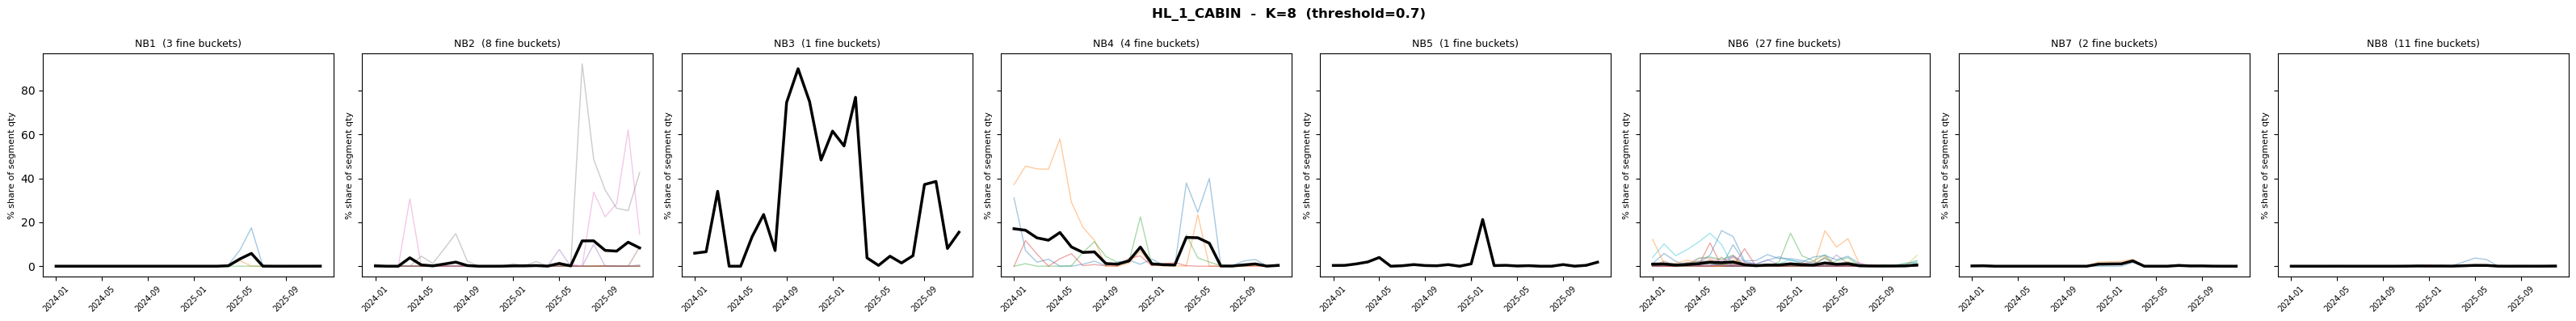

In [28]:
# Cell 27 - Diagnostic: plot trend lines coloured by New Bucket
# Change SEG_KEY to inspect any segment

from collections import defaultdict

SEG_KEY = pilot_key   # ← change this to any segment key

info    = segment_pivots[SEG_KEY]
pivot   = info['pivot']
div, portal, size = info['div'], info['portal'], info['size']
seg_vol = (bucket_ts[(bucket_ts['Division']==div) &
                      (bucket_ts['Portal']==portal) &
                      (bucket_ts['Size']==size)]
           .groupby('bucket_min')['qty'].sum())
fmap    = all_final_maps[SEG_KEY]

groups = defaultdict(list)
for b, nb in fmap.items():
    if seg_vol.get(b, 0) > 0 and b in pivot.index:
        groups[nb].append(b)

k      = len(groups)
months = [str(c)[:7] for c in pivot.columns]

fig, axes = plt.subplots(1, k, figsize=(4*k, 4), sharey=True)
if k == 1:
    axes = [axes]

for ax, (nb, blist) in zip(axes, sorted(groups.items())):
    for b in blist:
        ax.plot(months, pivot.loc[b].values, alpha=0.4, linewidth=1)
    ax.plot(months, pivot.loc[blist].mean().values,
            color='black', linewidth=2.5)
    ax.set_title(f'NB{nb}  ({len(blist)} fine buckets)', fontsize=9)
    ax.set_xticks(range(0, len(months), 4))
    ax.set_xticklabels(months[::4], rotation=45, fontsize=7)
    ax.set_ylabel('% share of segment qty', fontsize=8)

fig.suptitle(f'{SEG_KEY}  -  K={k}  (threshold={TREND_SIMILARITY_THRESHOLD})',
             fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# HL_CABIN - Complete inspection: buckets, groups, keys, volume
import pandas as pd

SEG = next((k for k in sorted(segment_pivots.keys()) if '_CABIN' in k), sorted(segment_pivots.keys())[0])

# Load the saved outputs
mapping = pd.read_csv(f'{OUT_PATH}archetype_mapping.csv')
keys    = pd.read_csv(f'{OUT_PATH}archetype_keys.csv')

hl = mapping[(mapping['Division']=='HL') & (mapping['Size']=='CABIN')].copy()
hl_keys = keys[(keys['Division']=='HL') & (keys['Size']=='CABIN')].copy()

total_qty = hl['total_qty'].sum()

print("=" * 65)
print(f"HL/CABIN - Auto-K = {hl['New_Bucket'].nunique()}  (threshold={TREND_SIMILARITY_THRESHOLD})")
print("=" * 65)

print(f"\n{'NB':<5} {'Archetype Key':<16} {'Price Range':>22}  {'Vol':>9}  {'Vol%':>6}  {'Fine Buckets':>12}")
print("-" * 80)

for nb in sorted(hl_keys['New_Bucket'].unique()):
    row      = hl_keys[hl_keys['New_Bucket']==nb].iloc[0]
    nb_rows  = hl[hl['New_Bucket']==nb]
    vol      = row['total_qty']
    pct      = 100 * vol / total_qty if total_qty > 0 else 0
    n_fine   = row['fine_bucket_count']
    key      = row['archetype_key']
    pmin     = row['price_range_min']
    pmax     = row['price_range_max']
    print(f"NB{nb:<3} {key:<16} ₹{pmin:>6,} - ₹{pmax:>6,}  {vol:>9,}  {pct:>5.1f}%  {n_fine:>5} buckets")

print("-" * 80)
print(f"{'TOTAL':<5} {'':16} {'':>22}  {int(total_qty):>9,}  100.0%")

print(f"\n\n=== Archetype Keys generated for HL/CABIN ===")
for k in sorted(hl_keys['archetype_key'].tolist()):
    print(f"  {k}")

HL/CABIN - Auto-K = 8  (threshold=0.7)

NB    Archetype Key               Price Range        Vol    Vol%  Fine Buckets
--------------------------------------------------------------------------------
NB1   HLTT11CABIN      ₹     0 - ₹   499      3,040    0.5%      3 buckets
NB2   HLTT12CABIN      ₹   500 - ₹ 1,299    294,621   44.9%      8 buckets
NB3   HLTT13CABIN      ₹ 1,300 - ₹ 1,399    186,476   28.4%      1 buckets
NB4   HLTT14CABIN      ₹ 1,400 - ₹ 1,799     86,939   13.3%      4 buckets
NB5   HLTT15CABIN      ₹ 1,800 - ₹ 1,899      5,762    0.9%      1 buckets
NB6   HLTT16CABIN      ₹ 1,900 - ₹ 4,599     74,036   11.3%     27 buckets
NB7   HLTT17CABIN      ₹ 4,600 - ₹ 4,799      2,176    0.3%      2 buckets
NB8   HLTT18CABIN      ₹ 4,800 - ₹ 8,399      2,560    0.4%     11 buckets
--------------------------------------------------------------------------------
TOTAL                                            655,610  100.0%


=== Archetype Keys generated for HL/CABIN ===
  HLTT

In [30]:
# Skip TT-channel diagnostic if portal data is string-based (EC channel)
_pilot_key = sorted(segment_pivots.keys())[0]
_pilot_info = segment_pivots[_pilot_key]
if isinstance(_pilot_info['portal'], int):
    # HL_CABIN - Full inspection: detailed CSV + trend pivot + year/month breakdown

    import matplotlib.pyplot as plt
    from collections import defaultdict

    SEG    = 'HL_1_CABIN'
    OUTDIR = f'{OUT_PATH}'

    # ── Load outputs ──────────────────────────────────────────────────────────
    mapping = pd.read_csv(f'{OUT_PATH}archetype_mapping.csv')
    hl      = mapping[(mapping['Division']=='HL') & (mapping['Size']=='CABIN')].copy()

    bts = pd.read_csv(f'{OUT_PATH}02_fine_bucket_ts.csv')
    bts['sale_date'] = pd.to_datetime(bts['sale_date'])
    bts['year']      = bts['sale_date'].dt.year
    bts['month']     = bts['sale_date'].dt.month

    hl_bts = bts[(bts['Division']=='HL') & (bts['Portal']==1) & (bts['Size']=='CABIN')].copy()

    # ── Attach New_Bucket to monthly data ─────────────────────────────────────
    nb_lookup = hl[['bucket_min','New_Bucket','archetype_key']].drop_duplicates()
    hl_bts    = hl_bts.merge(nb_lookup, on='bucket_min', how='left')

    total_qty = hl_bts['qty'].sum()
    nb_list   = sorted(hl_bts['New_Bucket'].dropna().unique().astype(int))

    # ─────────────────────────────────────────────────────────────────────────
    # CSV 1 - Detail: every bucket x year x month
    # ─────────────────────────────────────────────────────────────────────────
    detail = (hl_bts
              .groupby(['New_Bucket','archetype_key','bucket_min','year','month'])
              [['qty']]
              .sum()
              .reset_index())
    detail['vol_pct'] = (100 * detail['qty'] / total_qty).round(3)
    detail = detail.sort_values(['New_Bucket','bucket_min','year','month'])
    detail.to_csv(f'{OUTDIR}HL_CABIN_detail.csv', index=False)
    print(f"Saved: HL_CABIN_detail.csv  ({len(detail)} rows)")

    # ─────────────────────────────────────────────────────────────────────────
    # CSV 2 - Trend pivot: rows=month, cols=year, values=qty  (Excel-style)
    # ─────────────────────────────────────────────────────────────────────────
    pivot_rows = []
    for nb in nb_list:
        nb_data = hl_bts[hl_bts['New_Bucket']==nb]
        key     = nb_data['archetype_key'].iloc[0]

        piv = (nb_data.groupby(['month','year'])['qty']
               .sum()
               .unstack('year')
               .fillna(0)
               .astype(int))
        piv.index.name = 'month'
        piv.columns    = [f'qty_{y}' for y in piv.columns]
        piv            = piv.reset_index()
        piv.insert(0, 'New_Bucket',    nb)
        piv.insert(1, 'archetype_key', key)

        for col in [c for c in piv.columns if c.startswith('qty_')]:
            yr       = int(col.replace('qty_',''))
            yr_total = hl_bts[hl_bts['year']==yr]['qty'].sum()
            piv[f'pct_{yr}'] = (100 * piv[col] / yr_total).round(3)

        pivot_rows.append(piv)

    trend_pivot = pd.concat(pivot_rows, ignore_index=True)
    trend_pivot.to_csv(f'{OUTDIR}HL_CABIN_trend_pivot.csv', index=False)
    print(f"Saved: HL_CABIN_trend_pivot.csv  ({len(trend_pivot)} rows)")

    # ─────────────────────────────────────────────────────────────────────────
    # CSV 3 - Summary: one row per New_Bucket
    # ─────────────────────────────────────────────────────────────────────────
    summary_rows = []
    for nb in nb_list:
        nb_data  = hl[hl['New_Bucket']==nb]
        nb_month = hl_bts[hl_bts['New_Bucket']==nb]
        key      = nb_data['archetype_key'].iloc[0]
        vol      = int(nb_month['qty'].sum())
        pct      = round(100 * vol / total_qty, 2)
        pmin     = int(nb_data['bucket_min'].min())
        pmax     = int(nb_data['bucket_max'].max())
        n_fine   = int((nb_data['total_qty'] > 0).sum())
        yr_vols  = nb_month.groupby('year')['qty'].sum().to_dict()

        summary_rows.append({
            'New_Bucket':      nb,
            'archetype_key':   key,
            'price_range_min': pmin,
            'price_range_max': pmax,
            'fine_buckets':    n_fine,
            'total_qty':       vol,
            'vol_pct':         pct,
            **{f'qty_{int(y)}': int(v) for y, v in sorted(yr_vols.items())}
        })

    summary = pd.DataFrame(summary_rows).fillna(0)
    summary.to_csv(f'{OUTDIR}HL_CABIN_summary.csv', index=False)
    print(f"Saved: HL_CABIN_summary.csv  ({len(summary)} rows)")

    # ─────────────────────────────────────────────────────────────────────────
    # Print summary table to screen
    # ─────────────────────────────────────────────────────────────────────────
    yr_cols = [c for c in summary.columns if c.startswith('qty_')]

    print(f"\n{'='*75}")
    print(f"HL/CABIN - K={len(nb_list)}   threshold={TREND_SIMILARITY_THRESHOLD}")
    print(f"{'='*75}")
    header = f"{'NB':<5} {'Key':<16} {'Price Range':>22}  {'Vol':>9}  {'Pct':>6}  {'Fine':>5}"
    for c in yr_cols:
        header += f"  {c:>10}"
    print(header)
    print("-" * len(header))

    for _, row in summary.iterrows():
        line = (f"NB{int(row['New_Bucket']):<3} {row['archetype_key']:<16} "
                f"₹{int(row['price_range_min']):>6,}-₹{int(row['price_range_max']):>6,}  "
                f"{int(row['total_qty']):>9,}  {row['vol_pct']:>5.1f}%  {int(row['fine_buckets']):>5}")
        for c in yr_cols:
            val = row.get(c, 0)
            line += f"  {int(val if pd.notna(val) else 0):>10,}"
        print(line)

    # ─────────────────────────────────────────────────────────────────────────
    # TREND PLOTS - Row 1: % share trend lines | Row 2: monthly qty by year
    # ─────────────────────────────────────────────────────────────────────────
    info         = segment_pivots[SEG]
    pivot_matrix = info['pivot']
    years        = sorted(hl_bts['year'].dropna().unique().astype(int))
    colors       = {years[0]: '#2196F3', years[1]: '#FF5722'} if len(years) >= 2 else {years[0]: '#2196F3'}

    fig, axes = plt.subplots(2, len(nb_list), figsize=(4*len(nb_list), 8))
    if len(nb_list) == 1:
        axes = [[axes[0]], [axes[1]]]

    month_labels = [str(c)[:7] for c in pivot_matrix.columns]

    for col_i, nb in enumerate(nb_list):
        nb_data = hl[hl['New_Bucket']==nb]
        key     = nb_data['archetype_key'].iloc[0]
        buckets = sorted([b for b in nb_data['bucket_min'].unique()
                          if b in pivot_matrix.index
                          and (pivot_matrix.loc[b] > 0).sum() >= MIN_HISTORY_MONTHS])

        # Row 1 - % share trend lines
        ax1 = axes[0][col_i]
        if buckets:
            for b in buckets:
                ax1.plot(month_labels, pivot_matrix.loc[b].values,
                         alpha=0.4, linewidth=1)
            ax1.plot(month_labels, pivot_matrix.loc[buckets].mean().values,
                     color='black', linewidth=2.5, label='mean')
        ax1.set_title(f'{key}\n({len(buckets)} buckets)', fontsize=8, fontweight='bold')
        ax1.set_xticks(range(0, len(month_labels), 4))
        ax1.set_xticklabels(month_labels[::4], rotation=45, fontsize=6)
        ax1.set_ylabel('% share of seg qty', fontsize=7)

        # Row 2 - monthly qty bars split by year
        ax2        = axes[1][col_i]
        nb_monthly = hl_bts[hl_bts['New_Bucket']==nb]
        width      = 0.35
        for yr_i, yr in enumerate(years):
            yr_data = (nb_monthly[nb_monthly['year']==yr]
                       .groupby('month')['qty'].sum()
                       .reindex(range(1,13), fill_value=0))
            x = np.arange(1, 13) + (yr_i - 0.5*(len(years)-1)) * width
            ax2.bar(x, yr_data.values, width=width,
                    label=str(yr), color=colors.get(yr,'grey'), alpha=0.8)
        ax2.set_xticks(range(1,13))
        ax2.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=7)
        ax2.set_ylabel('qty sold', fontsize=7)
        ax2.legend(fontsize=6)
        nb_vol = int(nb_monthly['qty'].sum())
        ax2.set_title(f'vol={nb_vol:,}  ({100*nb_vol/total_qty:.1f}%)', fontsize=7)

    fig.suptitle(
        f'HL/CABIN - K={len(nb_list)}  (threshold={TREND_SIMILARITY_THRESHOLD})\n'
        f'Row 1: % share trend lines  |  Row 2: monthly qty by year',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f'{OUTDIR}HL_CABIN_full_analysis.png', dpi=130, bbox_inches='tight')
    plt.show()

    print(f"\nAll files saved to: {OUTDIR}")
    print("  HL_CABIN_summary.csv       ← one row per NB, price range, vol, year split")
    print("  HL_CABIN_detail.csv        ← every fine bucket x year x month")
    print("  HL_CABIN_trend_pivot.csv   ← month x year pivot per NB (like manual Excel)")
    print("  HL_CABIN_full_analysis.png ← trend lines + monthly bar chart per NB")
else:
    print("Skipping TT-only diagnostic (EC channel uses string portals)")


Skipping TT-only diagnostic (EC channel uses string portals)


In [31]:
# Skip TT-channel diagnostic if portal data is string-based (EC channel)
_pilot_key = sorted(segment_pivots.keys())[0]
_pilot_info = segment_pivots[_pilot_key]
if isinstance(_pilot_info['portal'], int):
    # HL_CABIN - Full inspection: detailed CSV + trend pivot + year/month breakdown
    # Source of truth:
    #   qty data     → 02_fine_bucket_ts.csv  (already bucketed, no net_sales)
    #   net_sales    → 01_clean_sales.csv     (raw transactions, has net_sales)
    #   bucket_min for raw → computed as floor(net_sales/qty / 100) * 100

    import matplotlib.pyplot as plt
    from collections import defaultdict

    SEG    = 'HL_1_CABIN'
    OUTDIR = f'{OUT_PATH}'

    # ── Load archetype mapping ────────────────────────────────────────────────
    mapping = pd.read_csv(f'{OUT_PATH}archetype_mapping.csv')
    hl_map  = (mapping[(mapping['Division']=='HL') & (mapping['Size']=='CABIN')]
               [['bucket_min','New_Bucket','archetype_key']]
               .drop_duplicates())

    # ── Load 02_fine_bucket_ts - qty source ──────────────────────────────────
    bts = pd.read_csv(f'{OUT_PATH}02_fine_bucket_ts.csv')
    bts['sale_date'] = pd.to_datetime(bts['sale_date'])
    bts['year']      = bts['sale_date'].dt.year
    bts['month']     = bts['sale_date'].dt.month

    hl_bts = bts[
        (bts['Division']=='HL') &
        (bts['Portal']==1) &
        (bts['Size']=='CABIN')
    ].copy()
    hl_bts = hl_bts.merge(hl_map, on='bucket_min', how='left')

    # ── Load 01_clean_sales - net_sales source ───────────────────────────────
    clean = pd.read_csv(f'{OUT_PATH}01_clean_sales.csv')
    clean['sale_date'] = pd.to_datetime(clean['sale_date'])
    clean['year']      = clean['sale_date'].dt.year
    clean['month']     = clean['sale_date'].dt.month

    hl_raw = clean[
        (clean['Division']=='HL') &
        (clean['Portal']==1) &
        (clean['Size']=='CABIN')
    ].copy()

    # Compute bucket_min from raw ASP so we can join to archetype mapping
    hl_raw['ASP_raw']    = hl_raw['net_sales'] / hl_raw['qty'].replace(0, np.nan)
    hl_raw['bucket_min'] = (np.floor(hl_raw['ASP_raw'] / 100) * 100).fillna(0).astype(int)
    hl_raw = hl_raw.merge(hl_map, on='bucket_min', how='left')

    # ── Totals and segment info ───────────────────────────────────────────────
    total_qty    = hl_bts['qty'].sum()
    years_avail  = sorted(hl_bts['year'].dropna().unique().astype(int))
    nb_list      = sorted(hl_bts['New_Bucket'].dropna().unique().astype(int))

    print(f"HL/CABIN summary")
    print(f"  Total qty (from bts)  : {total_qty:,}")
    print(f"  Years available       : {years_avail}")
    print(f"  New Buckets (K)       : {len(nb_list)}")


    # ─────────────────────────────────────────────────────────────────────────
    # CSV 1 - Detail: every bucket x year x month
    #          qty from bts | net_sales + ASP from raw sales
    # ─────────────────────────────────────────────────────────────────────────
    qty_detail = (hl_bts
                  .groupby(['New_Bucket','archetype_key','bucket_min','year','month'],
                           dropna=False)['qty']
                  .sum()
                  .reset_index())

    ns_detail = (hl_raw
                 .groupby(['New_Bucket','bucket_min','year','month'],
                          dropna=False)['net_sales']
                 .sum()
                 .reset_index())

    detail = qty_detail.merge(ns_detail,
                              on=['New_Bucket','bucket_min','year','month'],
                              how='left').fillna(0)
    detail['ASP']     = (detail['net_sales'] / detail['qty'].replace(0, np.nan)).round(2)
    detail['vol_pct'] = (100 * detail['qty'] / total_qty).round(4)
    detail = detail.sort_values(['New_Bucket','bucket_min','year','month'])

    detail.to_csv(f'{OUTDIR}HL_CABIN_detail.csv', index=False)
    print(f"\nSaved: HL_CABIN_detail.csv  ({len(detail)} rows)")
    print(f"  Columns: {detail.columns.tolist()}")


    # ─────────────────────────────────────────────────────────────────────────
    # CSV 2 - Trend pivot: rows = NB x month, cols = year
    #          qty, net_sales, ASP, pct_share per year
    # ─────────────────────────────────────────────────────────────────────────
    pivot_rows = []

    for nb in nb_list:
        nb_bts = hl_bts[hl_bts['New_Bucket']==nb]
        nb_raw = hl_raw[hl_raw['New_Bucket']==nb]
        key    = hl_map[hl_map['New_Bucket']==nb]['archetype_key'].iloc[0]

        for month in range(1, 13):
            row_dict = {
                'New_Bucket':    nb,
                'archetype_key': key,
                'month':         month,
            }
            for yr in years_avail:
                bts_slice = nb_bts[(nb_bts['year']==yr) & (nb_bts['month']==month)]
                raw_slice = nb_raw[(nb_raw['year']==yr) & (nb_raw['month']==month)]
                q         = int(bts_slice['qty'].sum())
                ns        = round(float(raw_slice['net_sales'].sum()), 2)
                asp       = round(ns / q, 2) if q > 0 else np.nan
                yr_total  = hl_bts[hl_bts['year']==yr]['qty'].sum()
                pct       = round(100 * q / yr_total, 4) if yr_total > 0 else 0.0
                row_dict[f'qty_{yr}']       = q
                row_dict[f'net_sales_{yr}'] = ns
                row_dict[f'ASP_{yr}']       = asp
                row_dict[f'pct_share_{yr}'] = pct
            pivot_rows.append(row_dict)

    trend_pivot = pd.DataFrame(pivot_rows)
    trend_pivot.to_csv(f'{OUTDIR}HL_CABIN_trend_pivot.csv', index=False)
    print(f"Saved: HL_CABIN_trend_pivot.csv  ({len(trend_pivot)} rows)")
    print(f"  Columns: {trend_pivot.columns.tolist()}")


    # ─────────────────────────────────────────────────────────────────────────
    # CSV 3 - Summary: one row per New_Bucket
    #          total + per-year qty, net_sales, ASP
    # ─────────────────────────────────────────────────────────────────────────
    summary_rows = []

    for nb in nb_list:
        nb_bts   = hl_bts[hl_bts['New_Bucket']==nb]
        nb_raw   = hl_raw[hl_raw['New_Bucket']==nb]
        nb_mapdf = mapping[(mapping['Division']=='HL') &
                           (mapping['Size']=='CABIN') &
                           (mapping['New_Bucket']==nb)]
        key    = hl_map[hl_map['New_Bucket']==nb]['archetype_key'].iloc[0]
        pmin   = int(nb_mapdf['bucket_min'].min())
        pmax   = int(nb_mapdf['bucket_max'].max())
        n_fine = int(nb_bts['bucket_min'].nunique())
        vol    = int(nb_bts['qty'].sum())
        ns_tot = round(float(nb_raw['net_sales'].sum()), 2)
        asp    = round(ns_tot / vol, 2) if vol > 0 else np.nan
        pct    = round(100 * vol / total_qty, 2)

        row_dict = {
            'New_Bucket':      nb,
            'archetype_key':   key,
            'price_range_min': pmin,
            'price_range_max': pmax,
            'fine_buckets':    n_fine,
            'total_qty':       vol,
            'total_net_sales': ns_tot,
            'overall_ASP':     asp,
            'vol_pct':         pct,
        }
        for yr in years_avail:
            q   = int(nb_bts[nb_bts['year']==yr]['qty'].sum())
            ns  = round(float(nb_raw[nb_raw['year']==yr]['net_sales'].sum()), 2)
            asp_yr = round(ns / q, 2) if q > 0 else np.nan
            row_dict[f'qty_{yr}']       = q
            row_dict[f'net_sales_{yr}'] = ns
            row_dict[f'ASP_{yr}']       = asp_yr

        summary_rows.append(row_dict)

    summary = pd.DataFrame(summary_rows).fillna(0)
    summary.to_csv(f'{OUTDIR}HL_CABIN_summary.csv', index=False)
    print(f"Saved: HL_CABIN_summary.csv  ({len(summary)} rows)")
    print(f"  Columns: {summary.columns.tolist()}")


    # ─────────────────────────────────────────────────────────────────────────
    # Print summary table to screen
    # ─────────────────────────────────────────────────────────────────────────
    yr_q_cols = [f'qty_{y}' for y in years_avail]
    print(f"\n{'='*85}")
    print(f"HL/CABIN - K={len(nb_list)}   threshold={TREND_SIMILARITY_THRESHOLD}")
    print(f"{'='*85}")
    hdr = (f"{'NB':<5} {'Key':<16} {'Price Range':>22}  "
           f"{'TotalQty':>9}  {'Pct':>6}  {'ASP':>7}  {'Fine':>5}")
    for c in yr_q_cols:
        hdr += f"  {c:>9}"
    print(hdr)
    print("-" * len(hdr))
    for _, row in summary.iterrows():
        line = (f"NB{int(row['New_Bucket']):<3} {row['archetype_key']:<16} "
                f"₹{int(row['price_range_min']):>6,}-₹{int(row['price_range_max']):>6,}  "
                f"{int(row['total_qty']):>9,}  {row['vol_pct']:>5.1f}%  "
                f"₹{row['overall_ASP']:>6.0f}  {int(row['fine_buckets']):>5}")
        for c in yr_q_cols:
            val = row.get(c, 0)
            line += f"  {int(val if pd.notna(val) else 0):>9,}"
        print(line)


    # ─────────────────────────────────────────────────────────────────────────
    # TREND PLOTS - Row 1: % share trends | Row 2: monthly qty by year
    # ─────────────────────────────────────────────────────────────────────────
    info         = segment_pivots[SEG]
    pivot_matrix = info['pivot']
    colors       = ({years_avail[0]: '#2196F3', years_avail[1]: '#FF5722'}
                    if len(years_avail) >= 2 else {years_avail[0]: '#2196F3'})
    month_labels = [str(c)[:7] for c in pivot_matrix.columns]

    fig, axes = plt.subplots(2, len(nb_list), figsize=(4*len(nb_list), 8))
    if len(nb_list) == 1:
        axes = [[axes[0]], [axes[1]]]

    for col_i, nb in enumerate(nb_list):
        nb_mapdf = hl_map[hl_map['New_Bucket']==nb]
        key      = nb_mapdf['archetype_key'].iloc[0]
        buckets  = sorted([b for b in nb_mapdf['bucket_min'].unique()
                           if b in pivot_matrix.index
                           and (pivot_matrix.loc[b] > 0).sum() >= MIN_HISTORY_MONTHS])

        # Row 1 - % share trend lines from NB03 pivot
        ax1 = axes[0][col_i]
        if buckets:
            for b in buckets:
                ax1.plot(month_labels, pivot_matrix.loc[b].values,
                         alpha=0.4, linewidth=1)
            ax1.plot(month_labels, pivot_matrix.loc[buckets].mean().values,
                     color='black', linewidth=2.5)
        ax1.set_title(f'{key}\n({len(buckets)} fine buckets)', fontsize=8, fontweight='bold')
        ax1.set_xticks(range(0, len(month_labels), 4))
        ax1.set_xticklabels(month_labels[::4], rotation=45, fontsize=6)
        ax1.set_ylabel('% share', fontsize=7)

        # Row 2 - monthly qty bars split by year (from bts)
        ax2       = axes[1][col_i]
        nb_monthly = hl_bts[hl_bts['New_Bucket']==nb]
        width     = 0.35
        for yr_i, yr in enumerate(years_avail):
            yr_data = (nb_monthly[nb_monthly['year']==yr]
                       .groupby('month')['qty'].sum()
                       .reindex(range(1, 13), fill_value=0))
            x = np.arange(1, 13) + (yr_i - 0.5*(len(years_avail)-1)) * width
            ax2.bar(x, yr_data.values, width=width,
                    label=str(yr), color=colors.get(yr,'grey'), alpha=0.8)
        ax2.set_xticks(range(1, 13))
        ax2.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=7)
        ax2.set_ylabel('qty sold', fontsize=7)
        ax2.legend(fontsize=6)
        nb_vol = int(nb_monthly['qty'].sum())
        ax2.set_title(f'{nb_vol:,} units  ({100*nb_vol/total_qty:.1f}%)', fontsize=7)

    fig.suptitle(
        f'HL/CABIN - K={len(nb_list)}  (threshold={TREND_SIMILARITY_THRESHOLD})\n'
        f'Row 1: % share trend (NB03 pivot)  |  Row 2: monthly qty by year (bts)',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f'{OUTDIR}HL_CABIN_full_analysis.png', dpi=130, bbox_inches='tight')
    plt.show()

    print(f"\nAll outputs saved to: {OUTDIR}")
    print("  HL_CABIN_detail.csv        - bucket x year x month  (qty, net_sales, ASP, vol_pct)")
    print("  HL_CABIN_trend_pivot.csv   - NB x month x year  (qty, net_sales, ASP, pct_share)")
    print("  HL_CABIN_summary.csv       - one row per NB  (total + per-year qty, net_sales, ASP)")
    print("  HL_CABIN_full_analysis.png - trend lines + monthly qty bars")
else:
    print("Skipping TT-only diagnostic (EC channel uses string portals)")


Skipping TT-only diagnostic (EC channel uses string portals)


In [32]:
# Reshape HL_CABIN_trend_pivot.csv -- long format for clean Excel pivot chart
# Skip if file does not exist (EC channel skips this TT-specific diagnostic)
import os as _os
if not _os.path.exists(f'{OUT_PATH}HL_CABIN_trend_pivot.csv'):
    print('Skipping HL_CABIN_trend_pivot reshape (file not created for this channel)')
else:
    # Reshape HL_CABIN_trend_pivot.csv → long format for clean Excel pivot chart
    
    trend_pivot = pd.read_csv(f'{OUT_PATH}HL_CABIN_trend_pivot.csv')
    
    # Extract just qty columns, melt into long format
    qty_cols = [c for c in trend_pivot.columns if c.startswith('qty_')]
    
    long = trend_pivot[['New_Bucket','archetype_key','month'] + qty_cols].melt(
        id_vars    = ['New_Bucket','archetype_key','month'],
        value_vars = qty_cols,
        var_name   = 'year',
        value_name = 'qty'
    )
    
    # Clean year column: "qty_2024" → 2024
    long['year'] = long['year'].str.replace('qty_','').astype(int)
    long = long.sort_values(['New_Bucket','year','month']).reset_index(drop=True)
    
    long.to_csv(f'{OUT_PATH}HL_CABIN_pivot_ready.csv', index=False)
    print(f"Saved: HL_CABIN_pivot_ready.csv  ({len(long)} rows)")
    print(long.head(24).to_string(index=False))
    

Skipping HL_CABIN_trend_pivot reshape (file not created for this channel)


In [33]:
# Skip TT-channel diagnostic if portal data is string-based (EC channel)
_pilot_key = sorted(segment_pivots.keys())[0]
_pilot_info = segment_pivots[_pilot_key]
if isinstance(_pilot_info['portal'], int):
    # HL ALL SIZES - Full analysis: CSVs + trend charts + pivot-ready file
    # Generates same outputs as HL/CABIN cell but for ALL HL sizes

    import matplotlib.pyplot as plt
    from collections import defaultdict

    HL_SIZES = ['CABIN', 'LARGE', 'MEDIUM', 'SO2', 'SO3']
    OUTDIR   = f'{OUT_PATH}'

    # Load data once
    mapping  = pd.read_csv(f'{OUT_PATH}archetype_mapping.csv')
    bts      = pd.read_csv(f'{OUT_PATH}02_fine_bucket_ts.csv')
    bts['sale_date'] = pd.to_datetime(bts['sale_date'])
    bts['year']      = bts['sale_date'].dt.year
    bts['month']     = bts['sale_date'].dt.month

    clean    = pd.read_csv(f'{OUT_PATH}01_clean_sales.csv')
    clean['sale_date'] = pd.to_datetime(clean['sale_date'])
    clean['year']      = clean['sale_date'].dt.year
    clean['month']     = clean['sale_date'].dt.month

    for SIZE in HL_SIZES:
        print(f'\n{"="*60}')
        print(f'Processing HL/{SIZE}')
        print(f'{"="*60}')

        seg_key = f'HL_1_{SIZE}'

        # ── Segment data ─────────────────────────────────────────────
        hl_map = (mapping[(mapping['Division']=='HL') & (mapping['Size']==SIZE)]
                  [['bucket_min','New_Bucket','archetype_key']]
                  .drop_duplicates())

        hl_bts = bts[(bts['Division']=='HL') & (bts['Portal']==1) & (bts['Size']==SIZE)].copy()
        hl_bts = hl_bts.merge(hl_map, on='bucket_min', how='left')

        hl_raw = clean[(clean['Division']=='HL') & (clean['Portal']==1) & (clean['Size']==SIZE)].copy()
        hl_raw['ASP_raw']    = hl_raw['net_sales'] / hl_raw['qty'].replace(0, np.nan)
        hl_raw['bucket_min'] = (np.floor(hl_raw['ASP_raw'] / 100) * 100).fillna(0).astype(int)
        hl_raw = hl_raw.merge(hl_map, on='bucket_min', how='left')

        total_qty   = hl_bts['qty'].sum()
        years_avail = sorted(hl_bts['year'].dropna().unique().astype(int))
        nb_list     = sorted(hl_bts['New_Bucket'].dropna().unique().astype(int))

        print(f'  Total qty   : {total_qty:,}')
        print(f'  K (buckets) : {len(nb_list)}')
        print(f'  Years       : {years_avail}')

        # ── CSV 1: Detail ─────────────────────────────────────────────
        qty_detail = (hl_bts
                      .groupby(['New_Bucket','archetype_key','bucket_min','year','month'],
                                dropna=False)['qty'].sum().reset_index())
        ns_detail = (hl_raw
                     .groupby(['New_Bucket','bucket_min','year','month'],
                               dropna=False)['net_sales'].sum().reset_index())
        detail = qty_detail.merge(ns_detail,
                                  on=['New_Bucket','bucket_min','year','month'],
                                  how='left').fillna(0)
        detail['ASP']     = (detail['net_sales'] / detail['qty'].replace(0, np.nan)).round(2)
        detail['vol_pct'] = (100 * detail['qty'] / total_qty).round(4)
        detail = detail.sort_values(['New_Bucket','bucket_min','year','month'])
        detail.to_csv(f'{OUTDIR}HL_{SIZE}_detail.csv', index=False)
        print(f'  Saved: HL_{SIZE}_detail.csv  ({len(detail)} rows)')

        # ── CSV 2: Trend pivot ────────────────────────────────────────
        pivot_rows = []
        for nb in nb_list:
            nb_bts = hl_bts[hl_bts['New_Bucket']==nb]
            nb_raw = hl_raw[hl_raw['New_Bucket']==nb]
            key    = hl_map[hl_map['New_Bucket']==nb]['archetype_key'].iloc[0]
            for month in range(1, 13):
                row_dict = {'New_Bucket': nb, 'archetype_key': key, 'month': month}
                for yr in years_avail:
                    bts_s = nb_bts[(nb_bts['year']==yr) & (nb_bts['month']==month)]
                    raw_s = nb_raw[(nb_raw['year']==yr) & (nb_raw['month']==month)]
                    q     = int(bts_s['qty'].sum())
                    ns    = round(float(raw_s['net_sales'].sum()), 2)
                    asp   = round(ns / q, 2) if q > 0 else np.nan
                    yr_t  = hl_bts[hl_bts['year']==yr]['qty'].sum()
                    pct   = round(100 * q / yr_t, 4) if yr_t > 0 else 0.0
                    row_dict[f'qty_{yr}']        = q
                    row_dict[f'net_sales_{yr}']  = ns
                    row_dict[f'ASP_{yr}']        = asp
                    row_dict[f'pct_share_{yr}']  = pct
                pivot_rows.append(row_dict)
        trend_pivot = pd.DataFrame(pivot_rows)
        trend_pivot.to_csv(f'{OUTDIR}HL_{SIZE}_trend_pivot.csv', index=False)
        print(f'  Saved: HL_{SIZE}_trend_pivot.csv')

        # ── CSV 3: Pivot-ready (long format for Excel chart) ─────────
        qty_cols = [c for c in trend_pivot.columns if c.startswith('qty_')]
        long = trend_pivot[['New_Bucket','archetype_key','month'] + qty_cols].melt(
            id_vars=['New_Bucket','archetype_key','month'],
            value_vars=qty_cols, var_name='year', value_name='qty')
        long['year'] = long['year'].str.replace('qty_','').astype(int)
        long = long.sort_values(['New_Bucket','year','month']).reset_index(drop=True)
        long.to_csv(f'{OUTDIR}HL_{SIZE}_pivot_ready.csv', index=False)
        print(f'  Saved: HL_{SIZE}_pivot_ready.csv  ← use this in Excel for charts')

        # ── CSV 4: Summary ────────────────────────────────────────────
        summary_rows = []
        for nb in nb_list:
            nb_bts   = hl_bts[hl_bts['New_Bucket']==nb]
            nb_raw   = hl_raw[hl_raw['New_Bucket']==nb]
            nb_mapdf = mapping[(mapping['Division']=='HL') &
                                (mapping['Size']==SIZE) &
                                (mapping['New_Bucket']==nb)]
            key    = hl_map[hl_map['New_Bucket']==nb]['archetype_key'].iloc[0]
            pmin   = int(nb_mapdf['bucket_min'].min())
            pmax   = int(nb_mapdf['bucket_max'].max())
            n_fine = int(nb_bts['bucket_min'].nunique())
            vol    = int(nb_bts['qty'].sum())
            ns_tot = round(float(nb_raw['net_sales'].sum()), 2)
            asp    = round(ns_tot / vol, 2) if vol > 0 else np.nan
            pct    = round(100 * vol / total_qty, 2)
            row_d  = {'New_Bucket': nb, 'archetype_key': key,
                      'price_range_min': pmin, 'price_range_max': pmax,
                      'fine_buckets': n_fine, 'total_qty': vol,
                      'total_net_sales': ns_tot, 'overall_ASP': asp, 'vol_pct': pct}
            for yr in years_avail:
                q   = int(nb_bts[nb_bts['year']==yr]['qty'].sum())
                ns  = round(float(nb_raw[nb_raw['year']==yr]['net_sales'].sum()), 2)
                row_d[f'qty_{yr}']       = q
                row_d[f'net_sales_{yr}'] = ns
                row_d[f'ASP_{yr}']       = round(ns/q, 2) if q > 0 else np.nan
            summary_rows.append(row_d)
        summary = pd.DataFrame(summary_rows).fillna(0)
        summary.to_csv(f'{OUTDIR}HL_{SIZE}_summary.csv', index=False)
        print(f'  Saved: HL_{SIZE}_summary.csv')

        # ── Print summary table ───────────────────────────────────────
        yr_q = [f'qty_{y}' for y in years_avail]
        print(f'\n  {"NB":<5} {"Key":<18} {"Price Range":>20}  {"TotalQty":>9}  {"Pct":>6}', end='')
        for c in yr_q: print(f'  {c:>9}', end='')
        print()
        print(f'  {"-"*80}')
        for _, row in summary.iterrows():
            line = (f'  NB{int(row["New_Bucket"]):<3} {row["archetype_key"]:<18} '
                    f'Rs{int(row["price_range_min"]):>6,}-Rs{int(row["price_range_max"]):>6,}  '
                    f'{int(row["total_qty"]):>9,}  {row["vol_pct"]:>5.1f}%')
            for c in yr_q:
                val = row.get(c, 0)
                line += f'  {int(val if pd.notna(val) else 0):>9,}'
            print(line)

        # ── Trend chart: Row 1 = % share lines, Row 2 = monthly bars ─
        if seg_key not in segment_pivots:
            print(f'  No pivot found for {seg_key}, skipping chart')
            continue

        info         = segment_pivots[seg_key]
        pivot_matrix = info['pivot']
        colors       = ({years_avail[0]: '#2196F3', years_avail[1]: '#FF5722'}
                        if len(years_avail) >= 2 else {years_avail[0]: '#2196F3'})
        month_labels = [str(c)[:7] for c in pivot_matrix.columns]

        fig, axes = plt.subplots(2, len(nb_list), figsize=(4*len(nb_list), 8))
        if len(nb_list) == 1:
            axes = [[axes[0]], [axes[1]]]

        for col_i, nb in enumerate(nb_list):
            nb_mapdf = hl_map[hl_map['New_Bucket']==nb]
            key      = nb_mapdf['archetype_key'].iloc[0]
            buckets  = sorted([b for b in nb_mapdf['bucket_min'].unique()
                               if b in pivot_matrix.index
                               and (pivot_matrix.loc[b] > 0).sum() >= MIN_HISTORY_MONTHS])

            # Row 1 - % share trend lines
            ax1 = axes[0][col_i]
            if buckets:
                for b in buckets:
                    ax1.plot(month_labels, pivot_matrix.loc[b].values,
                             alpha=0.4, linewidth=1)
                ax1.plot(month_labels, pivot_matrix.loc[buckets].mean().values,
                         color='black', linewidth=2.5)
            ax1.set_title(f'{key}\n({len(buckets)} buckets)', fontsize=8, fontweight='bold')
            ax1.set_xticks(range(0, len(month_labels), 4))
            ax1.set_xticklabels(month_labels[::4], rotation=45, fontsize=6)
            ax1.set_ylabel('% share', fontsize=7)

            # Row 2 - monthly qty bars by year
            ax2        = axes[1][col_i]
            nb_monthly = hl_bts[hl_bts['New_Bucket']==nb]
            width      = 0.35
            for yr_i, yr in enumerate(years_avail):
                yr_data = (nb_monthly[nb_monthly['year']==yr]
                           .groupby('month')['qty'].sum()
                           .reindex(range(1, 13), fill_value=0))
                x = np.arange(1, 13) + (yr_i - 0.5*(len(years_avail)-1)) * width
                ax2.bar(x, yr_data.values, width=width,
                        label=str(yr), color=colors.get(yr, 'grey'), alpha=0.8)
            ax2.set_xticks(range(1, 13))
            ax2.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=7)
            ax2.set_ylabel('qty sold', fontsize=7)
            ax2.legend(fontsize=6)
            nb_vol = int(nb_monthly['qty'].sum())
            ax2.set_title(f'{nb_vol:,}  ({100*nb_vol/total_qty:.1f}%)', fontsize=7)

        fig.suptitle(
            f'HL/{SIZE} - K={len(nb_list)}  (threshold={TREND_SIMILARITY_THRESHOLD})\n'
            f'Row 1: % share trend  |  Row 2: monthly qty 2024 vs 2025',
            fontsize=11, fontweight='bold'
        )
        plt.tight_layout()
        plt.savefig(f'{OUTDIR}HL_{SIZE}_full_analysis.png', dpi=130, bbox_inches='tight')
        plt.show()
        print(f'  Saved: HL_{SIZE}_full_analysis.png')

    print('\n\nDone. Files saved for all HL sizes:')
    for SIZE in HL_SIZES:
        print(f'  HL_{SIZE}_detail.csv')
        print(f'  HL_{SIZE}_trend_pivot.csv')
        print(f'  HL_{SIZE}_pivot_ready.csv   ← open in Excel → PivotTable → Line chart')
        print(f'  HL_{SIZE}_summary.csv')
        print(f'  HL_{SIZE}_full_analysis.png')
        print()
else:
    print("Skipping TT-only diagnostic (EC channel uses string portals)")


Skipping TT-only diagnostic (EC channel uses string portals)


In [34]:
# Skip TT-channel diagnostic if portal data is string-based (EC channel)
_pilot_key = sorted(segment_pivots.keys())[0]
_pilot_info = segment_pivots[_pilot_key]
if isinstance(_pilot_info['portal'], int):
    # ══════════════════════════════════════════════════════════════════
    # ALL 14 SEGMENTS - Complete analysis
    # Generates CSVs + charts + Excel pivot files for every division
    # ══════════════════════════════════════════════════════════════════

    import sys, os
    # Robust src path - works whether run manually or via papermill
    _src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
    if _src_path not in sys.path:
        sys.path.insert(0, _src_path)
    from config import *
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt

    # ── All 14 segments ───────────────────────────────────────────────
    ALL_SEGMENTS = {
        'HL': ['CABIN', 'LARGE', 'MEDIUM', 'SO2', 'SO3'],
        'SL': ['CABIN', 'LARGE', 'MEDIUM', 'SO2', 'SO3'],
        'BP': ['Single'],
        'BS': ['Single'],
        'DF': ['DF', 'DFT'],
    }

    # ── Load everything once ──────────────────────────────────────────
    mapping = pd.read_csv(f'{OUT_PATH}archetype_mapping.csv')

    bts = pd.read_csv(f'{OUT_PATH}02_fine_bucket_ts.csv')
    bts['sale_date'] = pd.to_datetime(bts['sale_date'])
    bts['year']      = bts['sale_date'].dt.year
    bts['month']     = bts['sale_date'].dt.month

    clean = pd.read_csv(f'{OUT_PATH}01_clean_sales.csv')
    clean['sale_date'] = pd.to_datetime(clean['sale_date'])
    clean['year']      = clean['sale_date'].dt.year
    clean['month']     = clean['sale_date'].dt.month

    master_rows = []   # collects all segments for master summary

    # ── Process each segment ──────────────────────────────────────────
    for DIV, SIZES in ALL_SEGMENTS.items():
        for SIZE in SIZES:

            seg_key = f'{DIV}_1_{SIZE}'
            prefix  = f'{DIV}_{SIZE}'
            print(f'\n{"─"*60}')
            print(f'  Processing  {DIV}/{SIZE}')
            print(f'{"─"*60}')

            # Mapping for this segment
            seg_map = (mapping[
                (mapping['Division']==DIV) & (mapping['Size']==SIZE)
            ][['bucket_min','New_Bucket','archetype_key']].drop_duplicates())

            if len(seg_map) == 0:
                print(f'  No mapping found - skipping')
                continue

            # Qty data
            seg_bts = bts[
                (bts['Division']==DIV) &
                (bts['Portal']==1) &
                (bts['Size']==SIZE)
            ].copy().merge(seg_map, on='bucket_min', how='left')

            # Net sales data - compute bucket_min from raw ASP
            seg_raw = clean[
                (clean['Division']==DIV) &
                (clean['Portal']==1) &
                (clean['Size']==SIZE)
            ].copy()
            seg_raw['ASP_raw']    = (seg_raw['net_sales'] /
                                      seg_raw['qty'].replace(0, np.nan))
            seg_raw['bucket_min'] = (np.floor(seg_raw['ASP_raw'] / 100) * 100
                                      ).fillna(0).astype(int)
            seg_raw = seg_raw.merge(seg_map, on='bucket_min', how='left')

            total_qty   = seg_bts['qty'].sum()
            years_avail = sorted(seg_bts['year'].dropna().unique().astype(int))
            nb_list     = sorted(seg_bts['New_Bucket'].dropna().unique().astype(int))

            print(f'  Volume : {total_qty:,}')
            print(f'  K      : {len(nb_list)}  |  Years: {years_avail}')
            print(f'  Keys   : {sorted(seg_map["archetype_key"].unique())}')

            # ── CSV 1: Detail - bucket x year x month ────────────────
            qty_d = (seg_bts
                     .groupby(['New_Bucket','archetype_key',
                               'bucket_min','year','month'], dropna=False)
                     ['qty'].sum().reset_index())
            ns_d  = (seg_raw
                     .groupby(['New_Bucket','bucket_min',
                               'year','month'], dropna=False)
                     ['net_sales'].sum().reset_index())
            detail = qty_d.merge(ns_d,
                                 on=['New_Bucket','bucket_min','year','month'],
                                 how='left').fillna(0)
            detail['ASP']     = (detail['net_sales'] /
                                  detail['qty'].replace(0, np.nan)).round(2)
            detail['vol_pct'] = (100 * detail['qty'] / total_qty).round(4)
            detail.sort_values(['New_Bucket','bucket_min','year','month'],
                               inplace=True)
            detail.to_csv(f'{OUT_PATH}{prefix}_detail.csv', index=False)
            print(f'  Saved: {prefix}_detail.csv  ({len(detail)} rows)')

            # ── CSV 2: Trend pivot - NB x month, cols = year ─────────
            pivot_rows = []
            for nb in nb_list:
                nb_bts = seg_bts[seg_bts['New_Bucket']==nb]
                nb_raw = seg_raw[seg_raw['New_Bucket']==nb]
                key    = seg_map[seg_map['New_Bucket']==nb]['archetype_key'].iloc[0]
                for month in range(1, 13):
                    row_d = {'New_Bucket': nb, 'archetype_key': key,
                             'month': month}
                    for yr in years_avail:
                        bs = nb_bts[(nb_bts['year']==yr) &
                                    (nb_bts['month']==month)]
                        rs = nb_raw[(nb_raw['year']==yr) &
                                    (nb_raw['month']==month)]
                        q   = int(bs['qty'].sum())
                        ns  = round(float(rs['net_sales'].sum()), 2)
                        asp = round(ns/q, 2) if q > 0 else np.nan
                        yrt = seg_bts[seg_bts['year']==yr]['qty'].sum()
                        pct = round(100*q/yrt, 4) if yrt > 0 else 0.0
                        row_d[f'qty_{yr}']       = q
                        row_d[f'net_sales_{yr}'] = ns
                        row_d[f'ASP_{yr}']       = asp
                        row_d[f'pct_share_{yr}'] = pct
                    pivot_rows.append(row_d)
            trend_pivot = pd.DataFrame(pivot_rows)
            trend_pivot.to_csv(f'{OUT_PATH}{prefix}_trend_pivot.csv', index=False)
            print(f'  Saved: {prefix}_trend_pivot.csv')

            # ── CSV 3: Pivot-ready - long format for Excel chart ─────
            qty_cols = [c for c in trend_pivot.columns if c.startswith('qty_')]
            long = trend_pivot[
                ['New_Bucket','archetype_key','month'] + qty_cols
            ].melt(id_vars=['New_Bucket','archetype_key','month'],
                   value_vars=qty_cols,
                   var_name='year', value_name='qty')
            long['year'] = long['year'].str.replace('qty_','').astype(int)
            long.sort_values(['New_Bucket','year','month'],
                             inplace=True)
            long.to_csv(f'{OUT_PATH}{prefix}_pivot_ready.csv', index=False)
            print(f'  Saved: {prefix}_pivot_ready.csv  <- use in Excel')

            # ── CSV 4: Summary - one row per NB ──────────────────────
            summary_rows = []
            for nb in nb_list:
                nb_bts   = seg_bts[seg_bts['New_Bucket']==nb]
                nb_raw   = seg_raw[seg_raw['New_Bucket']==nb]
                nb_mapdf = mapping[(mapping['Division']==DIV) &
                                   (mapping['Size']==SIZE) &
                                   (mapping['New_Bucket']==nb)]
                key   = seg_map[seg_map['New_Bucket']==nb]['archetype_key'].iloc[0]
                pmin  = int(nb_mapdf['bucket_min'].min())
                pmax  = int(nb_mapdf['bucket_max'].max())
                nfine = int(nb_bts['bucket_min'].nunique())
                vol   = int(nb_bts['qty'].sum())
                ns_t  = round(float(nb_raw['net_sales'].sum()), 2)
                asp   = round(ns_t/vol, 2) if vol > 0 else np.nan
                pct   = round(100*vol/total_qty, 2)
                row_d = {
                    'Division': DIV, 'Size': SIZE,
                    'New_Bucket': nb, 'archetype_key': key,
                    'price_min': pmin, 'price_max': pmax,
                    'fine_buckets': nfine, 'total_qty': vol,
                    'net_sales': ns_t, 'ASP': asp, 'vol_pct': pct
                }
                for yr in years_avail:
                    q  = int(nb_bts[nb_bts['year']==yr]['qty'].sum())
                    ns = round(float(nb_raw[nb_raw['year']==yr]
                                     ['net_sales'].sum()), 2)
                    row_d[f'qty_{yr}']  = q
                    row_d[f'ns_{yr}']   = ns
                    row_d[f'ASP_{yr}']  = round(ns/q,2) if q>0 else np.nan
                summary_rows.append(row_d)
                master_rows.append(row_d)

            summary = pd.DataFrame(summary_rows).fillna(0)
            summary.to_csv(f'{OUT_PATH}{prefix}_summary.csv', index=False)
            print(f'  Saved: {prefix}_summary.csv')

            # Print summary table
            yr_q = [f'qty_{y}' for y in years_avail]
            print(f'\n  {"NB":<4} {"Key":<22} {"Price Range":>20}  '
                  f'{"TotalQty":>9}  {"Pct":>6}', end='')
            for c in yr_q: print(f'  {c:>9}', end='')
            print()
            print(f'  {"─"*80}')
            for _, row in summary.iterrows():
                line = (f'  NB{int(row["New_Bucket"]):<2} '
                        f'{row["archetype_key"]:<22} '
                        f'Rs{int(row["price_min"]):>6,}-'
                        f'Rs{int(row["price_max"]):>7,}  '
                        f'{int(row["total_qty"]):>9,}  '
                        f'{row["vol_pct"]:>5.1f}%')
                for c in yr_q:
                    val = row.get(c, 0)
                    line += f'  {int(val if pd.notna(val) else 0):>9,}'
                print(line)

            # ── Chart - trend lines + monthly bars ───────────────────
            if seg_key not in segment_pivots:
                print(f'  No pivot matrix - skipping chart')
                continue

            info         = segment_pivots[seg_key]
            pivot_matrix = info['pivot']
            colors       = ({years_avail[0]: '#2196F3',
                             years_avail[1]: '#FF5722'}
                            if len(years_avail) >= 2
                            else {years_avail[0]: '#2196F3'})
            mlabels = [str(c)[:7] for c in pivot_matrix.columns]
            ncols   = len(nb_list)

            fig, axes = plt.subplots(2, ncols, figsize=(4*ncols, 8))
            if ncols == 1:
                axes = [[axes[0]], [axes[1]]]

            for ci, nb in enumerate(nb_list):
                nbm     = seg_map[seg_map['New_Bucket']==nb]
                key     = nbm['archetype_key'].iloc[0]
                buckets = sorted([
                    b for b in nbm['bucket_min'].unique()
                    if b in pivot_matrix.index
                    and (pivot_matrix.loc[b] > 0).sum() >= MIN_HISTORY_MONTHS
                ])

                # Row 1 - % share trend
                ax1 = axes[0][ci]
                if buckets:
                    for b in buckets:
                        ax1.plot(mlabels, pivot_matrix.loc[b].values,
                                 alpha=0.4, linewidth=1)
                    ax1.plot(mlabels,
                             pivot_matrix.loc[buckets].mean().values,
                             color='black', linewidth=2.5)
                ax1.set_title(f'{key}\n({len(buckets)} fine bkts)',
                              fontsize=8, fontweight='bold')
                ax1.set_xticks(range(0, len(mlabels), 4))
                ax1.set_xticklabels(mlabels[::4], rotation=45, fontsize=6)
                ax1.set_ylabel('% share', fontsize=7)

                # Row 2 - monthly qty by year
                ax2       = axes[1][ci]
                nb_monthly = seg_bts[seg_bts['New_Bucket']==nb]
                width     = 0.35
                for yi, yr in enumerate(years_avail):
                    yd = (nb_monthly[nb_monthly['year']==yr]
                          .groupby('month')['qty'].sum()
                          .reindex(range(1, 13), fill_value=0))
                    x  = np.arange(1, 13) + (yi - 0.5*(len(years_avail)-1))*width
                    ax2.bar(x, yd.values, width=width,
                            label=str(yr),
                            color=colors.get(yr,'grey'), alpha=0.8)
                ax2.set_xticks(range(1, 13))
                ax2.set_xticklabels(
                    ['J','F','M','A','M','J','J','A','S','O','N','D'],
                    fontsize=7)
                ax2.set_ylabel('qty', fontsize=7)
                ax2.legend(fontsize=6)
                nbvol = int(nb_monthly['qty'].sum())
                ax2.set_title(f'{nbvol:,}  ({100*nbvol/total_qty:.1f}%)',
                              fontsize=7)

            fig.suptitle(
                f'{DIV}/{SIZE}  -  K={len(nb_list)}  '
                f'(threshold={TREND_SIMILARITY_THRESHOLD})\n'
                f'Row 1: % share trend  |  Row 2: monthly qty 2024 vs 2025',
                fontsize=11, fontweight='bold'
            )
            plt.tight_layout()
            plt.savefig(f'{OUT_PATH}{prefix}_full_analysis.png',
                        dpi=130, bbox_inches='tight')
            plt.close()
            print(f'  Saved: {prefix}_full_analysis.png')

    # ── Master summary - all 14 segments in one CSV ───────────────────
    master = pd.DataFrame(master_rows).fillna(0)
    master.to_csv(f'{OUT_PATH}ALL_SEGMENTS_master_summary.csv', index=False)

    print(f'\n\n{"═"*60}')
    print(f'DONE - All 14 segments processed')
    print(f'{"═"*60}')
    print(f'\nFiles per segment (70 files total):')
    print(f'  {{DIV}}_{{SIZE}}_summary.csv       - one row per NB')
    print(f'  {{DIV}}_{{SIZE}}_detail.csv        - bucket x year x month')
    print(f'  {{DIV}}_{{SIZE}}_trend_pivot.csv   - month x year pivot')
    print(f'  {{DIV}}_{{SIZE}}_pivot_ready.csv   - open in Excel for chart')
    print(f'  {{DIV}}_{{SIZE}}_full_analysis.png - trend + bar chart')
    print(f'\nMaster file:')
    print(f'  ALL_SEGMENTS_master_summary.csv - all 14 segments combined')
else:
    print("Skipping TT-only diagnostic (EC channel uses string portals)")


Skipping TT-only diagnostic (EC channel uses string portals)


In [35]:
# Skip TT-channel diagnostic if portal data is string-based (EC channel)
_pilot_key = sorted(segment_pivots.keys())[0]
_pilot_info = segment_pivots[_pilot_key]
if isinstance(_pilot_info['portal'], int):
    # ══════════════════════════════════════════════════════════════════
    # ORGANISED OUTPUT - separate folder per division
    # Creates: data/outputs/HL/, SL/, BP/, BS/, DF/
    # Each folder has all files for that division's segments
    # ══════════════════════════════════════════════════════════════════

    import sys, os, json
    # Robust src path - works whether run manually or via papermill
    _src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
    if _src_path not in sys.path:
        sys.path.insert(0, _src_path)
    from config import *
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt

    ALL_SEGMENTS = {
        'HL': ['CABIN', 'LARGE', 'MEDIUM', 'SO2', 'SO3'],
        'SL': ['CABIN', 'LARGE', 'MEDIUM', 'SO2', 'SO3'],
        'BP': ['Single'],
        'BS': ['Single'],
        'DF': ['DF', 'DFT'],
    }

    # ── Create one folder per division ───────────────────────────────
    div_folders = {}
    for DIV in ALL_SEGMENTS:
        folder = os.path.join(OUT_PATH, DIV)
        os.makedirs(folder, exist_ok=True)
        div_folders[DIV] = folder
        print(f'Folder ready: {folder}')

    # ── Load everything once ──────────────────────────────────────────
    mapping = pd.read_csv(f'{OUT_PATH}archetype_mapping.csv')

    bts = pd.read_csv(f'{OUT_PATH}02_fine_bucket_ts.csv')
    bts['sale_date'] = pd.to_datetime(bts['sale_date'])
    bts['year']      = bts['sale_date'].dt.year
    bts['month']     = bts['sale_date'].dt.month

    clean = pd.read_csv(f'{OUT_PATH}01_clean_sales.csv')
    clean['sale_date'] = pd.to_datetime(clean['sale_date'])
    clean['year']      = clean['sale_date'].dt.year
    clean['month']     = clean['sale_date'].dt.month

    div_master = {DIV: [] for DIV in ALL_SEGMENTS}   # per-division master rows

    # ── Process each segment ──────────────────────────────────────────
    for DIV, SIZES in ALL_SEGMENTS.items():

        out_dir = div_folders[DIV]   # e.g. data/outputs/HL/
        print(f'\n{"═"*60}')
        print(f'  DIVISION: {DIV}  →  {out_dir}')
        print(f'{"═"*60}')

        for SIZE in SIZES:

            seg_key = f'{DIV}_1_{SIZE}'
            prefix  = f'{DIV}_{SIZE}'
            print(f'\n  ── {DIV}/{SIZE} ──')

            # Mapping for this segment
            seg_map = (mapping[
                (mapping['Division']==DIV) & (mapping['Size']==SIZE)
            ][['bucket_min','New_Bucket','archetype_key']].drop_duplicates())

            if len(seg_map) == 0:
                print(f'    No mapping found - skipping')
                continue

            # Qty data
            seg_bts = bts[
                (bts['Division']==DIV) &
                (bts['Portal']==1) &
                (bts['Size']==SIZE)
            ].copy().merge(seg_map, on='bucket_min', how='left')

            # Net sales data
            seg_raw = clean[
                (clean['Division']==DIV) &
                (clean['Portal']==1) &
                (clean['Size']==SIZE)
            ].copy()
            seg_raw['ASP_raw']    = (seg_raw['net_sales'] /
                                      seg_raw['qty'].replace(0, np.nan))
            seg_raw['bucket_min'] = (np.floor(seg_raw['ASP_raw'] / 100) * 100
                                      ).fillna(0).astype(int)
            seg_raw = seg_raw.merge(seg_map, on='bucket_min', how='left')

            total_qty   = seg_bts['qty'].sum()
            years_avail = sorted(seg_bts['year'].dropna().unique().astype(int))
            nb_list     = sorted(seg_bts['New_Bucket'].dropna().unique().astype(int))

            print(f'    Volume : {total_qty:,}  |  K={len(nb_list)}  |  Years={years_avail}')
            print(f'    Keys   : {sorted(seg_map["archetype_key"].unique())}')

            # ── FILE 1: Summary ───────────────────────────────────────
            summary_rows = []
            for nb in nb_list:
                nb_bts   = seg_bts[seg_bts['New_Bucket']==nb]
                nb_raw   = seg_raw[seg_raw['New_Bucket']==nb]
                nb_mapdf = mapping[(mapping['Division']==DIV) &
                                   (mapping['Size']==SIZE) &
                                   (mapping['New_Bucket']==nb)]
                key   = seg_map[seg_map['New_Bucket']==nb]['archetype_key'].iloc[0]
                pmin  = int(nb_mapdf['bucket_min'].min())
                pmax  = int(nb_mapdf['bucket_max'].max())
                nfine = int(nb_bts['bucket_min'].nunique())
                vol   = int(nb_bts['qty'].sum())
                ns_t  = round(float(nb_raw['net_sales'].sum()), 2)
                asp   = round(ns_t/vol, 2) if vol > 0 else np.nan
                pct   = round(100*vol/total_qty, 2)
                row_d = {
                    'Division': DIV, 'Size': SIZE,
                    'New_Bucket': nb, 'archetype_key': key,
                    'price_min': pmin, 'price_max': pmax,
                    'fine_buckets': nfine, 'total_qty': vol,
                    'net_sales': ns_t, 'ASP': asp, 'vol_pct': pct
                }
                for yr in years_avail:
                    q  = int(nb_bts[nb_bts['year']==yr]['qty'].sum())
                    ns = round(float(nb_raw[nb_raw['year']==yr]
                                     ['net_sales'].sum()), 2)
                    row_d[f'qty_{yr}']  = q
                    row_d[f'ns_{yr}']   = ns
                    row_d[f'ASP_{yr}']  = round(ns/q, 2) if q > 0 else np.nan
                summary_rows.append(row_d)
                div_master[DIV].append(row_d)

            summary = pd.DataFrame(summary_rows).fillna(0)
            f1 = os.path.join(out_dir, f'{prefix}_summary.csv')
            summary.to_csv(f1, index=False)
            print(f'    Saved: {DIV}/{prefix}_summary.csv')

            # ── FILE 2: Detail (bucket x year x month) ────────────────
            qty_d = (seg_bts
                     .groupby(['New_Bucket','archetype_key',
                               'bucket_min','year','month'], dropna=False)
                     ['qty'].sum().reset_index())
            ns_d  = (seg_raw
                     .groupby(['New_Bucket','bucket_min',
                               'year','month'], dropna=False)
                     ['net_sales'].sum().reset_index())
            detail = qty_d.merge(ns_d,
                                 on=['New_Bucket','bucket_min','year','month'],
                                 how='left').fillna(0)
            detail['ASP']     = (detail['net_sales'] /
                                  detail['qty'].replace(0, np.nan)).round(2)
            detail['vol_pct'] = (100 * detail['qty'] / total_qty).round(4)
            detail.sort_values(['New_Bucket','bucket_min','year','month'],
                               inplace=True)
            f2 = os.path.join(out_dir, f'{prefix}_detail.csv')
            detail.to_csv(f2, index=False)
            print(f'    Saved: {DIV}/{prefix}_detail.csv  ({len(detail)} rows)')

            # ── FILE 3: Trend pivot (NB x month, cols = year) ─────────
            pivot_rows = []
            for nb in nb_list:
                nb_bts = seg_bts[seg_bts['New_Bucket']==nb]
                nb_raw = seg_raw[seg_raw['New_Bucket']==nb]
                key    = seg_map[seg_map['New_Bucket']==nb]['archetype_key'].iloc[0]
                for month in range(1, 13):
                    row_d = {'New_Bucket': nb, 'archetype_key': key,
                             'month': month}
                    for yr in years_avail:
                        bs  = nb_bts[(nb_bts['year']==yr) &
                                     (nb_bts['month']==month)]
                        rs  = nb_raw[(nb_raw['year']==yr) &
                                     (nb_raw['month']==month)]
                        q   = int(bs['qty'].sum())
                        ns  = round(float(rs['net_sales'].sum()), 2)
                        asp = round(ns/q, 2) if q > 0 else np.nan
                        yrt = seg_bts[seg_bts['year']==yr]['qty'].sum()
                        pct = round(100*q/yrt, 4) if yrt > 0 else 0.0
                        row_d[f'qty_{yr}']       = q
                        row_d[f'net_sales_{yr}'] = ns
                        row_d[f'ASP_{yr}']       = asp
                        row_d[f'pct_share_{yr}'] = pct
                    pivot_rows.append(row_d)
            trend_pivot = pd.DataFrame(pivot_rows)
            f3 = os.path.join(out_dir, f'{prefix}_trend_pivot.csv')
            trend_pivot.to_csv(f3, index=False)
            print(f'    Saved: {DIV}/{prefix}_trend_pivot.csv')

            # ── FILE 4: Pivot-ready (long format → Excel chart) ───────
            qty_cols = [c for c in trend_pivot.columns if c.startswith('qty_')]
            long = trend_pivot[
                ['New_Bucket','archetype_key','month'] + qty_cols
            ].melt(id_vars=['New_Bucket','archetype_key','month'],
                   value_vars=qty_cols,
                   var_name='year', value_name='qty')
            long['year'] = long['year'].str.replace('qty_','').astype(int)
            long.sort_values(['New_Bucket','year','month'], inplace=True)
            f4 = os.path.join(out_dir, f'{prefix}_pivot_ready.csv')
            long.to_csv(f4, index=False)
            print(f'    Saved: {DIV}/{prefix}_pivot_ready.csv  <- Excel chart')

            # ── FILE 5: Trend chart (PNG) ──────────────────────────────
            if seg_key not in segment_pivots:
                print(f'    No pivot matrix - skipping chart')
                continue

            info         = segment_pivots[seg_key]
            pivot_matrix = info['pivot']
            colors       = ({years_avail[0]: '#2196F3',
                             years_avail[1]: '#FF5722'}
                            if len(years_avail) >= 2
                            else {years_avail[0]: '#2196F3'})
            mlabels = [str(c)[:7] for c in pivot_matrix.columns]
            ncols   = len(nb_list)

            fig, axes = plt.subplots(2, ncols, figsize=(4*ncols, 8))
            if ncols == 1:
                axes = [[axes[0]], [axes[1]]]

            for ci, nb in enumerate(nb_list):
                nbm     = seg_map[seg_map['New_Bucket']==nb]
                key     = nbm['archetype_key'].iloc[0]
                buckets = sorted([
                    b for b in nbm['bucket_min'].unique()
                    if b in pivot_matrix.index
                    and (pivot_matrix.loc[b] > 0).sum() >= MIN_HISTORY_MONTHS
                ])

                ax1 = axes[0][ci]
                if buckets:
                    for b in buckets:
                        ax1.plot(mlabels, pivot_matrix.loc[b].values,
                                 alpha=0.4, linewidth=1)
                    ax1.plot(mlabels,
                             pivot_matrix.loc[buckets].mean().values,
                             color='black', linewidth=2.5)
                ax1.set_title(f'{key}\n({len(buckets)} fine bkts)',
                              fontsize=8, fontweight='bold')
                ax1.set_xticks(range(0, len(mlabels), 4))
                ax1.set_xticklabels(mlabels[::4], rotation=45, fontsize=6)
                ax1.set_ylabel('% share', fontsize=7)

                ax2        = axes[1][ci]
                nb_monthly = seg_bts[seg_bts['New_Bucket']==nb]
                width      = 0.35
                for yi, yr in enumerate(years_avail):
                    yd = (nb_monthly[nb_monthly['year']==yr]
                          .groupby('month')['qty'].sum()
                          .reindex(range(1, 13), fill_value=0))
                    x  = np.arange(1, 13) + (yi - 0.5*(len(years_avail)-1))*width
                    ax2.bar(x, yd.values, width=width, label=str(yr),
                            color=colors.get(yr,'grey'), alpha=0.8)
                ax2.set_xticks(range(1, 13))
                ax2.set_xticklabels(
                    ['J','F','M','A','M','J','J','A','S','O','N','D'],
                    fontsize=7)
                ax2.set_ylabel('qty', fontsize=7)
                ax2.legend(fontsize=6)
                nbvol = int(nb_monthly['qty'].sum())
                ax2.set_title(
                    f'{nbvol:,}  ({100*nbvol/total_qty:.1f}%)', fontsize=7)

            fig.suptitle(
                f'{DIV}/{SIZE}  K={len(nb_list)}  '
                f'(threshold={TREND_SIMILARITY_THRESHOLD})\n'
                f'Row 1: % share trend  |  Row 2: monthly qty 2024 vs 2025',
                fontsize=11, fontweight='bold')
            plt.tight_layout()
            f5 = os.path.join(out_dir, f'{prefix}_full_analysis.png')
            plt.savefig(f5, dpi=130, bbox_inches='tight')
            plt.close()
            print(f'    Saved: {DIV}/{prefix}_full_analysis.png')

        # ── Division-level master summary ─────────────────────────────
        if div_master[DIV]:
            div_df = pd.DataFrame(div_master[DIV]).fillna(0)
            f_div  = os.path.join(out_dir, f'{DIV}_ALL_SIZES_summary.csv')
            div_df.to_csv(f_div, index=False)
            print(f'\n  Saved division master: {DIV}/{DIV}_ALL_SIZES_summary.csv')

    # ── Global master - all 14 segments ──────────────────────────────
    all_rows = [r for rows in div_master.values() for r in rows]
    global_master = pd.DataFrame(all_rows).fillna(0)
    global_master.to_csv(f'{OUT_PATH}ALL_DIVISIONS_master_summary.csv',
                         index=False)

    # ── Print final folder structure ──────────────────────────────────
    print(f'\n\n{"═"*65}')
    print('DONE - Final folder structure:')
    print(f'{"═"*65}')
    print(f'data/outputs/')
    print(f'├── ALL_DIVISIONS_master_summary.csv   (all 14 segments)')
    for DIV, SIZES in ALL_SEGMENTS.items():
        print(f'├── {DIV}/')
        print(f'│   ├── {DIV}_ALL_SIZES_summary.csv')
        for SIZE in SIZES:
            prefix = f'{DIV}_{SIZE}'
            print(f'│   ├── {prefix}_summary.csv')
            print(f'│   ├── {prefix}_detail.csv')
            print(f'│   ├── {prefix}_trend_pivot.csv')
            print(f'│   ├── {prefix}_pivot_ready.csv')
            print(f'│   └── {prefix}_full_analysis.png')
    print(f'└── archetype_mapping.csv  (master mapping)')
else:
    print("Skipping TT-only diagnostic (EC channel uses string portals)")


Skipping TT-only diagnostic (EC channel uses string portals)


In [36]:
# Skip TT-channel diagnostic if portal data is string-based (EC channel)
_pilot_key = sorted(segment_pivots.keys())[0]
_pilot_info = segment_pivots[_pilot_key]
if isinstance(_pilot_info['portal'], int):
    # ══════════════════════════════════════════════════════════════════
    # ALL SEGMENTS - Same careful analysis as HL/CABIN (Cell 31)
    # Exact same logic: qty from bts, net_sales from clean sales,
    # bucket_min recomputed from raw ASP for net_sales join.
    # Outputs saved into division folders: HL/, SL/, BP/, BS/, DF/
    # ══════════════════════════════════════════════════════════════════

    import sys, os
    # Robust src path - works whether run manually or via papermill
    _src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
    if _src_path not in sys.path:
        sys.path.insert(0, _src_path)
    from config import *
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt

    ALL_SEGMENTS = {
        'HL': ['CABIN', 'LARGE', 'MEDIUM', 'SO2', 'SO3'],
        'SL': ['CABIN', 'LARGE', 'MEDIUM', 'SO2', 'SO3'],
        'BP': ['Single'],
        'BS': ['Single'],
        'DF': ['DF', 'DFT'],
    }

    # ── Create division folders ───────────────────────────────────────
    for DIV in ALL_SEGMENTS:
        os.makedirs(os.path.join(OUT_PATH, DIV), exist_ok=True)
    print('Division folders ready:', [os.path.join(OUT_PATH, d) for d in ALL_SEGMENTS])

    # ── Load source files once ────────────────────────────────────────
    # Exact same sources used in Cell 31
    mapping = pd.read_csv(f'{OUT_PATH}archetype_mapping.csv')

    bts = pd.read_csv(f'{OUT_PATH}02_fine_bucket_ts.csv')
    bts['sale_date'] = pd.to_datetime(bts['sale_date'])
    bts['year']      = bts['sale_date'].dt.year
    bts['month']     = bts['sale_date'].dt.month

    clean = pd.read_csv(f'{OUT_PATH}01_clean_sales.csv')
    clean['sale_date'] = pd.to_datetime(clean['sale_date'])
    clean['year']      = clean['sale_date'].dt.year
    clean['month']     = clean['sale_date'].dt.month

    # ── Process every segment ─────────────────────────────────────────
    for DIV, SIZES in ALL_SEGMENTS.items():

        out_dir      = os.path.join(OUT_PATH, DIV)
        div_summary  = []   # collects all sizes for division-level summary

        print(f'\n{"═"*65}')
        print(f'  DIVISION: {DIV}')
        print(f'{"═"*65}')

        for SIZE in SIZES:

            SEG    = f'{DIV}_1_{SIZE}'
            PREFIX = f'{DIV}_{SIZE}'
            OUTDIR = out_dir

            print(f'\n  ── {DIV}/{SIZE} (seg_key: {SEG}) ──')

            # ── Archetype mapping for this segment ────────────────────
            seg_map = (mapping[
                (mapping['Division']==DIV) & (mapping['Size']==SIZE)
            ][['bucket_min','New_Bucket','archetype_key']].drop_duplicates())

            if len(seg_map) == 0:
                print(f'    No mapping found - skipping')
                continue

            # ── Qty source: 02_fine_bucket_ts ─────────────────────────
            seg_bts = bts[
                (bts['Division']==DIV) &
                (bts['Portal']==1) &
                (bts['Size']==SIZE)
            ].copy()
            seg_bts = seg_bts.merge(seg_map, on='bucket_min', how='left')

            # ── Net sales source: 01_clean_sales ─────────────────────
            # Recompute bucket_min from raw ASP exactly as in Cell 31
            seg_raw = clean[
                (clean['Division']==DIV) &
                (clean['Portal']==1) &
                (clean['Size']==SIZE)
            ].copy()
            seg_raw['ASP_raw']    = (seg_raw['net_sales'] /
                                      seg_raw['qty'].replace(0, np.nan))
            seg_raw['bucket_min'] = (np.floor(seg_raw['ASP_raw'] / 100) * 100
                                      ).fillna(0).astype(int)
            seg_raw = seg_raw.merge(seg_map, on='bucket_min', how='left')

            # ── Segment totals ────────────────────────────────────────
            total_qty   = seg_bts['qty'].sum()
            years_avail = sorted(seg_bts['year'].dropna().unique().astype(int))
            nb_list     = sorted(seg_bts['New_Bucket'].dropna().unique().astype(int))

            print(f'    Total qty   : {total_qty:,}')
            print(f'    Years       : {years_avail}')
            print(f'    K           : {len(nb_list)}')
            print(f'    Keys        : {sorted(seg_map["archetype_key"].unique())}')

            # ══════════════════════════════════════════════════════════
            # CSV 1 - Detail: every bucket x year x month
            #         qty from bts | net_sales + ASP from raw sales
            #         (exact same logic as Cell 31)
            # ══════════════════════════════════════════════════════════
            qty_detail = (seg_bts
                          .groupby(['New_Bucket','archetype_key',
                                    'bucket_min','year','month'],
                                   dropna=False)['qty']
                          .sum().reset_index())

            ns_detail = (seg_raw
                         .groupby(['New_Bucket','bucket_min',
                                   'year','month'],
                                  dropna=False)['net_sales']
                         .sum().reset_index())

            detail = qty_detail.merge(
                ns_detail,
                on=['New_Bucket','bucket_min','year','month'],
                how='left').fillna(0)
            detail['ASP']     = (detail['net_sales'] /
                                  detail['qty'].replace(0, np.nan)).round(2)
            detail['vol_pct'] = (100 * detail['qty'] / total_qty).round(4)
            detail = detail.sort_values(
                ['New_Bucket','bucket_min','year','month'])

            f1 = os.path.join(OUTDIR, f'{PREFIX}_detail.csv')
            detail.to_csv(f1, index=False)
            print(f'    Saved: {DIV}/{PREFIX}_detail.csv  ({len(detail)} rows)')
            print(f'           Columns: {detail.columns.tolist()}')

            # ══════════════════════════════════════════════════════════
            # CSV 2 - Trend pivot: NB x month, one col per year
            #         qty, net_sales, ASP, pct_share per year
            #         (exact same logic as Cell 31)
            # ══════════════════════════════════════════════════════════
            pivot_rows = []

            for nb in nb_list:
                nb_bts = seg_bts[seg_bts['New_Bucket']==nb]
                nb_raw = seg_raw[seg_raw['New_Bucket']==nb]
                key    = seg_map[seg_map['New_Bucket']==nb]['archetype_key'].iloc[0]

                for month in range(1, 13):
                    row_dict = {
                        'New_Bucket':    nb,
                        'archetype_key': key,
                        'month':         month,
                    }
                    for yr in years_avail:
                        bts_slice = nb_bts[(nb_bts['year']==yr) &
                                           (nb_bts['month']==month)]
                        raw_slice = nb_raw[(nb_raw['year']==yr) &
                                           (nb_raw['month']==month)]
                        q        = int(bts_slice['qty'].sum())
                        ns       = round(float(raw_slice['net_sales'].sum()), 2)
                        asp      = round(ns / q, 2) if q > 0 else np.nan
                        yr_total = seg_bts[seg_bts['year']==yr]['qty'].sum()
                        pct      = round(100*q/yr_total, 4) if yr_total > 0 else 0.0
                        row_dict[f'qty_{yr}']       = q
                        row_dict[f'net_sales_{yr}'] = ns
                        row_dict[f'ASP_{yr}']       = asp
                        row_dict[f'pct_share_{yr}'] = pct
                    pivot_rows.append(row_dict)

            trend_pivot = pd.DataFrame(pivot_rows)
            f2 = os.path.join(OUTDIR, f'{PREFIX}_trend_pivot.csv')
            trend_pivot.to_csv(f2, index=False)
            print(f'    Saved: {DIV}/{PREFIX}_trend_pivot.csv  ({len(trend_pivot)} rows)')
            print(f'           Columns: {trend_pivot.columns.tolist()}')

            # ══════════════════════════════════════════════════════════
            # CSV 3 - Pivot-ready: long format for Excel chart
            #         month x year → rows, qty as value
            #         same as Cell 32 reshape
            # ══════════════════════════════════════════════════════════
            qty_cols = [c for c in trend_pivot.columns if c.startswith('qty_')]
            long = trend_pivot[
                ['New_Bucket','archetype_key','month'] + qty_cols
            ].melt(
                id_vars=['New_Bucket','archetype_key','month'],
                value_vars=qty_cols,
                var_name='year',
                value_name='qty'
            )
            long['year'] = long['year'].str.replace('qty_','').astype(int)
            long = long.sort_values(
                ['New_Bucket','year','month']).reset_index(drop=True)

            f3 = os.path.join(OUTDIR, f'{PREFIX}_pivot_ready.csv')
            long.to_csv(f3, index=False)
            print(f'    Saved: {DIV}/{PREFIX}_pivot_ready.csv  <- open in Excel for line chart')

            # ══════════════════════════════════════════════════════════
            # CSV 4 - Summary: one row per New Bucket
            #         total + per-year qty, net_sales, ASP
            #         (exact same logic as Cell 31)
            # ══════════════════════════════════════════════════════════
            summary_rows = []

            for nb in nb_list:
                nb_bts   = seg_bts[seg_bts['New_Bucket']==nb]
                nb_raw   = seg_raw[seg_raw['New_Bucket']==nb]
                nb_mapdf = mapping[
                    (mapping['Division']==DIV) &
                    (mapping['Size']==SIZE) &
                    (mapping['New_Bucket']==nb)
                ]
                key    = seg_map[seg_map['New_Bucket']==nb]['archetype_key'].iloc[0]
                pmin   = int(nb_mapdf['bucket_min'].min())
                pmax   = int(nb_mapdf['bucket_max'].max())
                n_fine = int(nb_bts['bucket_min'].nunique())
                vol    = int(nb_bts['qty'].sum())
                ns_tot = round(float(nb_raw['net_sales'].sum()), 2)
                asp    = round(ns_tot / vol, 2) if vol > 0 else np.nan
                pct    = round(100 * vol / total_qty, 2)

                row_dict = {
                    'New_Bucket':      nb,
                    'archetype_key':   key,
                    'price_range_min': pmin,
                    'price_range_max': pmax,
                    'fine_buckets':    n_fine,
                    'total_qty':       vol,
                    'total_net_sales': ns_tot,
                    'overall_ASP':     asp,
                    'vol_pct':         pct,
                }
                for yr in years_avail:
                    q      = int(nb_bts[nb_bts['year']==yr]['qty'].sum())
                    ns     = round(float(
                        nb_raw[nb_raw['year']==yr]['net_sales'].sum()), 2)
                    asp_yr = round(ns / q, 2) if q > 0 else np.nan
                    row_dict[f'qty_{yr}']       = q
                    row_dict[f'net_sales_{yr}'] = ns
                    row_dict[f'ASP_{yr}']       = asp_yr

                summary_rows.append(row_dict)
                div_summary.append({**row_dict,
                                     'Division': DIV, 'Size': SIZE})

            summary = pd.DataFrame(summary_rows).fillna(0)
            f4 = os.path.join(OUTDIR, f'{PREFIX}_summary.csv')
            summary.to_csv(f4, index=False)
            print(f'    Saved: {DIV}/{PREFIX}_summary.csv')
            print(f'           Columns: {summary.columns.tolist()}')

            # ── Print summary table ───────────────────────────────────
            yr_q_cols = [f'qty_{y}' for y in years_avail]
            print(f'\n    {"="*75}')
            print(f'    {DIV}/{SIZE} - K={len(nb_list)}  threshold={TREND_SIMILARITY_THRESHOLD}')
            print(f'    {"="*75}')
            hdr = (f'    {"NB":<5} {"Key":<22} {"Price Range":>22}  '
                   f'{"TotalQty":>9}  {"Pct":>6}  {"ASP":>7}  {"Fine":>5}')
            for c in yr_q_cols:
                hdr += f'  {c:>9}'
            print(hdr)
            print(f'    {"-"*len(hdr.strip())}')
            for _, row in summary.iterrows():
                line = (f'    NB{int(row["New_Bucket"]):<3} '
                        f'{row["archetype_key"]:<22} '
                        f'Rs{int(row["price_range_min"]):>6,}-'
                        f'Rs{int(row["price_range_max"]):>6,}  '
                        f'{int(row["total_qty"]):>9,}  '
                        f'{row["vol_pct"]:>5.1f}%  '
                        f'Rs{row["overall_ASP"]:>6.0f}  '
                        f'{int(row["fine_buckets"]):>5}')
                for c in yr_q_cols:
                    val = row.get(c, 0)
                    line += f'  {int(val if pd.notna(val) else 0):>9,}'
                print(line)

            # ══════════════════════════════════════════════════════════
            # PNG - Trend chart
            # Row 1: % share trend lines (from NB03 pivot)
            # Row 2: monthly qty bars 2024 vs 2025
            # (exact same logic as Cell 31)
            # ══════════════════════════════════════════════════════════
            if SEG not in segment_pivots:
                print(f'    No pivot matrix for {SEG} - skipping chart')
                continue

            info         = segment_pivots[SEG]
            pivot_matrix = info['pivot']
            colors       = ({years_avail[0]: '#2196F3',
                             years_avail[1]: '#FF5722'}
                            if len(years_avail) >= 2
                            else {years_avail[0]: '#2196F3'})
            month_labels = [str(c)[:7] for c in pivot_matrix.columns]

            fig, axes = plt.subplots(2, len(nb_list),
                                      figsize=(4*len(nb_list), 8))
            if len(nb_list) == 1:
                axes = [[axes[0]], [axes[1]]]

            for col_i, nb in enumerate(nb_list):
                nb_mapdf = seg_map[seg_map['New_Bucket']==nb]
                key      = nb_mapdf['archetype_key'].iloc[0]
                buckets  = sorted([
                    b for b in nb_mapdf['bucket_min'].unique()
                    if b in pivot_matrix.index
                    and (pivot_matrix.loc[b] > 0).sum() >= MIN_HISTORY_MONTHS
                ])

                # Row 1 - % share trend lines from NB03 pivot
                ax1 = axes[0][col_i]
                if buckets:
                    for b in buckets:
                        ax1.plot(month_labels,
                                 pivot_matrix.loc[b].values,
                                 alpha=0.4, linewidth=1)
                    ax1.plot(month_labels,
                             pivot_matrix.loc[buckets].mean().values,
                             color='black', linewidth=2.5)
                ax1.set_title(f'{key}\n({len(buckets)} fine buckets)',
                              fontsize=8, fontweight='bold')
                ax1.set_xticks(range(0, len(month_labels), 4))
                ax1.set_xticklabels(month_labels[::4], rotation=45, fontsize=6)
                ax1.set_ylabel('% share', fontsize=7)

                # Row 2 - monthly qty bars split by year (from bts)
                ax2        = axes[1][col_i]
                nb_monthly = seg_bts[seg_bts['New_Bucket']==nb]
                width      = 0.35
                for yr_i, yr in enumerate(years_avail):
                    yr_data = (nb_monthly[nb_monthly['year']==yr]
                               .groupby('month')['qty'].sum()
                               .reindex(range(1, 13), fill_value=0))
                    x = (np.arange(1, 13) +
                         (yr_i - 0.5*(len(years_avail)-1)) * width)
                    ax2.bar(x, yr_data.values, width=width,
                            label=str(yr),
                            color=colors.get(yr,'grey'), alpha=0.8)
                ax2.set_xticks(range(1, 13))
                ax2.set_xticklabels(
                    ['J','F','M','A','M','J','J','A','S','O','N','D'],
                    fontsize=7)
                ax2.set_ylabel('qty sold', fontsize=7)
                ax2.legend(fontsize=6)
                nb_vol = int(nb_monthly['qty'].sum())
                ax2.set_title(
                    f'{nb_vol:,} units  ({100*nb_vol/total_qty:.1f}%)',
                    fontsize=7)

            fig.suptitle(
                f'{DIV}/{SIZE} - K={len(nb_list)}  '
                f'(threshold={TREND_SIMILARITY_THRESHOLD})\n'
                f'Row 1: % share trend (NB03 pivot)  |  '
                f'Row 2: monthly qty by year (bts)',
                fontsize=11, fontweight='bold'
            )
            plt.tight_layout()
            f5 = os.path.join(OUTDIR, f'{PREFIX}_full_analysis.png')
            plt.savefig(f5, dpi=130, bbox_inches='tight')
            plt.close()
            print(f'    Saved: {DIV}/{PREFIX}_full_analysis.png')

        # ── Division-level combined summary ───────────────────────────
        if div_summary:
            div_df = pd.DataFrame(div_summary).fillna(0)
            f_div  = os.path.join(out_dir, f'{DIV}_ALL_summary.csv')
            div_df.to_csv(f_div, index=False)
            print(f'\n  Saved division master: {DIV}/{DIV}_ALL_summary.csv  '
                  f'({len(div_df)} rows - all {DIV} sizes combined)')

    # ── Final folder structure ────────────────────────────────────────
    print(f'\n\n{"═"*65}')
    print('DONE. Final folder structure:')
    print(f'{"═"*65}')
    print('data/outputs/')
    for DIV, SIZES in ALL_SEGMENTS.items():
        print(f'├── {DIV}/')
        print(f'│   ├── {DIV}_ALL_summary.csv          '
              f'(all {DIV} sizes in one file)')
        for SIZE in SIZES:
            P = f'{DIV}_{SIZE}'
            print(f'│   ├── {P}_summary.csv')
            print(f'│   ├── {P}_detail.csv')
            print(f'│   ├── {P}_trend_pivot.csv')
            print(f'│   ├── {P}_pivot_ready.csv         <- Excel chart file')
            print(f'│   └── {P}_full_analysis.png')
        print('│')
else:
    print("Skipping TT-only diagnostic (EC channel uses string portals)")


Skipping TT-only diagnostic (EC channel uses string portals)


In [37]:
# Skip TT-channel diagnostic if portal data is string-based (EC channel)
_pilot_key = sorted(segment_pivots.keys())[0]
_pilot_info = segment_pivots[_pilot_key]
if isinstance(_pilot_info['portal'], int):
    import numpy as np
    import pandas as pd

    # Load the data
    bts = pd.read_csv('data/outputs/02_fine_bucket_ts.csv')
    bts['sale_date'] = pd.to_datetime(bts['sale_date'], dayfirst=True)
    bts['year'] = bts['sale_date'].dt.year
    bts['month'] = bts['sale_date'].dt.month

    # Load the mapping
    hl_map = pd.read_csv('data/outputs/archetype_mapping.csv')
    hl_map = hl_map[(hl_map['Division']=='HL') & (hl_map['Size']=='CABIN')][['bucket_min','New_Bucket']].drop_duplicates()

    # Now run the correlation analysis
    seg_bts = bts[(bts['Division']=='HL') & (bts['Portal']==1) & (bts['Size']=='CABIN')].copy()
    seg_bts = seg_bts.merge(hl_map, on='bucket_min', how='left')
    total = seg_bts['qty'].sum()

    print("NB | Vol% | Forecast corr 2024->2025")
    for nb in range(1,9):
        d = seg_bts[seg_bts['New_Bucket']==nb]
        m24 = d[d['year']==2024].groupby('month')['qty'].sum().reindex(range(1,13),fill_value=0)
        m25 = d[d['year']==2025].groupby('month')['qty'].sum().reindex(range(1,13),fill_value=0)
        s24 = m24/m24.sum() if m24.sum()>0 else m24
        s25 = m25/m25.sum() if m25.sum()>0 else m25
        corr = float(np.corrcoef(s24,s25)[0,1]) if s24.std()>1e-9 and s25.std()>1e-9 else 0
        vp = d['qty'].sum()/total*100
        print(f"  NB{nb}: {vp:.1f}%   corr = {corr:+.3f}")

    # Proposed festive group (Rs1100 + Rs1300)
    fest = seg_bts[seg_bts['bucket_min'].isin([1100,1300])]
    m24f = fest[fest['year']==2024].groupby('month')['qty'].sum().reindex(range(1,13),fill_value=0)
    m25f = fest[fest['year']==2025].groupby('month')['qty'].sum().reindex(range(1,13),fill_value=0)
    s24f = m24f/m24f.sum()
    s25f = m25f/m25f.sum()
    cf = float(np.corrcoef(s24f,s25f)[0,1])
    print(f"  Festive proposed (1100+1300): corr = {cf:+.3f}")
else:
    print("Skipping TT-only diagnostic (EC channel uses string portals)")


Skipping TT-only diagnostic (EC channel uses string portals)


In [38]:
# Skip TT-channel diagnostic if portal data is string-based (EC channel)
_pilot_key = sorted(segment_pivots.keys())[0]
_pilot_info = segment_pivots[_pilot_key]
if isinstance(_pilot_info['portal'], int):
    import numpy as np									
									
    seg_bts = bts[(bts['Division']=='HL') & (bts['Portal']==1) & (bts['Size']=='CABIN')].copy()									
    seg_bts = seg_bts.merge(hl_map, on='bucket_min', how='left')									
    total = seg_bts['qty'].sum()									
									
    print("NB | Vol% | Forecast corr 2024->2025")									
    for nb in range(1,9):									
        d = seg_bts[seg_bts['New_Bucket']==nb]									
        m24 = d[d['year']==2024].groupby('month')['qty'].sum().reindex(range(1,13),fill_value=0)									
        m25 = d[d['year']==2025].groupby('month')['qty'].sum().reindex(range(1,13),fill_value=0)									
        s24 = m24/m24.sum() if m24.sum()>0 else m24									
        s25 = m25/m25.sum() if m25.sum()>0 else m25									
        corr = float(np.corrcoef(s24,s25)[0,1]) if s24.std()>1e-9 and s25.std()>1e-9 else 0									
        vp = d['qty'].sum()/total*100									
        print(f"  NB{nb}: {vp:.1f}%   corr = {corr:+.3f}")									
									
    # Proposed festive group (Rs1100 + Rs1300)									
    fest = seg_bts[seg_bts['bucket_min'].isin([1100,1300])]									
    m24f = fest[fest['year']==2024].groupby('month')['qty'].sum().reindex(range(1,13),fill_value=0)									
    m25f = fest[fest['year']==2025].groupby('month')['qty'].sum().reindex(range(1,13),fill_value=0)									
    s24f = m24f/m24f.sum(); s25f = m25f/m25f.sum()									
    cf = float(np.corrcoef(s24f,s25f)[0,1])									
    print(f"  Festive proposed (1100+1300): corr = {cf:+.3f}")
else:
    print("Skipping TT-only diagnostic (EC channel uses string portals)")


Skipping TT-only diagnostic (EC channel uses string portals)


In [39]:
# Diagnostic cell - skip if file not found
try:
    import numpy as np
    import pandas as pd
    
    bts = pd.read_csv('data/outputs/02_fine_bucket_ts.csv')
    print(bts['sale_date'].head(3))          # see the raw format first
    
    bts['sale_date'] = pd.to_datetime(bts['sale_date'], dayfirst=True)
    bts['year'] = bts['sale_date'].dt.year
    bts['month'] = bts['sale_date'].dt.month
    
    print(bts['year'].value_counts())        # ← ADD THIS LINE
    print(bts['month'].value_counts().sort_index())   # ← AND THIS
except FileNotFoundError as e:
    print(f"Skipping diagnostic: {e}")


Skipping diagnostic: [Errno 2] No such file or directory: 'data/outputs/02_fine_bucket_ts.csv'


In [40]:
# Diagnostic cell - skip if file not found
try:
    import pandas as pd
    
    bts = pd.read_csv('data/outputs/02_fine_bucket_ts.csv')
    print(bts.columns.tolist())        # see ALL column names
    print(bts.head(5).to_string())     # see first 5 rows fully
    print(bts['sale_date'].unique()[:10])  # see unique date values
except FileNotFoundError as e:
    print(f"Skipping diagnostic: {e}")


Skipping diagnostic: [Errno 2] No such file or directory: 'data/outputs/02_fine_bucket_ts.csv'


In [41]:
# Skip TT-channel diagnostic if portal data is string-based (EC channel)
_pilot_key = sorted(segment_pivots.keys())[0]
_pilot_info = segment_pivots[_pilot_key]
if isinstance(_pilot_info['portal'], int):
    import numpy as np
    import pandas as pd

    bts = pd.read_csv('data/outputs/02_fine_bucket_ts.csv')
    bts['sale_date'] = pd.to_datetime(bts['sale_date'])   # no dayfirst
    bts['year'] = bts['sale_date'].dt.year
    bts['month'] = bts['sale_date'].dt.month

    print(bts['month'].value_counts().sort_index())   # should show 1-12 now

    hl_map = pd.read_csv('data/outputs/archetype_mapping.csv')
    hl_map = hl_map[(hl_map['Division']=='HL') & (hl_map['Size']=='CABIN')][['bucket_min','New_Bucket']].drop_duplicates()

    seg_bts = bts[(bts['Division']=='HL') & (bts['Portal']==1) & (bts['Size']=='CABIN')].copy()
    seg_bts = seg_bts.merge(hl_map, on='bucket_min', how='left')
    total = seg_bts['qty'].sum()

    print("\nNB | Vol% | Forecast corr 2024->2025")
    for nb in range(1,9):
        d = seg_bts[seg_bts['New_Bucket']==nb]
        m24 = d[d['year']==2024].groupby('month')['qty'].sum().reindex(range(1,13),fill_value=0)
        m25 = d[d['year']==2025].groupby('month')['qty'].sum().reindex(range(1,13),fill_value=0)
        s24 = m24/m24.sum() if m24.sum()>0 else m24
        s25 = m25/m25.sum() if m25.sum()>0 else m25
        corr = float(np.corrcoef(s24,s25)[0,1]) if s24.std()>1e-9 and s25.std()>1e-9 else 0
        vp = d['qty'].sum()/total*100
        print(f"  NB{nb}: {vp:.1f}%   corr = {corr:+.3f}")

    # Proposed festive group
    fest = seg_bts[seg_bts['bucket_min'].isin([1100,1300])]
    m24f = fest[fest['year']==2024].groupby('month')['qty'].sum().reindex(range(1,13),fill_value=0)
    m25f = fest[fest['year']==2025].groupby('month')['qty'].sum().reindex(range(1,13),fill_value=0)
    s24f = m24f/m24f.sum()
    s25f = m25f/m25f.sum()
    cf = float(np.corrcoef(s24f,s25f)[0,1])
    print(f"  Festive proposed (1100+1300): corr = {cf:+.3f}")
else:
    print("Skipping TT-only diagnostic (EC channel uses string portals)")


Skipping TT-only diagnostic (EC channel uses string portals)
